# ВЭС — research-style pipeline прогнозирования выработки

Ноутбук оформлен как цельное ML/DS-исследование для прогноза выработки ветроэлектростанции. Логика читается сверху вниз: загрузка данных, sanity checks, exploratory diagnostics, feature engineering, spatial/wake признаки, физическая декомпозиция, direct ensemble, two-stage correction, high-wind post-processing и финальный submission.

**Что прогнозируем:** почасовую выработку ВЭС в МВт.

**Метрика:** MAE по целевой выработке.

**Основные идеи pipeline:**
- безопасный набор погодных, временных и эксплуатационных признаков;
- эмпирическая и физическая оценка мощности;
- spatial/layout признаки по координатам турбин;
- wake-risk по направлению ветра;
- физическая декомпозиция скрытых потерь;
- ensemble из CatBoost, XGBoost, LightGBM и HistGradientBoosting;
- two-stage correction для отклонений от нормального поведения;
- empirical high-wind clip для режима сильного ветра.

Основной файл после полного запуска сохраняется как `outputs/submission_final.csv`.


## 1. Imports and global settings

Настройки сгруппированы рядом с импортами: пути, физические константы, веса ансамбля, параметры wake-слоя, high-wind clip и two-stage correction.

In [123]:
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.interpolate import PchipInterpolator
from scipy.spatial.distance import pdist, squareform

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.isotonic import IsotonicRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

In [124]:
# Управление отображением и диагностическими артефактами текущего запуска.
# Финальный submission сохраняется в каталоге текущего запуска.
PLOT_RESEARCH_OUTPUTS = False
PLOT_TWO_STAGE_DIAGNOSTICS = False
SAVE_DIAGNOSTIC_ARTIFACTS = False
SAVE_DIRECT_DEBUG_SUBMISSIONS = False

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [125]:
RANDOM_STATE = 42

In [126]:
# -------------------------
# Физика станции
# -------------------------
INSTALLED_CAPACITY_MW = 90.09
TURBINES_TOTAL = 26

CUT_IN_SPEED = 3.0
RATED_SPEED = 12.0
CUT_OUT_SPEED = 25.0

AIR_DENSITY_REF = 1.225
EPS = 1e-6


In [ ]:
# -------------------------
# Пути проекта
# -------------------------
DATA_DIR = Path("data")
OUT_DIR = Path("outputs")
DATA_OUT_DIR = OUT_DIR / "data"
FIGURE_DIR = OUT_DIR / "figures"

for directory in [OUT_DIR, DATA_OUT_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TRAIN_CANDIDATES = [
    DATA_DIR / "train_merged.csv",
    DATA_DIR / "train.csv",
]

VALID_CANDIDATES = [
    DATA_DIR / "valid_merged.csv",
    DATA_DIR / "valid.csv",
]

TRAIN_PATH = next((p for p in TRAIN_CANDIDATES if p.exists()), TRAIN_CANDIDATES[0])
VALID_PATH = next((p for p in VALID_CANDIDATES if p.exists()), VALID_CANDIDATES[0])

TURBINE_COORDS_CANDIDATES = [
    Path("map") / "data" / "wind_farm_coords.csv",
    Path("map") / "map_data" / "wind_farm_cords.csv",
    Path("map") / "wind_data" / "wind_farm_cords.csv",
]
TURBINE_COORDS_PATH = next((p for p in TURBINE_COORDS_CANDIDATES if p.exists()), TURBINE_COORDS_CANDIDATES[0])

# Основной файл для отправки.
SUB_PATH = OUT_DIR / "submission_final.csv"

# Диагностические submission-файлы direct ensemble.
DIRECT_SUB_PATH = DATA_OUT_DIR / "direct_full_clipped.csv"
DIRECT_RAW_PATH = DATA_OUT_DIR / "direct_full_raw.csv"

LOG_DIR = DATA_OUT_DIR
RESEARCH_PLOT_DIR = FIGURE_DIR
TS_DIR = DATA_OUT_DIR / "two_stage"


In [128]:
# -------------------------
# Блоки текущего запуска
# -------------------------
FULL_PHYSICS_BLOCK_ENABLED = True
HIGH_WIND_CLIP_ENABLED = True
TWO_STAGE_ENABLED = True

RUN_FINAL_PIPELINE = True
RUN_LOCAL_CHECK = False
PLOT_FINAL_DISTRIBUTIONS = True
RUN_POWER_CURVE_DIAGNOSTIC = True
RUN_HIGH_WIND_CLIP_TUNING = False


In [129]:
# -------------------------
# Веса direct ensemble
# Можно аккуратно крутить веса, но сумма должна быть около 1.
# -------------------------
BLEND_WEIGHTS = {
    "cat_mae_direct": 0.361831,
    "hgb_q545": 0.235409,
    "xgb_residual": 0.177644,
    "hgb_q570": 0.116581,
    "lgb_residual": 0.064663,
    "hgb_q530": 0.043873,
}

# Размер direct ensemble. Если нужно быстрее — уменьши значения или поставь FAST_MODE в отдельных местах.
ENSEMBLE_PARAMS_FULL = {
    "cat_iter": 1200,
    "xgb_estimators": 900,
    "lgb_estimators": 900,
    "hgb_iter": 650,
}

ENSEMBLE_PARAMS_FAST = {
    "cat_iter": 500,
    "xgb_estimators": 450,
    "lgb_estimators": 450,
    "hgb_iter": 350,
}

HGB_QUANTILES = [0.545, 0.570, 0.530]
DIRECT_ENSEMBLE_FAST_MODE = False


In [130]:
# -------------------------
# Геометрия / wake
# -------------------------
N_LAYOUT_CLUSTERS = 4
LAYOUT_KMEANS_N_INIT = 30

WAKE_DIRECTION_STEP_DEG = 5
WAKE_LATERAL_THRESHOLD_M = 260
WAKE_MAX_DOWNWIND_M = 2500
WAKE_DECAY_DOWNWIND_M = 800

BEST_WAKE_FEATURE = "layout_wake_risk_scalar_120m"


In [131]:
# -------------------------
# Физическая декомпозиция скрытых потерь
# -------------------------
FULL_MIN_IDEAL_MW = 3.0
FULL_K_HIDDEN_LOW = -0.25
FULL_K_HIDDEN_HIGH = 0.95
FULL_CHANGEPOINT_WINDOW = 72
FULL_CHANGEPOINT_MIN_DISTANCE = 96
FULL_CHANGEPOINT_THRESHOLD_MAD = 3.5
FULL_MAX_OFF_GRID = TURBINES_TOTAL
FULL_AVAIL_LAMBDA = 0.0015
FULL_UPWIND_WEIGHT_BOOST = 0.35
FULL_OOF_SPLITS = 5
FULL_RANDOM_STATE = RANDOM_STATE


In [132]:
# -------------------------
# Empirical high-wind clip
# Параметры high-wind clip зафиксированы в конфигурации запуска.
# -------------------------
HIGH_WIND_SPEED_COL = "wind_speed_120m"
HIGH_WIND_START_WS = 11.5
HIGH_WIND_TRANSITION = 0.45
HIGH_WIND_CAP_QUANTILE = 0.70
HIGH_WIND_CAP_BIN_WIDTH = 0.50
HIGH_WIND_CAP_MIN_COUNT = 5
HIGH_WIND_CAP_ROLLING_WINDOW = 3
HIGH_WIND_CAP_MARGIN_MW = 1.5
HIGH_WIND_HARD_MAX_CAP = 77.0
HIGH_WIND_CLIP_STRENGTH = 0.85
HIGH_WIND_MIN_PRED = 0.0
HIGH_WIND_MAX_PRED = INSTALLED_CAPACITY_MW

# Cap-кривая как входной сигнал до обучения direct ensemble.
# Target не клипуется: модель получает только оценку high-wind потолка и gate.
HIGH_WIND_CAP_FEATURES_ENABLED = True

# Финальная конфигурация post-processing для submission_final.csv.
FINAL_BENCHMARK_VARIANT = "submission_alpha_0p100_aggressive_q65_cap76"
FINAL_CLIP_CONFIG = {
    "name": "aggressive_q65_cap76",
    "quantile": 0.65,
    "margin_mw": 1.0,
    "hard_max_cap": 76.0,
    "strength": 1.00,
}


In [133]:
# ============================================================
# TWO-STAGE CONFIG: normal behavior + deviation
# ============================================================

TWO_STAGE_ENABLED = True
TWO_STAGE_FAST_MODE = False

# Количество time-series split для OOF normal/deviation
TWO_STAGE_N_SPLITS = 5

# Финальная смесь:
# final = (1 - alpha) * direct_full + alpha * two_stage
# Коэффициент смешивания задаёт долю two-stage поправки в финальном прогнозе.
FINAL_TWO_STAGE_ALPHA = 0.10

# ============================================================
# Residual / deviation target clipping
# ============================================================
# Квантильная обрезка оставляет residual-модели редкие режимы станции.
TWO_STAGE_RESIDUAL_Q_LOW = 0.005
TWO_STAGE_RESIDUAL_Q_HIGH = 0.995
TWO_STAGE_RESIDUAL_CLIP_MULT = 1.25

# ============================================================
# Deviation prediction safety
# ============================================================
# Не зажимаем deviation: residual-ветка должна иметь право на крупную поправку.
# Значение 999 фактически отключает дополнительный absolute clip,
# остаётся только квантильная обрезка target/prediction.
TWO_STAGE_DEVIATION_SHRINK = 1.00
TWO_STAGE_DEVIATION_ABS_CLIP_MW = 999.0

# ============================================================
# Bad OOF head handling
# ============================================================
# Ранний OOF-участок участвует в обучении residual-модели.
TWO_STAGE_DROP_BAD_OOF_HEAD = False
TWO_STAGE_BAD_HEAD_FRAC = 0.00

# ============================================================
# Physics gate
# ============================================================
# Gate равен 1.0: residual-поправка проходит без дополнительного приглушения.
TWO_STAGE_USE_PHYSICS_GATE = False
TWO_STAGE_GATE_MIN = 1.00
TWO_STAGE_GATE_MAX = 1.00

# Какие признаки убрать из normal-ветки, чтобы normal-модель была именно про нормальную генерацию,
# а не про скрытые потери/аномалии.
TWO_STAGE_DEVIATION_KEYWORDS = [
    "full_k_hidden",
    "full_hidden_loss",
    "full_p_reconstructed",
    "full_recon_minus",
    "full_k_meteo",
    "full_k_perf",
    "full_k_aging",
    "phi_ice",
    "phi_turbulence",
    "phi_yaw",
]

TS_DIR = OUT_DIR / "ts"
TS_PLOTS_DIR = TS_DIR / "plots"

display(Markdown(
    "### Контрольный снимок конфигурации\n\n"
    "Пути, физические блоки, high-wind clip и two-stage параметры текущего запуска."
))

config_snapshot = pd.DataFrame([
    {"group": "paths", "parameter": "TRAIN_PATH", "value": str(TRAIN_PATH)},
    {"group": "paths", "parameter": "VALID_PATH", "value": str(VALID_PATH)},
    {"group": "paths", "parameter": "TURBINE_COORDS_PATH", "value": str(TURBINE_COORDS_PATH)},
    {"group": "paths", "parameter": "OUT_DIR", "value": str(OUT_DIR)},
    {"group": "paths", "parameter": "SUB_PATH", "value": str(SUB_PATH)},
    {"group": "paths", "parameter": "SAVE_DIAGNOSTIC_ARTIFACTS", "value": SAVE_DIAGNOSTIC_ARTIFACTS},
    {"group": "paths", "parameter": "SAVE_DIRECT_DEBUG_SUBMISSIONS", "value": SAVE_DIRECT_DEBUG_SUBMISSIONS},
    {"group": "direct", "parameter": "BLEND_WEIGHTS_SUM", "value": sum(BLEND_WEIGHTS.values())},
    {"group": "direct", "parameter": "DIRECT_ENSEMBLE_FAST_MODE", "value": DIRECT_ENSEMBLE_FAST_MODE},
    {"group": "physics", "parameter": "FULL_PHYSICS_BLOCK_ENABLED", "value": FULL_PHYSICS_BLOCK_ENABLED},
    {"group": "clip", "parameter": "HIGH_WIND_CLIP_ENABLED", "value": HIGH_WIND_CLIP_ENABLED},
    {"group": "clip", "parameter": "HIGH_WIND_SPEED_COL", "value": HIGH_WIND_SPEED_COL},
    {"group": "clip", "parameter": "HIGH_WIND_CAP_FEATURES_ENABLED", "value": HIGH_WIND_CAP_FEATURES_ENABLED},
    {"group": "two_stage", "parameter": "TWO_STAGE_ENABLED", "value": TWO_STAGE_ENABLED},
    {"group": "two_stage", "parameter": "FINAL_TWO_STAGE_ALPHA", "value": FINAL_TWO_STAGE_ALPHA},
    {"group": "final", "parameter": "FINAL_BENCHMARK_VARIANT", "value": FINAL_BENCHMARK_VARIANT},
    {"group": "final", "parameter": "FINAL_CLIP_CONFIG", "value": str(FINAL_CLIP_CONFIG)},
    {"group": "two_stage", "parameter": "TWO_STAGE_N_SPLITS", "value": TWO_STAGE_N_SPLITS},
    {"group": "two_stage", "parameter": "TWO_STAGE_USE_PHYSICS_GATE", "value": TWO_STAGE_USE_PHYSICS_GATE},
    {"group": "two_stage", "parameter": "TWO_STAGE_DROP_BAD_OOF_HEAD", "value": TWO_STAGE_DROP_BAD_OOF_HEAD},
    {"group": "two_stage", "parameter": "TWO_STAGE_RESIDUAL_Q", "value": f"{TWO_STAGE_RESIDUAL_Q_LOW} .. {TWO_STAGE_RESIDUAL_Q_HIGH}"},
])
display(config_snapshot)

### Контрольный снимок конфигурации

Пути, физические блоки, high-wind clip и two-stage параметры текущего запуска.

,group,parameter,value
0,paths,TRAIN_PATH,data\train_merged.csv
1,paths,VALID_PATH,data\valid_merged.csv
2,paths,TURBINE_COORDS_PATH,map\data\wind_farm_coords.csv
3,paths,OUT_DIR,outputs
4,paths,SUB_PATH,outputs\submission_final.csv
5,paths,SAVE_DIAGNOSTIC_ARTIFACTS,False
6,paths,SAVE_DIRECT_DEBUG_SUBMISSIONS,False
7,direct,BLEND_WEIGHTS_SUM,1.000001
8,direct,DIRECT_ENSEMBLE_FAST_MODE,False
9,physics,FULL_PHYSICS_BLOCK_ENABLED,True


## 2. Data loading

Загружаем train, valid и координаты турбин. В этом блоке нормализуются ключевые колонки, приводится datetime и сохраняется `row_id`, чтобы финальный submission вернулся в исходный порядок valid.

In [134]:
TARGET_CANDIDATES = [
    "Выработка. Результирующий расчет",
    "target",
    "Выработка",
]

DATETIME_CANDIDATES = [
    "METEOFORECASTHOUR_OPENM_Datetime",
    "Datetime",
    "datetime",
    "date",
    "time",
]

REPAIR_CANDIDATES = [
    "Кол-во_ВЭУ_в_ремонте",
    "turbines_in_repair",
    "repair",
]

In [135]:
display(Markdown(
    "### 1. Загрузка данных\n\n"
    "Нормализуем имена ключевых колонок и сразу проверяем покрытие, target и ремонты."
))

if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Не найден train-файл: {TRAIN_PATH}")

if not VALID_PATH.exists():
    raise FileNotFoundError(f"Не найден valid-файл: {VALID_PATH}")

train_raw = pd.read_csv(TRAIN_PATH)
valid_raw = pd.read_csv(VALID_PATH)

target_col = None
for col in TARGET_CANDIDATES:
    if col in train_raw.columns and col not in valid_raw.columns:
        target_col = col
        break

if target_col is None:
    diff_cols = [col for col in train_raw.columns if col not in valid_raw.columns]
    if len(diff_cols) == 0:
        raise ValueError("Не найден target.")
    target_col = diff_cols[0]

datetime_col = None
for col in DATETIME_CANDIDATES:
    if col in train_raw.columns and col in valid_raw.columns:
        datetime_col = col
        break

if datetime_col is None:
    raise ValueError("Не найдена datetime-колонка.")

repair_col = None
for col in REPAIR_CANDIDATES:
    if col in train_raw.columns and col in valid_raw.columns:
        repair_col = col
        break

if repair_col is None:
    common_cols = [col for col in train_raw.columns if col in valid_raw.columns]
    repair_col = common_cols[-1]

train = train_raw.rename(
    columns={
        datetime_col: "datetime",
        target_col: "target",
        repair_col: "turbines_in_repair",
    }
).copy()

valid = valid_raw.rename(
    columns={
        datetime_col: "datetime",
        repair_col: "turbines_in_repair",
    }
).copy()

duplicate_rows = []
if not train.columns.is_unique:
    duplicate_rows.append({"dataset": "train", "duplicated_columns": train.columns[train.columns.duplicated()].tolist()})
    train = train.loc[:, ~train.columns.duplicated()].copy()

if not valid.columns.is_unique:
    duplicate_rows.append({"dataset": "valid", "duplicated_columns": valid.columns[valid.columns.duplicated()].tolist()})
    valid = valid.loc[:, ~valid.columns.duplicated()].copy()

train["datetime"] = pd.to_datetime(train["datetime"], errors="coerce")
valid["datetime"] = pd.to_datetime(valid["datetime"], errors="coerce")

train["row_id"] = np.arange(len(train))
valid["row_id"] = np.arange(len(valid))

train["source"] = "train"
valid["source"] = "valid"

train = train.sort_values("datetime").reset_index(drop=True)
valid = valid.sort_values("datetime").reset_index(drop=True)

column_mapping = pd.DataFrame([
    {"role": "datetime", "raw_column": datetime_col, "normalized_column": "datetime"},
    {"role": "target", "raw_column": target_col, "normalized_column": "target"},
    {"role": "repair_count", "raw_column": repair_col, "normalized_column": "turbines_in_repair"},
])
display(column_mapping)

overview_rows = []
for dataset_name, frame in [("train", train), ("valid", valid)]:
    dt = pd.to_datetime(frame["datetime"], errors="coerce")
    row = {
        "dataset": dataset_name,
        "rows": len(frame),
        "columns": frame.shape[1],
        "datetime_start": dt.min(),
        "datetime_end": dt.max(),
        "duplicate_datetime_rows": int(dt.duplicated().sum()),
        "memory_mb": frame.memory_usage(deep=True).sum() / 1e6,
    }
    if "target" in frame.columns:
        y = pd.to_numeric(frame["target"], errors="coerce")
        row.update({
            "target_mean": y.mean(),
            "target_std": y.std(),
            "target_min": y.min(),
            "target_p50": y.quantile(0.50),
            "target_p95": y.quantile(0.95),
            "target_max": y.max(),
            "target_missing_share": y.isna().mean(),
        })
    repair = pd.to_numeric(frame["turbines_in_repair"], errors="coerce")
    row["repair_event_share"] = (repair.fillna(0) > 0).mean()
    row["repair_mean_turbines"] = repair.mean()
    overview_rows.append(row)

display(pd.DataFrame(overview_rows))

missing_rows = []
for dataset_name, frame in [("train", train), ("valid", valid)]:
    missing_share = frame.isna().mean().sort_values(ascending=False)
    for feature, share in missing_share[missing_share > 0].head(14).items():
        missing_rows.append({
            "dataset": dataset_name,
            "feature": feature,
            "missing_share": share,
            "missing_count": int(frame[feature].isna().sum()),
        })

missing_report = pd.DataFrame(missing_rows)
if len(missing_report) > 0:
    display(Markdown("### Пропуски\n\nПоказаны колонки с наибольшей долей пропусков."))
    display(missing_report)

if duplicate_rows:
    display(Markdown("### Дубли колонок"))
    display(pd.DataFrame(duplicate_rows))

target_repair_summary = pd.DataFrame([
    {
        "metric": "target_zero_share",
        "value": (pd.to_numeric(train["target"], errors="coerce").fillna(0) <= 1e-9).mean(),
    },
    {
        "metric": "target_above_capacity_share",
        "value": (pd.to_numeric(train["target"], errors="coerce") > INSTALLED_CAPACITY_MW).mean(),
    },
    {
        "metric": "repair_event_share_train",
        "value": (pd.to_numeric(train["turbines_in_repair"], errors="coerce").fillna(0) > 0).mean(),
    },
    {
        "metric": "repair_event_share_valid",
        "value": (pd.to_numeric(valid["turbines_in_repair"], errors="coerce").fillna(0) > 0).mean(),
    },
])
display(target_repair_summary)

if PLOT_RESEARCH_OUTPUTS:
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
    axes[0].plot(train["datetime"], train["target"], linewidth=0.9, alpha=0.85)
    axes[0].axhline(INSTALLED_CAPACITY_MW, linestyle="--", linewidth=1.2, color="tab:red", label="installed capacity")
    axes[0].set_title("Train target во времени")
    axes[0].set_ylabel("МВт")
    axes[0].legend()

    axes[1].hist(train["target"].dropna(), bins=50, alpha=0.85, color="tab:blue")
    axes[1].axvline(train["target"].median(), linestyle="--", linewidth=1.2, color="black", label="median")
    axes[1].set_title("Распределение target")
    axes[1].set_xlabel("МВт")
    axes[1].set_ylabel("count")
    axes[1].legend()
    plt.tight_layout()
    plot_path = RESEARCH_PLOT_DIR / "01_target_time_and_distribution.png"
    plt.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved plot:", plot_path)

    repair_compare = pd.concat([
        train[["datetime", "turbines_in_repair"]].assign(dataset="train"),
        valid[["datetime", "turbines_in_repair"]].assign(dataset="valid"),
    ], ignore_index=True)
    repair_compare["repair_event"] = pd.to_numeric(repair_compare["turbines_in_repair"], errors="coerce").fillna(0) > 0
    repair_by_month = (
        repair_compare
        .assign(month=repair_compare["datetime"].dt.to_period("M").astype(str))
        .groupby(["dataset", "month"], as_index=False)["repair_event"]
        .mean()
    )
    plt.figure(figsize=(14, 4.2))
    sns.lineplot(data=repair_by_month, x="month", y="repair_event", hue="dataset", marker="o")
    plt.xticks(rotation=45, ha="right")
    plt.title("Доля моментов с ремонтом по месяцам")
    plt.ylabel("repair event share")
    plt.xlabel("")
    plt.tight_layout()
    plot_path = RESEARCH_PLOT_DIR / "02_repair_event_share_by_month.png"
    plt.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved plot:", plot_path)

### 1. Загрузка данных

Нормализуем имена ключевых колонок и сразу проверяем покрытие, target и ремонты.

,role,raw_column,normalized_column
0,datetime,METEOFORECASTHOUR_OPENM_Datetime,datetime
1,target,Выработка. Результирующий расчет,target
2,repair_count,Кол-во_ВЭУ_в_ремонте,turbines_in_repair


,dataset,rows,columns,datetime_start,datetime_end,duplicate_datetime_rows,memory_mb,target_mean,target_std,target_min,target_p50,target_p95,target_max,target_missing_share,repair_event_share,repair_mean_turbines
0,train,32434,38,2022-01-01,2025-12-31 23:00:00,0,13.298072,33.005746,26.121408,0.001,27.1245,76.118,87.475,0.0,1.0,4.021798
1,valid,2126,37,2026-01-01,2026-03-31 23:00:00,0,0.854784,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.315146


### Пропуски

Показаны колонки с наибольшей долей пропусков.

,dataset,feature,missing_share,missing_count
0,train,wind_direction_180m,0.210766,6836
1,train,wind_speed_180m,0.210766,6836


,metric,value
0,target_zero_share,0.0
1,target_above_capacity_share,0.0
2,repair_event_share_train,1.0
3,repair_event_share_valid,1.0


## 2.1 Initial sanity checks

Быстрая проверка структуры данных: размерности, временной интервал, пропуски, дубликаты, target и эксплуатационные поля. Эти таблицы помогают сразу увидеть проблемы с входными файлами.

In [136]:
sanity_rows = []
for name, frame in [("train", train), ("valid", valid)]:
    row = {
        "dataset": name,
        "rows": frame.shape[0],
        "columns": frame.shape[1],
        "duplicate_rows": int(frame.duplicated().sum()),
        "datetime_min": frame["datetime"].min() if "datetime" in frame.columns else pd.NaT,
        "datetime_max": frame["datetime"].max() if "datetime" in frame.columns else pd.NaT,
        "missing_total": int(frame.isna().sum().sum()),
    }
    if "target" in frame.columns:
        row.update({
            "target_min": pd.to_numeric(frame["target"], errors="coerce").min(),
            "target_mean": pd.to_numeric(frame["target"], errors="coerce").mean(),
            "target_max": pd.to_numeric(frame["target"], errors="coerce").max(),
        })
    sanity_rows.append(row)

sanity_report = pd.DataFrame(sanity_rows)
display(sanity_report)

key_missing_cols = [
    c for c in ["target", "wind_speed_80m", "wind_speed_120m", "wind_direction_120m", "turbines_in_repair"]
    if c in train.columns or c in valid.columns
]
missing_report = pd.concat([
    train[key_missing_cols].isna().mean().rename("train_missing_share"),
    valid[[c for c in key_missing_cols if c in valid.columns]].isna().mean().rename("valid_missing_share"),
], axis=1)
display(missing_report)


,dataset,rows,columns,duplicate_rows,datetime_min,datetime_max,missing_total,target_min,target_mean,target_max
0,train,32434,38,0,2022-01-01,2025-12-31 23:00:00,13672,0.001,33.005746,87.475
1,valid,2126,37,0,2026-01-01,2026-03-31 23:00:00,0,NaN,NaN,NaN


,train_missing_share,valid_missing_share
target,0.0,NaN
wind_speed_80m,0.0,0.0
wind_speed_120m,0.0,0.0
wind_direction_120m,0.0,0.0
turbines_in_repair,0.0,0.0


## 3. Baseline feature engineering

Формируем рабочий набор признаков: время, профиль ветра, плотность воздуха, доступность станции, физическая кривая мощности, wind shear, cap-speed признаки, сектора направления и согласованность погодных источников.

In [137]:
SPEED_COLS_RAW = [
    "wind_speed_10m",
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_180m",
]

DIRECTION_COLS_RAW = [
    "wind_direction_10m",
    "wind_direction_80m",
    "wind_direction_120m",
    "wind_direction_180m",
]

SHEAR_HEIGHT_PAIRS = [
    (10, 80),
    (80, 120),
    (120, 180),
    (80, 180),
    (10, 120),
]

DIRECTION_SECTOR_HEIGHTS = [80, 120, 180]
DIRECTION_SECTOR_COUNTS = [8, 16]

CAP_SPEED_HEIGHT = 120
CAP_SPEED_VALUE = 13

WEATHER_FEATURE_BLOCKS = {
    "shear": [],
    "cap13": [],
    "direction_sectors": [],
    "nasa_openm_disagreement": [],
    "isotonic": [],
    "density_humidity": [],
}

In [138]:
print("2. Генерация базовых признаков...")

full = pd.concat([train, valid], ignore_index=True, sort=False)
full = full.sort_values("datetime").reset_index(drop=True)


2. Генерация базовых признаков...


In [139]:
# ------------------------------------------------------------
# Время


In [140]:
# ------------------------------------------------------------

full["month"] = full["datetime"].dt.month
full["hour_of_day"] = full["datetime"].dt.hour
full["dayofyear"] = full["datetime"].dt.dayofyear
full["dayofweek"] = full["datetime"].dt.dayofweek

full["hour_sin"] = np.sin(2 * np.pi * full["hour_of_day"] / 24)
full["hour_cos"] = np.cos(2 * np.pi * full["hour_of_day"] / 24)

full["month_sin"] = np.sin(2 * np.pi * full["month"] / 12)
full["month_cos"] = np.cos(2 * np.pi * full["month"] / 12)

full["dayofyear_sin"] = np.sin(2 * np.pi * full["dayofyear"] / 366)
full["dayofyear_cos"] = np.cos(2 * np.pi * full["dayofyear"] / 366)


In [141]:
# ------------------------------------------------------------
# Ветер


In [142]:
# ------------------------------------------------------------

speed_cols = [c for c in SPEED_COLS_RAW if c in full.columns]
direction_cols = [c for c in DIRECTION_COLS_RAW if c in full.columns]

for col in speed_cols:
    full[f"{col}_sq"] = full[col] ** 2
    full[f"{col}_cube"] = full[col] ** 3

for col in direction_cols:
    suffix = col.replace("wind_direction_", "")
    angle = np.deg2rad(full[col] * 1000)
    full[f"wind_dir_{suffix}_sin"] = np.sin(angle)
    full[f"wind_dir_{suffix}_cos"] = np.cos(angle)

if "wind_speed_120m" in full.columns:
    full["ws_120_cube"] = full["wind_speed_120m"] ** 3

if {"wind_speed_120m", "wind_speed_80m"}.issubset(full.columns):
    full["ws_diff_120_80"] = full["wind_speed_120m"] - full["wind_speed_80m"]
    full["ws_ratio_120_80"] = full["wind_speed_120m"] / (full["wind_speed_80m"] + EPS)

if {"wind_speed_180m", "wind_speed_120m"}.issubset(full.columns):
    full["ws_diff_180_120"] = full["wind_speed_180m"] - full["wind_speed_120m"]

if {"wind_gusts_10m", "wind_speed_10m"}.issubset(full.columns):
    full["gust_ratio_10m"] = full["wind_gusts_10m"] / (full["wind_speed_10m"] + EPS)


In [143]:
# ------------------------------------------------------------
# Сухая плотность воздуха и density-corrected speed


In [144]:
# ------------------------------------------------------------

required_density_cols = {"temperature_80m", "temperature_120m", "pressure_msl"}
if required_density_cols.issubset(full.columns):
    temperature_mean = 0.5 * (full["temperature_80m"] + full["temperature_120m"])
    temperature_mean_k = temperature_mean + 273.15
    pressure_pa = full["pressure_msl"] * 100

    full["air_density"] = pressure_pa / (287.05 * temperature_mean_k)
    full["density_ratio"] = (full["air_density"] / AIR_DENSITY_REF).clip(0.75, 1.30)

    WEATHER_FEATURE_BLOCKS["density_humidity"] += [
        "air_density",
        "density_ratio",
    ]

    for height in [80, 120]:
        speed_col = f"wind_speed_{height}m"
        if speed_col in full.columns:
            full[f"wind_speed_{height}m_density_corrected"] = (
                full[speed_col] * (full["density_ratio"] ** (1 / 3))
            )
            full[f"wind_power_density_{height}m"] = (
                0.5 * full["air_density"] * full[speed_col] ** 3
            )

            WEATHER_FEATURE_BLOCKS["density_humidity"] += [
                f"wind_speed_{height}m_density_corrected",
                f"wind_power_density_{height}m",
            ]

for col in WEATHER_FEATURE_BLOCKS["density_humidity"]:
    if col in full.columns:
        full[col] = full[col].replace([np.inf, -np.inf], np.nan)


In [145]:
# ------------------------------------------------------------
# Доступность ВЭС


In [146]:
# ------------------------------------------------------------

full["turbines_in_repair"] = pd.to_numeric(full["turbines_in_repair"], errors="coerce")

availability = (
    (TURBINES_TOTAL - full["turbines_in_repair"])
    .clip(0, TURBINES_TOTAL)
    / TURBINES_TOTAL
)

full["available_capacity_mw"] = availability * INSTALLED_CAPACITY_MW


In [147]:
# ------------------------------------------------------------
# Теоретическая кривая мощности


In [148]:
# ------------------------------------------------------------

for height in [80, 120]:
    speed_col = f"wind_speed_{height}m"

    if speed_col in full.columns:
        speed = full[speed_col].clip(lower=0)

        curve = (
            (speed ** 3 - CUT_IN_SPEED ** 3)
            / (RATED_SPEED ** 3 - CUT_IN_SPEED ** 3)
        ).clip(0, 1)

        curve = curve.where(speed >= CUT_IN_SPEED, 0)
        curve = curve.where(speed < CUT_OUT_SPEED, 0)

        full[f"p_theory_{height}"] = INSTALLED_CAPACITY_MW * curve * availability

if {"p_theory_80", "p_theory_120"}.issubset(full.columns):
    full["p_theory_mean_80_120"] = 0.5 * (full["p_theory_80"] + full["p_theory_120"])


In [149]:
# ------------------------------------------------------------
# Wind profile block: shear


In [150]:
# ------------------------------------------------------------

def add_shear_feature(df, low_h, high_h):
    low_col = f"wind_speed_{low_h}m"
    high_col = f"wind_speed_{high_h}m"
    out_col = f"shear_{low_h}_{high_h}"

    if low_col in df.columns and high_col in df.columns:
        df[out_col] = (
            np.log((df[high_col].clip(lower=EPS)) / (df[low_col].clip(lower=EPS)))
            / np.log(high_h / low_h)
        )
        df[out_col] = df[out_col].replace([np.inf, -np.inf], np.nan)
        WEATHER_FEATURE_BLOCKS["shear"].append(out_col)

for low_h, high_h in SHEAR_HEIGHT_PAIRS:
    add_shear_feature(full, low_h, high_h)


In [151]:
# ------------------------------------------------------------
# cap13


In [152]:
# ------------------------------------------------------------

cap_col = f"wind_speed_{CAP_SPEED_HEIGHT}m"
if cap_col in full.columns:
    base = f"wind{CAP_SPEED_HEIGHT}_cap{CAP_SPEED_VALUE}"

    full[f"{base}_clipped"] = full[cap_col].clip(upper=CAP_SPEED_VALUE)
    full[f"{base}_above"] = (full[cap_col] - CAP_SPEED_VALUE).clip(lower=0)
    full[f"{base}_is_above"] = (full[cap_col] > CAP_SPEED_VALUE).astype(int)
    full[f"{base}_clipped_cube"] = full[f"{base}_clipped"] ** 3

    WEATHER_FEATURE_BLOCKS["cap13"] += [
        f"{base}_clipped",
        f"{base}_above",
        f"{base}_is_above",
        f"{base}_clipped_cube",
    ]


In [153]:
# ------------------------------------------------------------
# direction sectors


In [154]:
# ------------------------------------------------------------

for height in DIRECTION_SECTOR_HEIGHTS:
    col = f"wind_direction_{height}m"

    if col in full.columns:
        deg = (full[col] * 1000) % 360

        for n_sec in DIRECTION_SECTOR_COUNTS:
            sec_col = f"wind_dir_{height}m_sector_{n_sec}"

            sector = np.floor(deg / (360 / n_sec))
            sector = (
                sector
                .replace([np.inf, -np.inf], np.nan)
                .fillna(-1)
                .clip(-1, n_sec - 1)
                .astype(int)
            )

            full[sec_col] = sector
            WEATHER_FEATURE_BLOCKS["direction_sectors"].append(sec_col)


In [155]:
# ------------------------------------------------------------
# NASA/OpenM disagreement


In [156]:
# ------------------------------------------------------------
# Согласованность погодных источников
# ------------------------------------------------------------

for openm_col, nasa_col, new_col in [
    ("wind_speed_10m", "WS10M", "ws10_openm_minus_nasa"),
    ("wind_speed_80m", "WS50M", "ws80_openm_minus_nasa50"),
    ("pressure_msl", "PS", "pressure_msl_minus_ps"),
    ("temperature_80m", "T2M", "temp80_minus_t2m"),
]:
    if openm_col in full.columns and nasa_col in full.columns:
        full[new_col] = full[openm_col] - full[nasa_col]
        full[new_col] = full[new_col].replace([np.inf, -np.inf], np.nan)
        WEATHER_FEATURE_BLOCKS["nasa_openm_disagreement"].append(new_col)

if "wind_direction_10m" in full.columns and "WD10M" in full.columns:
    openm_deg = (full["wind_direction_10m"] * 1000) % 360
    nasa_deg = full["WD10M"] % 360

    diff = ((openm_deg - nasa_deg + 180) % 360) - 180
    full["wd10_openm_minus_nasa_circular"] = diff.replace([np.inf, -np.inf], np.nan)

    WEATHER_FEATURE_BLOCKS["nasa_openm_disagreement"].append("wd10_openm_minus_nasa_circular")

for block_name in WEATHER_FEATURE_BLOCKS:
    WEATHER_FEATURE_BLOCKS[block_name] = sorted(list(dict.fromkeys(WEATHER_FEATURE_BLOCKS[block_name])))

diff_rows = []
for col in WEATHER_FEATURE_BLOCKS["nasa_openm_disagreement"]:
    s = pd.to_numeric(full[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
    diff_rows.append({
        "signal": col,
        "mean": s.mean(),
        "std": s.std(),
        "p05": s.quantile(0.05),
        "p50": s.quantile(0.50),
        "p95": s.quantile(0.95),
        "missing_share": s.isna().mean(),
    })

display(Markdown(
    "### Согласованность NASA и Open-Meteo\n\n"
    "Сводка показывает величину расхождений между погодными источниками по скорости, давлению, температуре и направлению."
))
display(pd.DataFrame(diff_rows))

### Согласованность NASA и Open-Meteo

Сводка показывает величину расхождений между погодными источниками по скорости, давлению, температуре и направлению.

,signal,mean,std,p05,p50,p95,missing_share
0,pressure_msl_minus_ps,914.978653,6.765006,904.95,914.33,926.79,0.0
1,temp80_minus_t2m,-0.265495,2.198786,-4.00,-0.16,3.21,0.0
2,wd10_openm_minus_nasa_circular,-11.021638,34.355118,-67.60,-8.00,31.30,0.0
3,ws10_openm_minus_nasa,-1.159373,1.418901,-3.44,-1.17,1.20,0.0
4,ws80_openm_minus_nasa50,-0.513107,1.571829,-3.03,-0.52,2.08,0.0


## 4. Temporal smoothing and local NWP context

Добавляем сглаженные погодные сигналы и соседние прогнозные значения. Эти признаки помогают модели видеть локальную динамику ветра без использования будущего target.

In [157]:
EWM_SPANS = {
    "3h": 3,
    "5h": 5,
    "7h": 7
}

EMA_SOURCE_COLS = [
    "wind_speed_120m_cube",
    "p_theory_80",
    "p_theory_120",
    "wind_power_density_120m",
]

NWP_SHIFTS = [ -6, -3, -2, -1, 1, 2, 3, 6]

NWP_BASE_COLS = [
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_120m_cube",
    "wind_speed_120m_density_corrected",
    "p_theory_120",
    "wind_power_density_120m",
]

In [158]:
print("3. EMA и NWP-соседи...")

full = full.sort_values("datetime").reset_index(drop=True)
time_indexed = full.set_index("datetime")

ema_cols = [c for c in EMA_SOURCE_COLS if c in full.columns]

for col in ema_cols:
    for window_str, span_val in EWM_SPANS.items():
        full[f"{col}_smooth_{window_str}"] = (
            time_indexed[col]
            .ewm(span=span_val, min_periods=1)
            .mean()
            .reindex(full["datetime"])
            .to_numpy()
        )

    full[f"{col}_minus_smooth_3h"] = full[col] - full[f"{col}_smooth_3h"]

nwp_base_cols = [c for c in NWP_BASE_COLS if c in full.columns]

for col in nwp_base_cols:
    for shift_hours in NWP_SHIFTS:
        shifted_datetime = full["datetime"] + pd.to_timedelta(shift_hours, unit="h")
        label = f"plus_{shift_hours}h" if shift_hours > 0 else f"minus_{abs(shift_hours)}h"

        full[f"{col}_nwp_{label}"] = (
            time_indexed[col]
            .reindex(shifted_datetime)
            .to_numpy()
        )

ema_effect_rows = []
for col in ema_cols[:6]:
    smooth_col = f"{col}_smooth_3h"
    diff_col = f"{col}_minus_smooth_3h"
    if smooth_col in full.columns and diff_col in full.columns:
        raw = pd.to_numeric(full[col], errors="coerce")
        smooth = pd.to_numeric(full[smooth_col], errors="coerce")
        delta = pd.to_numeric(full[diff_col], errors="coerce")
        ema_effect_rows.append({
            "signal": col,
            "raw_std": raw.std(),
            "smooth_3h_std": smooth.std(),
            "raw_minus_smooth_3h_std": delta.std(),
            "raw_missing_share": raw.isna().mean(),
        })

display(Markdown(
    "### EMA и NWP-соседи\n\n"
    "EMA сглаживает погодный сигнал, а соседние forecast-horizon значения дают локальный контекст прогноза."
))
display(pd.DataFrame(ema_effect_rows))

3. EMA и NWP-соседи...


### EMA и NWP-соседи

EMA сглаживает погодный сигнал, а соседние forecast-horizon значения дают локальный контекст прогноза.

,signal,raw_std,smooth_3h_std,raw_minus_smooth_3h_std,raw_missing_share
0,wind_speed_120m_cube,861.438455,833.861118,152.901163,0.0
1,p_theory_80,20.547748,19.977654,3.398979,0.0
2,p_theory_120,25.337215,24.561681,4.399293,0.0
3,wind_power_density_120m,542.669454,525.773164,95.012834,0.0


## 5. Empirical power curve

Строим эмпирическую кривую мощности по train. Она даёт модели устойчивую оценку ожидаемой выработки при заданных скоростях ветра и используется residual-моделями ансамбля.

In [159]:
EMPIRICAL_SPEED_HEIGHTS = [80, 120]
EMPIRICAL_SPEED_BINS = np.arange(0, 26.5, 0.5)
EMPIRICAL_MIN_BIN_COUNT = 20
EMPIRICAL_CF_MAX = 1.15

# Диагностика power curve использует те же бины, что и empirical power curve.
POWER_CURVE_SPEED_BINS = EMPIRICAL_SPEED_BINS
POWER_CURVE_MIN_BIN_COUNT = EMPIRICAL_MIN_BIN_COUNT

In [160]:
print("4. Эмпирическая кривая мощности...")

train_base = (
    full[full["source"].eq("train")]
    .copy()
    .sort_values("datetime")
    .reset_index(drop=True)
)

valid_base = (
    full[full["source"].eq("valid")]
    .copy()
    .sort_values("datetime")
    .reset_index(drop=True)
)

def add_empirical_power_features(frame, reference):
    frame = frame.copy()
    reference = reference.copy()

    ref_available = reference["available_capacity_mw"].clip(lower=1.0)
    reference["cf_available"] = (reference["target"] / ref_available).clip(0, EMPIRICAL_CF_MAX)

    iso_cols = []

    for height in EMPIRICAL_SPEED_HEIGHTS:
        speed_col = f"wind_speed_{height}m_density_corrected"

        if speed_col not in frame.columns or speed_col not in reference.columns:
            print(f"WARN: нет {speed_col}, пропускаю p_empirical_{height}")
            continue

        ref = reference[[speed_col, "cf_available"]].dropna().copy()
        ref["bin_id"] = pd.cut(ref[speed_col], bins=EMPIRICAL_SPEED_BINS, labels=False)

        curve = (
            ref.groupby("bin_id", as_index=False)
            .agg(
                cf=("cf_available", "median"),
                n=("cf_available", "size"),
            )
        )

        curve = curve[curve["n"] >= EMPIRICAL_MIN_BIN_COUNT].copy()
        curve["speed"] = EMPIRICAL_SPEED_BINS[curve["bin_id"].astype(int)] + 0.25
        curve = curve.sort_values("speed")

        if len(curve) == 0:
            frame[f"p_empirical_{height}"] = 0.0
            frame[f"cf_empirical_{height}"] = 0.0
            frame[f"p_empirical_iso_{height}"] = 0.0
            frame[f"cf_empirical_iso_{height}"] = 0.0

            iso_cols += [f"p_empirical_iso_{height}", f"cf_empirical_iso_{height}"]
            continue

        cf_monotonic = np.maximum.accumulate(curve["cf"].to_numpy())

        x = np.r_[0.0, curve["speed"].to_numpy(), CUT_OUT_SPEED]
        y = np.r_[0.0, cf_monotonic, cf_monotonic[-1]]

        unique_x, unique_idx = np.unique(x, return_index=True)
        unique_y = y[unique_idx]

        interpolator = PchipInterpolator(unique_x, unique_y, extrapolate=True)

        speed_eval = frame[speed_col].clip(0, CUT_OUT_SPEED)

        empirical_cf = np.clip(interpolator(speed_eval), 0, EMPIRICAL_CF_MAX)
        empirical_cf = np.where(frame[speed_col] < CUT_IN_SPEED, 0, empirical_cf)
        empirical_cf = np.where(frame[speed_col] >= CUT_OUT_SPEED, 0, empirical_cf)

        frame[f"p_empirical_{height}"] = empirical_cf * frame["available_capacity_mw"]
        frame[f"cf_empirical_{height}"] = empirical_cf

        iso = IsotonicRegression(
            y_min=0.0,
            y_max=EMPIRICAL_CF_MAX,
            increasing=True,
            out_of_bounds="clip",
        )

        iso.fit(curve["speed"].to_numpy(), curve["cf"].to_numpy())

        empirical_cf_iso = np.clip(iso.predict(speed_eval), 0, EMPIRICAL_CF_MAX)
        empirical_cf_iso = np.where(frame[speed_col] < CUT_IN_SPEED, 0, empirical_cf_iso)
        empirical_cf_iso = np.where(frame[speed_col] >= CUT_OUT_SPEED, 0, empirical_cf_iso)

        frame[f"p_empirical_iso_{height}"] = empirical_cf_iso * frame["available_capacity_mw"]
        frame[f"cf_empirical_iso_{height}"] = empirical_cf_iso

        iso_cols += [f"p_empirical_iso_{height}", f"cf_empirical_iso_{height}"]

    if {"p_empirical_80", "p_empirical_120"}.issubset(frame.columns):
        frame["p_empirical_mean_80_120"] = 0.5 * (
            frame["p_empirical_80"] + frame["p_empirical_120"]
        )

    if {"p_empirical_iso_80", "p_empirical_iso_120"}.issubset(frame.columns):
        frame["p_empirical_iso_mean_80_120"] = 0.5 * (
            frame["p_empirical_iso_80"] + frame["p_empirical_iso_120"]
        )
        iso_cols.append("p_empirical_iso_mean_80_120")

    if {"p_empirical_120", "p_theory_120"}.issubset(frame.columns):
        frame["p_empirical_minus_theory_120"] = frame["p_empirical_120"] - frame["p_theory_120"]

    return frame, sorted(list(dict.fromkeys(iso_cols)))


train_fe, iso_train_cols = add_empirical_power_features(train_base, train_base)
valid_fe, iso_valid_cols = add_empirical_power_features(valid_base, train_base)

WEATHER_FEATURE_BLOCKS["isotonic"] = sorted(
    list(set(iso_train_cols).intersection(set(iso_valid_cols)))
)

empirical_quality_rows = []
for col in ["p_theory_120", "p_empirical_120", "p_empirical_iso_120", "p_empirical_mean_80_120"]:
    if col in train_fe.columns:
        y_true = pd.to_numeric(train_fe["target"], errors="coerce")
        y_pred = pd.to_numeric(train_fe[col], errors="coerce").clip(0, INSTALLED_CAPACITY_MW)
        mask = y_true.notna() & y_pred.notna()
        if mask.any():
            empirical_quality_rows.append({
                "curve": col,
                "mae_train": mean_absolute_error(y_true[mask], y_pred[mask]),
                "bias_train": float((y_pred[mask] - y_true[mask]).mean()),
                "pred_mean": y_pred[mask].mean(),
            })

display(Markdown(
    "### Эмпирическая кривая мощности\n\n"
    "Сравниваем физическую и эмпирическую кривые по train: ошибка, bias и форма зависимости от скорости ветра."
))
display(pd.DataFrame(empirical_quality_rows))

if PLOT_RESEARCH_OUTPUTS and {"wind_speed_120m_density_corrected", "target"}.issubset(train_fe.columns):
    plot_cols = ["wind_speed_120m_density_corrected", "target"]
    for col in ["p_theory_120", "p_empirical_120", "p_empirical_iso_120"]:
        if col in train_fe.columns:
            plot_cols.append(col)

    curve_tmp = train_fe[plot_cols].dropna().copy()
    curve_tmp["speed_bin"] = pd.cut(curve_tmp["wind_speed_120m_density_corrected"], bins=np.arange(0, 26.5, 0.5))
    curve_report_emp = (
        curve_tmp
        .groupby("speed_bin", observed=True)
        .agg(
            n=("target", "size"),
            speed_mean=("wind_speed_120m_density_corrected", "mean"),
            target_median=("target", "median"),
            target_mean=("target", "mean"),
            **{
                f"{col}_mean": (col, "mean")
                for col in plot_cols
                if col not in {"wind_speed_120m_density_corrected", "target"}
            },
        )
        .reset_index()
    )
    curve_report_emp = curve_report_emp[curve_report_emp["n"] >= EMPIRICAL_MIN_BIN_COUNT].copy()

    plt.figure(figsize=(13, 5))
    plt.plot(curve_report_emp["speed_mean"], curve_report_emp["target_median"], linewidth=3, label="target median")
    plt.plot(curve_report_emp["speed_mean"], curve_report_emp["target_mean"], linewidth=2, alpha=0.7, label="target mean")
    for col in ["p_theory_120_mean", "p_empirical_120_mean", "p_empirical_iso_120_mean"]:
        if col in curve_report_emp.columns:
            plt.plot(curve_report_emp["speed_mean"], curve_report_emp[col], linewidth=2, label=col.replace("_mean", ""))
    plt.axvline(CUT_IN_SPEED, linestyle="--", linewidth=1.2, color="gray", label="cut-in")
    plt.axvline(RATED_SPEED, linestyle="--", linewidth=1.2, color="black", label="rated")
    plt.axvline(CUT_OUT_SPEED, linestyle="--", linewidth=1.2, color="tab:red", label="cut-out")
    plt.title("Кривая мощности: факт, физика и эмпирика по train")
    plt.xlabel("wind_speed_120m_density_corrected, м/с")
    plt.ylabel("МВт")
    plt.legend()
    plt.tight_layout()
    plot_path = RESEARCH_PLOT_DIR / "04_empirical_power_curve.png"
    plt.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved plot:", plot_path)

if "p_empirical_mean_80_120" not in train_fe.columns:
    raise RuntimeError(
        "Не создалась p_empirical_mean_80_120. Проверь density-corrected признаки."
    )

4. Эмпирическая кривая мощности...


### Эмпирическая кривая мощности

Сравниваем физическую и эмпирическую кривые по train: ошибка, bias и форма зависимости от скорости ветра.

,curve,mae_train,bias_train,pred_mean
0,p_theory_120,12.154123,-8.305275,24.700471
1,p_empirical_120,9.705588,-0.576407,32.429339
2,p_empirical_iso_120,9.702282,-0.603745,32.402001
3,p_empirical_mean_80_120,9.473041,-0.698119,32.307627


## 6. Feature set for modeling

Явно собираем признаки, которые одновременно доступны в train и valid. Target, `row_id`, служебные поля и признаки с leakage не попадают во входную матрицу.

### Feature selection principle

В модельный набор попадают только синхронные train/valid признаки. Это снижает риск случайно обучить модель на колонках, которых нет на valid, и делает ablation более контролируемым.

In [161]:
RAW_FEATURE_COLS = [
    "month",
    "hour_of_day",
    "wind_speed_10m",
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_180m",
    "wind_direction_10m",
    "wind_direction_80m",
    "wind_direction_120m",
    "wind_direction_180m",
    "wind_gusts_10m",
    "temperature_80m",
    "temperature_120m",
    "pressure_msl",
    "rain",
    "showers",
    "snowfall",
    "cloud_cover_low",
    "turbines_in_repair",
]

PHYSICS_FEATURE_COLS = [
    "available_capacity_mw",
    "air_density",
    "density_ratio",
    "wind_power_density_80m",
    "wind_power_density_120m",
    "p_theory_80",
    "p_theory_120",
    "p_theory_mean_80_120",
    "p_empirical_80",
    "p_empirical_120",
    "p_empirical_mean_80_120",
    "p_empirical_minus_theory_120",
    "cf_empirical_80",
    "cf_empirical_120",
]

STABLE_BLOCKS = [
    "shear",
    "cap13",
    "direction_sectors",
    "nasa_openm_disagreement",
    "isotonic",
]

In [162]:
auto_cols = [
    col for col in train_fe.columns
    if (
        col.endswith("_sq")
        or col.endswith("_cube")
        or col.startswith("wind_dir_")
        or "_smooth_" in col
        or col.endswith("_minus_smooth_3h")
        or "_nwp_" in col
        or col.endswith("_density_corrected")
        or col.startswith("ws_")
        or col.startswith("gust_ratio")
        or col.startswith("dayofyear_")
    )
]

feature_candidates = RAW_FEATURE_COLS + PHYSICS_FEATURE_COLS + auto_cols

baseline_features = list(dict.fromkeys([
    c for c in feature_candidates
    if c in train_fe.columns and c in valid_fe.columns
]))

stable_extra_features = []
for block_name in STABLE_BLOCKS:
    stable_extra_features += WEATHER_FEATURE_BLOCKS.get(block_name, [])

stable_extra_features = list(dict.fromkeys([
    c for c in stable_extra_features
    if c in train_fe.columns and c in valid_fe.columns
]))

model_features_base = list(dict.fromkeys([
    c for c in baseline_features + stable_extra_features
    if c in train_fe.columns and c in valid_fe.columns
]))

shift_cols = [
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_120m_density_corrected",
    "temperature_80m",
    "pressure_msl",
    "turbines_in_repair",
]

shift_rows = []
for col in shift_cols:
    if col not in train_fe.columns or col not in valid_fe.columns:
        continue
    tr = pd.to_numeric(train_fe[col], errors="coerce")
    va = pd.to_numeric(valid_fe[col], errors="coerce")
    if tr.notna().sum() == 0 or va.notna().sum() == 0:
        continue
    pooled_std = np.sqrt((tr.std() ** 2 + va.std() ** 2) / 2)
    std_mean_delta = np.nan if pooled_std == 0 or not np.isfinite(pooled_std) else (va.mean() - tr.mean()) / pooled_std
    shift_rows.append({
        "signal": col,
        "train_mean": tr.mean(),
        "valid_mean": va.mean(),
        "mean_delta": va.mean() - tr.mean(),
        "std_mean_delta": std_mean_delta,
        "train_missing": tr.isna().mean(),
        "valid_missing": va.isna().mean(),
    })

shift_report = pd.DataFrame(shift_rows)
if len(shift_report) > 0:
    shift_report = shift_report.assign(abs_std_mean_delta=shift_report["std_mean_delta"].abs())
    shift_report = shift_report.sort_values("abs_std_mean_delta", ascending=False)

display(Markdown(
    "### Train-vs-valid сдвиг по ключевой погоде\n\n"
    "Проверяем, насколько valid отличается от train по основным физическим сигналам."
))
display(shift_report)

### Train-vs-valid сдвиг по ключевой погоде

Проверяем, насколько valid отличается от train по основным физическим сигналам.

,signal,train_mean,valid_mean,mean_delta,std_mean_delta,train_missing,valid_missing,abs_std_mean_delta
3,temperature_80m,12.264694,0.774459,-11.490235,-1.354083,0.0,0.0,1.354083
5,turbines_in_repair,4.021798,3.315146,-0.706652,-0.918832,0.0,0.0,0.918832
2,wind_speed_120m_density_corrected,7.459721,8.174622,0.714901,0.211449,0.0,0.0,0.211449
1,wind_speed_120m,7.420251,8.031176,0.610925,0.182888,0.0,0.0,0.182888
0,wind_speed_80m,6.549474,6.841326,0.291852,0.102259,0.0,0.0,0.102259
4,pressure_msl,1016.369853,1016.633396,0.263543,0.031638,0.0,0.0,0.031638


## 6.1 Train/valid feature alignment

Перед моделированием фиксируем итоговый список признаков и проверяем, что каждая колонка присутствует в обеих таблицах.

In [163]:
feature_alignment_report = pd.DataFrame([{
    "n_model_features": len(model_features_base),
    "missing_in_train": len([c for c in model_features_base if c not in train_fe.columns]),
    "missing_in_valid": len([c for c in model_features_base if c not in valid_fe.columns]),
}])
display(feature_alignment_report)

if SAVE_DIAGNOSTIC_ARTIFACTS:
    LOG_DIR.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({"feature": model_features_base}).to_csv(LOG_DIR / "base_model_features.csv", index=False)


,n_model_features,missing_in_train,missing_in_valid
0,147,0,0


## 7. Direct ensemble

Direct ensemble строит основной прогноз выработки. Веса компонент заданы явно, а каждая модель имеет отдельную роль: direct target, residual correction или quantile-based сглаживание.

In [164]:

# ============================================================
# Ансамбль моделей — параметры заданы в глобальных настройках
# ============================================================

print("BLEND_WEIGHTS sum:", sum(BLEND_WEIGHTS.values()))
print("ENSEMBLE_PARAMS_FULL:", ENSEMBLE_PARAMS_FULL)
print("HGB_QUANTILES:", HGB_QUANTILES)


BLEND_WEIGHTS sum: 1.000001
ENSEMBLE_PARAMS_FULL: {'cat_iter': 1200, 'xgb_estimators': 900, 'lgb_estimators': 900, 'hgb_iter': 650}
HGB_QUANTILES: [0.545, 0.57, 0.53]


In [165]:
def fit_ensemble(local_train, feature_cols, label="ensemble", fast_mode=False):
    print(f"\nОбучение ансамбля: {label}")

    if "p_empirical_mean_80_120" not in local_train.columns:
        raise KeyError("В local_train нет p_empirical_mean_80_120")

    models = {}

    y_direct = local_train["target"].clip(0, INSTALLED_CAPACITY_MW)
    y_residual = local_train["target"] - local_train["p_empirical_mean_80_120"]
    y_scaled = (local_train["target"] / INSTALLED_CAPACITY_MW).clip(0, 1)

    params = ENSEMBLE_PARAMS_FAST if fast_mode else ENSEMBLE_PARAMS_FULL

    cat = CatBoostRegressor(
        iterations=params["cat_iter"],
        learning_rate=0.03,
        depth=6,
        loss_function="MAE",
        random_seed=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False,
    )
    cat.fit(local_train[feature_cols], y_direct)
    models["cat_mae_direct"] = cat

    xgb = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=params["xgb_estimators"],
        learning_rate=0.025,
        max_depth=5,
        min_child_weight=20,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=2.0,
        tree_method="hist",
        random_state=RANDOM_STATE,
    )
    xgb.fit(local_train[feature_cols], y_residual)
    models["xgb_residual"] = xgb

    lgbm = lgb.LGBMRegressor(
        objective="regression_l1",
        n_estimators=params["lgb_estimators"],
        learning_rate=0.025,
        num_leaves=31,
        min_child_samples=35,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        verbosity=-1,
    )
    lgbm.fit(local_train[feature_cols], y_residual)
    models["lgb_residual"] = lgbm

    for q in HGB_QUANTILES:
        model_name = f"hgb_q{int(q * 1000):03d}"

        hgb = HistGradientBoostingRegressor(
            loss="quantile",
            quantile=q,
            max_iter=params["hgb_iter"],
            learning_rate=0.04,
            max_leaf_nodes=31,
            min_samples_leaf=30,
            l2_regularization=0.02,
            early_stopping=True,
            validation_fraction=0.12,
            random_state=RANDOM_STATE,
        )

        hgb.fit(local_train[feature_cols], y_scaled)
        models[model_name] = hgb

    return models


def predict_ensemble(models, frame, feature_cols):
    if "p_empirical_mean_80_120" not in frame.columns:
        raise KeyError("В frame нет p_empirical_mean_80_120")

    preds = {}

    preds["cat_mae_direct"] = np.clip(
        models["cat_mae_direct"].predict(frame[feature_cols]),
        0,
        INSTALLED_CAPACITY_MW,
    )

    preds["xgb_residual"] = np.clip(
        frame["p_empirical_mean_80_120"].to_numpy()
        + models["xgb_residual"].predict(frame[feature_cols]),
        0,
        INSTALLED_CAPACITY_MW,
    )

    preds["lgb_residual"] = np.clip(
        frame["p_empirical_mean_80_120"].to_numpy()
        + models["lgb_residual"].predict(frame[feature_cols]),
        0,
        INSTALLED_CAPACITY_MW,
    )

    for q in HGB_QUANTILES:
        model_name = f"hgb_q{int(q * 1000):03d}"

        preds[model_name] = (
            np.clip(models[model_name].predict(frame[feature_cols]), 0, 1)
            * INSTALLED_CAPACITY_MW
        )

    final = np.zeros(len(frame))

    for model_name, weight in BLEND_WEIGHTS.items():
        final += preds[model_name] * weight

    final = np.clip(final, 0, INSTALLED_CAPACITY_MW)

    return final, preds

## 8. Spatial layout and wake-risk features

Используем координаты турбин, чтобы описать геометрию ВЭС: кластеры, оси расположения и wake-risk по направлению ветра. Эти признаки помогают учитывать, как поток проходит через парк.

In [166]:

# ============================================================
# Геометрия ВЭС — параметры заданы в глобальных настройках
# ============================================================

print("N_LAYOUT_CLUSTERS:", N_LAYOUT_CLUSTERS)
print("WAKE_DIRECTION_STEP_DEG:", WAKE_DIRECTION_STEP_DEG)
print("BEST_WAKE_FEATURE:", BEST_WAKE_FEATURE)


N_LAYOUT_CLUSTERS: 4
WAKE_DIRECTION_STEP_DEG: 5
BEST_WAKE_FEATURE: layout_wake_risk_scalar_120m


ГЕОМЕТРИЯ ВЭС
Турбин: 26
Среднее ближайшее расстояние: 343.0 м
Медианное ближайшее расстояние: 353.6 м
Главная ось ВЭС: 9.30° / 189.30°
Доля объяснённой дисперсии PCA: [0.69031765 0.30968235]


,cluster_id,cluster_axis_compass_deg,cluster_axis_evr,n
0,0,1.049124,0.999860,6
1,1,0.071119,0.999975,8
2,2,88.689012,0.831549,6
3,3,333.710799,0.965362,6


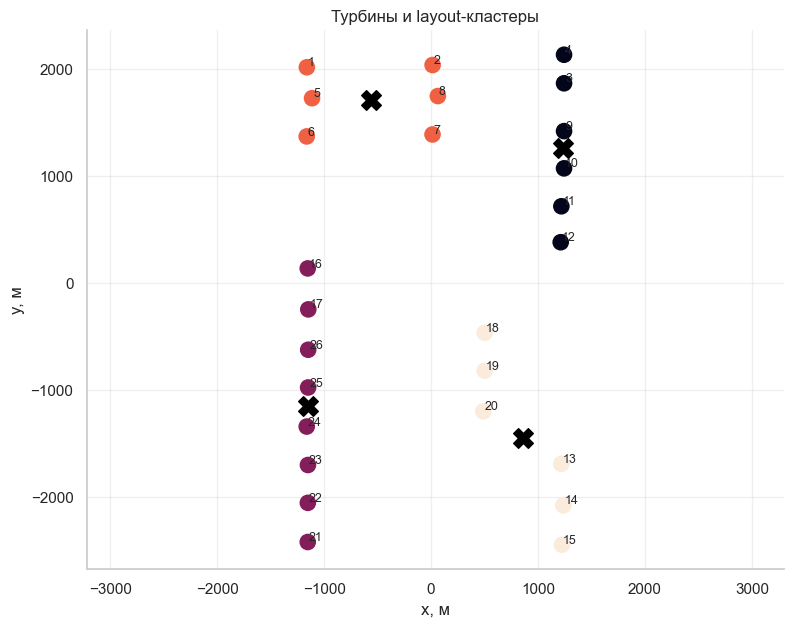

In [167]:
print("=" * 90)
print("ГЕОМЕТРИЯ ВЭС")
print("=" * 90)

if not TURBINE_COORDS_PATH.exists():
    raise FileNotFoundError(
        f"Не найден {TURBINE_COORDS_PATH}. Положи координаты турбин в map/data/wind_farm_coords.csv."
    )

turbines = pd.read_csv(TURBINE_COORDS_PATH)

if "turbine_id" not in turbines.columns:
    turbines["turbine_id"] = np.arange(1, len(turbines) + 1)

if not {"lat", "lon"}.issubset(turbines.columns):
    raise ValueError("В файле турбин должны быть колонки lat и lon.")

lat0 = turbines["lat"].mean()
lon0 = turbines["lon"].mean()

meters_per_deg_lat = 111_320
meters_per_deg_lon = 111_320 * np.cos(np.deg2rad(lat0))

turbines["x_m"] = (turbines["lon"] - lon0) * meters_per_deg_lon
turbines["y_m"] = (turbines["lat"] - lat0) * meters_per_deg_lat

XY = turbines[["x_m", "y_m"]].to_numpy()

D = squareform(pdist(XY))
D_near = D + np.eye(len(D)) * 10**9
nearest_dist = D_near.min(axis=1)

print("Турбин:", len(turbines))
print(f"Среднее ближайшее расстояние: {nearest_dist.mean():.1f} м")
print(f"Медианное ближайшее расстояние: {np.median(nearest_dist):.1f} м")

kmeans_layout = KMeans(
    n_clusters=N_LAYOUT_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=LAYOUT_KMEANS_N_INIT,
)

turbines["layout_cluster"] = kmeans_layout.fit_predict(XY)

cluster_centers = pd.DataFrame(
    kmeans_layout.cluster_centers_,
    columns=["x_m", "y_m"],
)
cluster_centers["cluster_id"] = np.arange(len(cluster_centers))

pca_layout = PCA(n_components=2)
pca_layout.fit(XY)

main_axis = pca_layout.components_[0]
axis_angle_xy_deg = (np.rad2deg(np.arctan2(main_axis[1], main_axis[0])) + 360) % 360
farm_axis_compass_deg = (90 - axis_angle_xy_deg) % 360

print(f"Главная ось ВЭС: {farm_axis_compass_deg:.2f}° / {(farm_axis_compass_deg + 180) % 360:.2f}°")
print("Доля объяснённой дисперсии PCA:", pca_layout.explained_variance_ratio_)

cluster_axis_rows = []

for cl in sorted(turbines["layout_cluster"].unique()):
    part = turbines[turbines["layout_cluster"].eq(cl)].copy()
    XYc = part[["x_m", "y_m"]].to_numpy()

    if len(part) >= 2:
        pcac = PCA(n_components=2)
        pcac.fit(XYc)
        axis = pcac.components_[0]
        axis_xy = (np.rad2deg(np.arctan2(axis[1], axis[0])) + 360) % 360
        axis_compass = (90 - axis_xy) % 360
        evr = pcac.explained_variance_ratio_[0]
    else:
        axis_compass = np.nan
        evr = np.nan

    cluster_axis_rows.append({
        "cluster_id": cl,
        "cluster_axis_compass_deg": axis_compass,
        "cluster_axis_evr": evr,
        "n": len(part),
    })

cluster_axis_df = pd.DataFrame(cluster_axis_rows)
display(cluster_axis_df)

plt.figure(figsize=(9, 7))
plt.scatter(turbines["x_m"], turbines["y_m"], c=turbines["layout_cluster"], s=120)
plt.scatter(cluster_centers["x_m"], cluster_centers["y_m"], c="black", marker="X", s=200)

for _, row in turbines.iterrows():
    plt.text(row["x_m"] + 10, row["y_m"] + 10, str(int(row["turbine_id"])), fontsize=9)

plt.axis("equal")
plt.grid(alpha=0.3)
plt.title("Турбины и layout-кластеры")
plt.xlabel("x, м")
plt.ylabel("y, м")
plt.show()

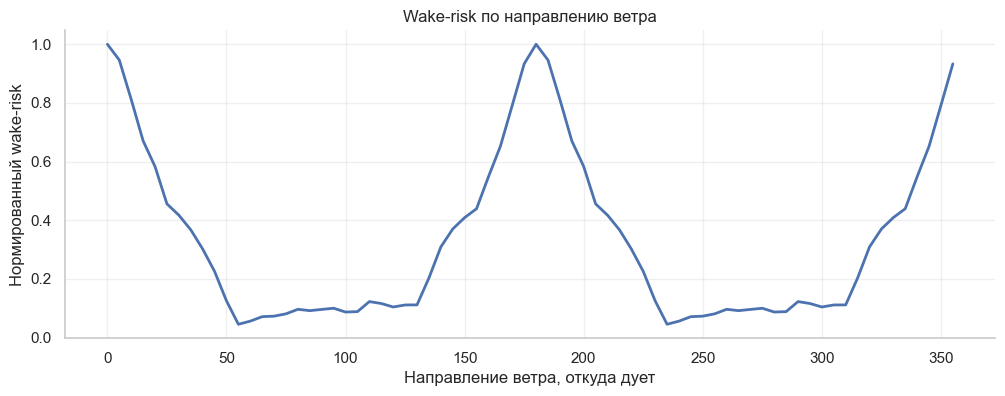

,wind_from_deg,wake_pair_count,wake_risk_score,wake_risk_score_norm
0,0,66,23.082026,1.000000
1,5,66,21.839060,0.946150
2,10,50,18.740340,0.811902
3,15,41,15.480369,0.670668
4,20,41,13.457375,0.583024


In [168]:
def compute_wake_risk_for_direction(
    xy,
    wind_from_deg,
    lateral_threshold_m=WAKE_LATERAL_THRESHOLD_M,
    max_downwind_m=WAKE_MAX_DOWNWIND_M,
    decay_downwind_m=WAKE_DECAY_DOWNWIND_M,
):
    flow_to_deg = (wind_from_deg + 180) % 360
    theta = np.deg2rad(flow_to_deg)

    flow_vec = np.array([np.sin(theta), np.cos(theta)])
    side_vec = np.array([np.cos(theta), -np.sin(theta)])

    pair_count = 0
    weighted_risk = 0.0

    n = len(xy)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            delta = xy[j] - xy[i]
            downwind = np.dot(delta, flow_vec)
            lateral = abs(np.dot(delta, side_vec))

            if downwind > 0 and downwind <= max_downwind_m and lateral <= lateral_threshold_m:
                pair_count += 1
                weighted_risk += (
                    np.exp(-downwind / decay_downwind_m)
                    * np.exp(-((lateral / lateral_threshold_m) ** 2))
                )

    return pair_count, weighted_risk


directions = np.arange(0, 360, WAKE_DIRECTION_STEP_DEG)

wake_rows = []

for direction_deg in directions:
    pair_count, risk_score = compute_wake_risk_for_direction(XY, direction_deg)
    wake_rows.append({
        "wind_from_deg": direction_deg,
        "wake_pair_count": pair_count,
        "wake_risk_score": risk_score,
    })

wake_table = pd.DataFrame(wake_rows)

if wake_table["wake_risk_score"].max() > 0:
    wake_table["wake_risk_score_norm"] = (
        wake_table["wake_risk_score"] / wake_table["wake_risk_score"].max()
    )
else:
    wake_table["wake_risk_score_norm"] = 0.0

plt.figure(figsize=(12, 4))
plt.plot(wake_table["wind_from_deg"], wake_table["wake_risk_score_norm"], linewidth=2)
plt.title("Wake-risk по направлению ветра")
plt.xlabel("Направление ветра, откуда дует")
plt.ylabel("Нормированный wake-risk")
plt.grid(alpha=0.3)
plt.show()

display(wake_table.head())

## 9. Modeling frames with spatial and wake features

Собираем train/valid таблицы для моделей: к базовому feature set добавляются `cluster_axis` и `layout_wake_risk_scalar_120m`, а затем при необходимости физическая декомпозиция скрытых потерь.

In [169]:

# Основной wake-признак задан в глобальных настройках
print("BEST_WAKE_FEATURE:", BEST_WAKE_FEATURE)


BEST_WAKE_FEATURE: layout_wake_risk_scalar_120m


In [170]:
def circular_diff_deg(a, b):
    return ((a - b + 180) % 360) - 180


def get_wind_from_deg(frame, direction_col="wind_direction_120m"):
    if direction_col not in frame.columns:
        raise ValueError(f"Нет колонки {direction_col}")
    return (pd.to_numeric(frame[direction_col], errors="coerce") * 1000) % 360


def add_cluster_axis_features(frame):
    out = frame.copy()
    added = []

    wind_from_deg = get_wind_from_deg(out, "wind_direction_120m")
    align_cols = []

    for _, row in cluster_axis_df.iterrows():
        cl = int(row["cluster_id"])
        axis = row["cluster_axis_compass_deg"]

        if np.isnan(axis):
            continue

        diff = circular_diff_deg(wind_from_deg, axis)

        col_align = f"cluster{cl}_axis_alignment"
        col_cross = f"cluster{cl}_axis_crosswind"

        out[col_align] = np.cos(2 * np.deg2rad(diff))
        out[col_cross] = np.sin(2 * np.deg2rad(diff))

        align_cols.append(col_align)
        added += [col_align, col_cross]

    if len(align_cols) > 0:
        out["cluster_axis_alignment_mean"] = out[align_cols].mean(axis=1)
        out["cluster_axis_alignment_max"] = out[align_cols].max(axis=1)
        out["cluster_axis_alignment_min"] = out[align_cols].min(axis=1)

        added += [
            "cluster_axis_alignment_mean",
            "cluster_axis_alignment_max",
            "cluster_axis_alignment_min",
        ]

    return out, added


def add_wake_scalar_feature(frame, feature_name=BEST_WAKE_FEATURE):
    out = frame.copy()
    direction_deg = get_wind_from_deg(out, "wind_direction_120m").to_numpy(dtype=float)

    wt = wake_table[["wind_from_deg", "wake_risk_score_norm"]].dropna().copy()
    wt = wt.sort_values("wind_from_deg")

    xp = wt["wind_from_deg"].to_numpy(dtype=float)
    fp = wt["wake_risk_score_norm"].to_numpy(dtype=float)

    if len(xp) == 0 or not np.isfinite(fp).any():
        out[feature_name] = 0.0
        return out, [feature_name]

    median_risk = float(np.nanmedian(fp))

    xp_wrap = np.r_[xp, xp[0] + 360.0]
    fp_wrap = np.r_[fp, fp[0]]

    direction_for_interp = np.where(np.isfinite(direction_deg), direction_deg, 0.0)

    risk = np.interp(direction_for_interp, xp_wrap, fp_wrap)
    risk[~np.isfinite(direction_deg)] = median_risk
    risk = np.nan_to_num(risk, nan=median_risk, posinf=median_risk, neginf=median_risk)
    risk = np.clip(risk, 0.0, 1.0)

    out[feature_name] = risk

    return out, [feature_name]


def build_model_frames():
    train_out = train_fe.copy()
    valid_out = valid_fe.copy()

    added_cols = []

    train_out, cluster_cols = add_cluster_axis_features(train_out)
    valid_out, _ = add_cluster_axis_features(valid_out)
    added_cols += cluster_cols

    train_out, wake_cols = add_wake_scalar_feature(train_out)
    valid_out, _ = add_wake_scalar_feature(valid_out)
    added_cols += wake_cols

    added_cols = list(dict.fromkeys([
        c for c in added_cols
        if c in train_out.columns and c in valid_out.columns
    ]))

    model_features = list(dict.fromkeys([
        c for c in model_features_base + added_cols
        if c in train_out.columns and c in valid_out.columns
    ]))

    return train_out, valid_out, added_cols, model_features



train_model_preview, valid_model_preview, layout_added_features, model_features_preview = build_model_frames()

display(Markdown(
    "### Spatial/wake признаки\n\n"
    "По координатам турбин рассчитаны ориентация кластеров и scalar wake-risk для направления ветра."
))
display(pd.DataFrame([
    {"dataset": "train_model_preview", "rows": train_model_preview.shape[0]},
    {"dataset": "valid_model_preview", "rows": valid_model_preview.shape[0]},
    {"dataset": "wake_signal_available", "rows": bool(BEST_WAKE_FEATURE in model_features_preview)},
]))

### Spatial/wake признаки

По координатам турбин рассчитаны ориентация кластеров и scalar wake-risk для направления ветра.

,dataset,rows
0,train_model_preview,32434
1,valid_model_preview,2126
2,wake_signal_available,True


## 10. Physical decomposition of hidden losses

Блок оценивает скрытые потери относительно идеальной мощности: строит `full_p_ideal_clean`, оценивает доступность по ремонтам, выделяет meteo/aging компоненты и добавляет реконструированную мощность как набор физических признаков. OOF-часть используется для train-признаков, чтобы снизить риск leakage.

In [171]:
# ============================================================
# PHYSICAL DECOMPOSITION BLOCK
# P_ideal_clean -> K_hidden -> K_avail + K_perf
# ============================================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, mean_squared_error

# Параметры блока задаются в секции глобальных настроек.
print("FULL_PHYSICS_BLOCK_ENABLED:", FULL_PHYSICS_BLOCK_ENABLED)
print("FULL_OOF_SPLITS:", FULL_OOF_SPLITS)
print("FULL_CHANGEPOINT_WINDOW:", FULL_CHANGEPOINT_WINDOW)
print("FULL_AVAIL_LAMBDA:", FULL_AVAIL_LAMBDA)


FULL_PHYSICS_BLOCK_ENABLED: True
FULL_OOF_SPLITS: 5
FULL_CHANGEPOINT_WINDOW: 72
FULL_AVAIL_LAMBDA: 0.0015


In [172]:
def _full_first_existing(frame, candidates):
    for col in candidates:
        if col in frame.columns:
            return col
    return None


In [173]:
def _full_num(frame, col, default=0.0):
    if col in frame.columns:
        return pd.to_numeric(frame[col], errors="coerce")
    return pd.Series(default, index=frame.index, dtype=float)


In [174]:
def _full_wind_from_deg(frame, direction_col="wind_direction_120m"):
    if direction_col in frame.columns:
        return (pd.to_numeric(frame[direction_col], errors="coerce") * 1000) % 360
    alt_col = _full_first_existing(frame, ["wind_direction_80m", "WD50M", "WD10M", "wind_direction_10m"])
    if alt_col is None:
        return pd.Series(0.0, index=frame.index, dtype=float)
    if alt_col.startswith("wind_direction_"):
        return (pd.to_numeric(frame[alt_col], errors="coerce") * 1000) % 360
    return pd.to_numeric(frame[alt_col], errors="coerce") % 360


In [175]:
def _full_compute_p_ideal_clean(frame):
    out = frame.copy()
    p_col = _full_first_existing(
        out,
        [
            "theoretical_total",
            "P_curve_total",
            "p_curve_total",
            "p_theory_mean_80_120",
            "p_theory_120",
            "p_theory_80",
            "p_empirical_mean_80_120",
        ],
    )
    if p_col is None:
        base = pd.Series(INSTALLED_CAPACITY_MW, index=out.index, dtype=float)
        p_source = "installed_capacity_fallback"
    else:
        base = pd.to_numeric(out[p_col], errors="coerce")
        p_source = p_col

    wake_col = _full_first_existing(out, ["wake_efficiency_factor", "wake_factor", "eta_wake"])
    if wake_col is not None:
        wake_factor = pd.to_numeric(out[wake_col], errors="coerce").clip(0.50, 1.10)
        wake_source = wake_col
    else:
        wake_factor = pd.Series(1.0, index=out.index, dtype=float)
        wake_source = "no_explicit_wake_factor"

    out["full_p_ideal_clean"] = (base * wake_factor).replace([np.inf, -np.inf], np.nan)
    out["full_p_ideal_clean"] = out["full_p_ideal_clean"].clip(0, INSTALLED_CAPACITY_MW * 1.20)
    out.attrs["full_p_ideal_source"] = p_source
    out.attrs["full_wake_source"] = wake_source
    return out


In [176]:
def _full_observed_k_hidden(frame):
    ideal = pd.to_numeric(frame["full_p_ideal_clean"], errors="coerce")
    target = pd.to_numeric(frame["target"], errors="coerce")
    k = pd.Series(np.nan, index=frame.index, dtype=float)
    mask = ideal > FULL_MIN_IDEAL_MW
    k.loc[mask] = 1.0 - target.loc[mask] / (ideal.loc[mask] + EPS)
    return k.clip(FULL_K_HIDDEN_LOW, FULL_K_HIDDEN_HIGH)


In [177]:
def _full_spatial_weight_matrix(frame):
    if "XY" not in globals():
        raise NameError("Не найден XY с координатами турбин. Сначала должна выполниться геометрия ВЭС.")

    xy = np.asarray(XY, dtype=float)
    n_rows = len(frame)
    n_turbines = xy.shape[0]

    wind_from = _full_wind_from_deg(frame).fillna(0).to_numpy(dtype=float)
    weights = np.zeros((n_rows, n_turbines), dtype=float)

    for r, wind_from_deg in enumerate(wind_from):
        flow_to_deg = (wind_from_deg + 180.0) % 360.0
        theta = np.deg2rad(flow_to_deg)
        flow_vec = np.array([np.sin(theta), np.cos(theta)], dtype=float)
        proj = xy @ flow_vec
        proj_range = float(np.nanmax(proj) - np.nanmin(proj))
        if proj_range <= EPS:
            base = np.ones(n_turbines, dtype=float)
        else:
            upwind_score = (np.nanmax(proj) - proj) / (proj_range + EPS)
            base = 1.0 + FULL_UPWIND_WEIGHT_BOOST * upwind_score

        if BEST_WAKE_FEATURE in frame.columns:
            wake_risk = float(pd.to_numeric(frame.iloc[[r]][BEST_WAKE_FEATURE], errors="coerce").iloc[0])
            base = base * (1.0 + 0.20 * np.nan_to_num(wake_risk, nan=0.0))

        base = np.nan_to_num(base, nan=1.0, posinf=1.0, neginf=1.0)
        s = base.sum()
        if s <= EPS:
            weights[r, :] = 1.0 / n_turbines
        else:
            weights[r, :] = base / s

    return weights


In [178]:
def _full_k_avail_from_repair_count(frame, weights):
    repair_count = _full_num(frame, "turbines_in_repair", 0.0).round().clip(0, weights.shape[1]).fillna(0).astype(int).to_numpy()
    out = np.zeros(len(frame), dtype=float)
    for i, m in enumerate(repair_count):
        if m <= 0:
            out[i] = 0.0
        elif m >= weights.shape[1]:
            out[i] = float(weights[i].sum())
        else:
            top_idx = np.argpartition(weights[i], -m)[-m:]
            out[i] = float(weights[i, top_idx].sum())
    return np.clip(out, 0, 1)


In [179]:
def _full_detect_change_points(k_series, window=FULL_CHANGEPOINT_WINDOW, min_distance=FULL_CHANGEPOINT_MIN_DISTANCE):
    k = pd.Series(k_series).astype(float).replace([np.inf, -np.inf], np.nan)
    k_filled = k.interpolate(limit_direction="both").fillna(k.median() if k.notna().any() else 0.0)

    left = k_filled.rolling(window=window, min_periods=max(8, window // 4)).median()
    right = k_filled[::-1].rolling(window=window, min_periods=max(8, window // 4)).median()[::-1]
    score = (right - left).abs().fillna(0.0)

    med = float(score.median())
    mad = float((score - med).abs().median())
    threshold = med + FULL_CHANGEPOINT_THRESHOLD_MAD * 1.4826 * (mad + EPS)

    candidates = np.where(score.to_numpy() > threshold)[0]
    selected = []
    for idx in candidates[np.argsort(score.to_numpy()[candidates])[::-1]]:
        if idx < window or idx > len(k_filled) - window:
            continue
        if all(abs(idx - j) >= min_distance for j in selected):
            selected.append(int(idx))

    selected = sorted(selected)
    boundaries = [0] + selected + [len(k_filled)]

    merged = [boundaries[0]]
    for b in boundaries[1:]:
        if b - merged[-1] < min_distance and b != len(k_filled):
            continue
        merged.append(b)
    if merged[-1] != len(k_filled):
        merged.append(len(k_filled))

    segment_id = np.zeros(len(k_filled), dtype=int)
    for seg, (a, b) in enumerate(zip(merged[:-1], merged[1:])):
        segment_id[a:b] = seg

    score_df = pd.DataFrame({
        "index": np.arange(len(k_filled)),
        "k_hidden_filled": k_filled.to_numpy(),
        "cp_score": score.to_numpy(),
        "segment_id": segment_id,
        "is_boundary": np.isin(np.arange(len(k_filled)), merged[1:-1]).astype(int),
    })
    return segment_id, merged, score_df


In [180]:
def _full_inverse_availability_by_plateau(train_frame, weights, k_hidden):
    segment_id, boundaries, cp_score_df = _full_detect_change_points(k_hidden)

    k_avail_est = np.zeros(len(train_frame), dtype=float)
    off_count_est = np.zeros(len(train_frame), dtype=int)
    plateau_rows = []

    for seg in np.unique(segment_id):
        idx = np.where(segment_id == seg)[0]
        if len(idx) == 0:
            continue

        k_target = float(np.nanmedian(pd.Series(k_hidden).iloc[idx]))
        if not np.isfinite(k_target):
            k_target = 0.0
        k_target = float(np.clip(k_target, 0.0, FULL_K_HIDDEN_HIGH))

        w_bar = np.nanmean(weights[idx], axis=0)
        w_bar = np.nan_to_num(w_bar, nan=1.0 / weights.shape[1])
        order = np.argsort(w_bar)[::-1]

        best_obj = np.inf
        best_m = 0
        best_loss = 0.0
        max_m = min(FULL_MAX_OFF_GRID, weights.shape[1])

        cumulative_loss = np.r_[0.0, np.cumsum(w_bar[order[:max_m]])]
        for m in range(max_m + 1):
            loss = float(cumulative_loss[m])
            obj = (k_target - loss) ** 2 + FULL_AVAIL_LAMBDA * m
            if obj < best_obj:
                best_obj = obj
                best_m = m
                best_loss = loss

        selected_turbines = order[:best_m]
        if best_m > 0:
            k_avail_est[idx] = weights[np.ix_(idx, selected_turbines)].sum(axis=1)
        off_count_est[idx] = best_m

        actual_count_median = float(_full_num(train_frame.iloc[idx], "turbines_in_repair", 0.0).median())
        plateau_rows.append({
            "segment_id": int(seg),
            "start_pos": int(idx.min()),
            "end_pos": int(idx.max()),
            "count": int(len(idx)),
            "k_hidden_median": k_target,
            "estimated_off_count": int(best_m),
            "estimated_loss_mean_weight": best_loss,
            "objective": float(best_obj),
            "actual_repair_count_median": actual_count_median,
            "selected_turbines_1based": ";".join(str(int(t + 1)) for t in selected_turbines),
        })

    plateau_table = pd.DataFrame(plateau_rows)
    return np.clip(k_avail_est, 0, 1), off_count_est, segment_id, plateau_table, cp_score_df


In [181]:
def _full_add_phi_features(frame):
    out = frame.copy()
    phi_cols = []

    temp_col = _full_first_existing(out, ["temperature_80m", "T2M", "temperature_120m"])
    dew_col = _full_first_existing(out, ["T2MDEW"])
    q_col = _full_first_existing(out, ["QV2M"])
    wet_col = _full_first_existing(out, ["T2MWET"])

    if temp_col is not None:
        temp = _full_num(out, temp_col)
        snow = _full_num(out, "snowfall", 0.0)
        rain = _full_num(out, "rain", 0.0) + _full_num(out, "showers", 0.0)
        cloud = _full_num(out, "cloud_cover_low", 0.0)

        humidity = pd.Series(0.0, index=out.index, dtype=float)
        if q_col is not None:
            q = _full_num(out, q_col)
            q95 = np.nanpercentile(q, 95) if np.isfinite(q).any() else 1.0
            humidity = np.clip(q / (q95 + EPS), 0, 1.5)
        elif dew_col is not None:
            dew = _full_num(out, dew_col)
            humidity = np.clip(1 - ((temp - dew).abs() / 10.0), 0, 1.2)
        elif wet_col is not None:
            wet = _full_num(out, wet_col)
            humidity = np.clip(1 - ((temp - wet).abs() / 8.0), 0, 1.2)
        else:
            humidity = np.clip(cloud, 0, 1.2)

        out["phi_ice_risk"] = (((temp <= 2.0).astype(float)) * (0.55 * humidity + 0.30 * (snow > 0).astype(float) + 0.15 * (rain > 0).astype(float))).clip(0, 2)
        out["phi_cold"] = (temp <= 2.0).astype(int)
        out["phi_temp"] = temp
        phi_cols += ["phi_ice_risk", "phi_cold", "phi_temp"]

    if {"wind_gusts_10m", "wind_speed_10m"}.issubset(out.columns):
        out["phi_turbulence"] = ((_full_num(out, "wind_gusts_10m") - _full_num(out, "wind_speed_10m")) / (_full_num(out, "wind_speed_10m") + EPS)).clip(0, 5)
        phi_cols.append("phi_turbulence")
    elif {"WSC", "WS10M"}.issubset(out.columns):
        out["phi_turbulence"] = ((_full_num(out, "WSC") - _full_num(out, "WS10M")) / (_full_num(out, "WS10M") + EPS)).clip(0, 5)
        phi_cols.append("phi_turbulence")

    direction = _full_wind_from_deg(out)
    sorted_pos = np.argsort(pd.to_datetime(out["datetime"], errors="coerce").to_numpy()) if "datetime" in out.columns else np.arange(len(out))
    yaw_abs = pd.Series(0.0, index=out.index, dtype=float)
    if len(out) > 1:
        dir_sorted = direction.iloc[sorted_pos].to_numpy(dtype=float)
        diff_sorted = np.r_[0.0, np.abs(((np.diff(dir_sorted) + 180) % 360) - 180)]
        yaw_abs.iloc[sorted_pos] = diff_sorted
    out["phi_yaw_change_abs_1h"] = yaw_abs.clip(0, 180)
    phi_cols.append("phi_yaw_change_abs_1h")

    for c in [
        "wind_speed_80m", "wind_speed_120m", "wind_speed_180m", "wind_gusts_10m",
        "WS10M", "WS50M", "WSC", "pressure_msl", "PS",
        "p_theory_mean_80_120", "p_empirical_mean_80_120", BEST_WAKE_FEATURE,
        "cluster_axis_alignment_mean", "cluster_axis_alignment_max", "cluster_axis_alignment_min",
    ]:
        if c in out.columns:
            phi_cols.append(c)

    if {"wind_speed_120m", BEST_WAKE_FEATURE}.issubset(out.columns):
        out["phi_wake_x_ws120"] = out[BEST_WAKE_FEATURE] * out["wind_speed_120m"]
        phi_cols.append("phi_wake_x_ws120")

    if {"phi_ice_risk", "wind_speed_120m"}.issubset(out.columns):
        out["phi_ice_x_ws120"] = out["phi_ice_risk"] * out["wind_speed_120m"]
        phi_cols.append("phi_ice_x_ws120")

    phi_cols = list(dict.fromkeys([c for c in phi_cols if c in out.columns]))
    for c in phi_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
    return out, phi_cols


In [182]:
def _full_time_oof_regression(train_frame, valid_frame, feature_cols, target, label):
    X = train_frame[feature_cols].replace([np.inf, -np.inf], np.nan).copy()
    X_valid = valid_frame[feature_cols].replace([np.inf, -np.inf], np.nan).copy()
    y = pd.Series(target, index=train_frame.index, dtype=float).replace([np.inf, -np.inf], np.nan)

    good = y.notna()
    fallback = float(y[good].median()) if good.any() else 0.0
    oof = np.full(len(train_frame), fallback, dtype=float)

    if good.sum() >= 200 and len(feature_cols) > 0:
        n_splits = min(FULL_OOF_SPLITS, max(2, good.sum() // 300))
        splitter = TimeSeriesSplit(n_splits=n_splits, gap=24)
        positions = np.arange(len(train_frame))

        for fold, (tr_pos, te_pos) in enumerate(splitter.split(positions), start=1):
            tr_good = good.iloc[tr_pos].to_numpy()
            if tr_good.sum() < 100:
                continue
            tr_idx = tr_pos[tr_good]
            model = HistGradientBoostingRegressor(
                loss="absolute_error",
                max_iter=260,
                learning_rate=0.045,
                max_leaf_nodes=31,
                l2_regularization=0.05,
                random_state=FULL_RANDOM_STATE + fold,
            )
            model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
            oof[te_pos] = model.predict(X.iloc[te_pos])

        final_model = HistGradientBoostingRegressor(
            loss="absolute_error",
            max_iter=360,
            learning_rate=0.04,
            max_leaf_nodes=31,
            l2_regularization=0.05,
            random_state=FULL_RANDOM_STATE + 777,
        )
        final_model.fit(X.loc[good], y.loc[good])
        valid_pred = final_model.predict(X_valid)
    else:
        final_model = None
        valid_pred = np.full(len(valid_frame), fallback, dtype=float)

    return oof, valid_pred, final_model


In [183]:
def _full_rolling_aging_component(train_frame, k_perf_raw):
    tmp = pd.DataFrame({
        "datetime": pd.to_datetime(train_frame["datetime"], errors="coerce"),
        "k_perf_raw": pd.Series(k_perf_raw, index=train_frame.index, dtype=float).clip(-0.50, 0.90),
    }).sort_values("datetime")

    if tmp["k_perf_raw"].notna().sum() == 0:
        return pd.Series(0.0, index=train_frame.index, dtype=float)

    rolled = (
        tmp.set_index("datetime")["k_perf_raw"]
        .rolling("30D", min_periods=48)
        .median()
    )
    rolled = rolled.bfill().ffill().fillna(float(tmp["k_perf_raw"].median()))
    result = pd.Series(index=tmp.index, data=rolled.to_numpy(), dtype=float).reindex(train_frame.index)
    return result.astype(float).clip(-0.30, 0.80)


In [184]:
def add_full_physical_decomposition_features(train_frame, valid_frame):
    train_out = _full_compute_p_ideal_clean(train_frame)
    valid_out = _full_compute_p_ideal_clean(valid_frame)

    train_out, phi_cols_train = _full_add_phi_features(train_out)
    valid_out, phi_cols_valid = _full_add_phi_features(valid_out)
    phi_cols = [c for c in phi_cols_train if c in phi_cols_valid]

    W_train = _full_spatial_weight_matrix(train_out)
    W_valid = _full_spatial_weight_matrix(valid_out)

    train_out["full_k_hidden_observed_train_only"] = _full_observed_k_hidden(train_out)
    k_hidden = train_out["full_k_hidden_observed_train_only"]

    k_avail_est, off_count_est, segment_id, plateau_table, cp_score_df = _full_inverse_availability_by_plateau(train_out, W_train, k_hidden)
    train_out["full_k_avail_est_by_hidden_train_only"] = k_avail_est
    train_out["full_est_turbines_off_by_hidden_train_only"] = off_count_est
    train_out["full_hidden_plateau_id_train_only"] = segment_id

    train_out["full_k_avail_knowncount"] = _full_k_avail_from_repair_count(train_out, W_train)
    valid_out["full_k_avail_knowncount"] = _full_k_avail_from_repair_count(valid_out, W_valid)

    k_perf_raw = (train_out["full_k_hidden_observed_train_only"] - train_out["full_k_avail_est_by_hidden_train_only"]).clip(-0.50, 0.90)
    train_out["full_k_perf_raw_train_only"] = k_perf_raw
    train_out["full_k_aging_target_train_only"] = _full_rolling_aging_component(train_out, k_perf_raw)
    train_out["full_k_meteo_target_train_only"] = (train_out["full_k_perf_raw_train_only"] - train_out["full_k_aging_target_train_only"]).clip(-0.50, 0.70)

    if len(phi_cols) == 0:
        train_out["full_k_meteo_pred"] = 0.0
        valid_out["full_k_meteo_pred"] = 0.0
        train_out["full_k_aging_pred"] = float(train_out["full_k_aging_target_train_only"].median()) if train_out["full_k_aging_target_train_only"].notna().any() else 0.0
        valid_out["full_k_aging_pred"] = float(train_out["full_k_aging_pred"].median())
        meteo_model = None
        aging_model = None
    else:
        meteo_oof, meteo_valid, meteo_model = _full_time_oof_regression(
            train_out,
            valid_out,
            phi_cols,
            train_out["full_k_meteo_target_train_only"],
            label="k_meteo",
        )
        aging_oof, aging_valid, aging_model = _full_time_oof_regression(
            train_out,
            valid_out,
            phi_cols + [c for c in ["month", "dayofyear", "hour_of_day"] if c in train_out.columns and c in valid_out.columns],
            train_out["full_k_aging_target_train_only"],
            label="k_aging",
        )
        train_out["full_k_meteo_pred"] = np.clip(meteo_oof, -0.50, 0.70)
        valid_out["full_k_meteo_pred"] = np.clip(meteo_valid, -0.50, 0.70)
        train_out["full_k_aging_pred"] = np.clip(aging_oof, -0.30, 0.80)
        valid_out["full_k_aging_pred"] = np.clip(aging_valid, -0.30, 0.80)

    for frame in [train_out, valid_out]:
        frame["full_k_perf_pred"] = (frame["full_k_aging_pred"] + frame["full_k_meteo_pred"]).clip(-0.50, 0.90)
        frame["full_k_hidden_pred"] = (frame["full_k_avail_knowncount"] + frame["full_k_perf_pred"]).clip(FULL_K_HIDDEN_LOW, FULL_K_HIDDEN_HIGH)
        frame["full_hidden_loss_mw_pred"] = (frame["full_p_ideal_clean"] * frame["full_k_hidden_pred"]).clip(-20, INSTALLED_CAPACITY_MW)
        frame["full_p_reconstructed"] = (frame["full_p_ideal_clean"] * (1 - frame["full_k_hidden_pred"])).clip(0, INSTALLED_CAPACITY_MW)
        if "p_empirical_mean_80_120" in frame.columns:
            frame["full_recon_minus_empirical_curve"] = frame["full_p_reconstructed"] - frame["p_empirical_mean_80_120"]
        if BEST_WAKE_FEATURE in frame.columns:
            frame["full_k_hidden_x_wake"] = frame["full_k_hidden_pred"] * frame[BEST_WAKE_FEATURE]
        if "phi_ice_risk" in frame.columns:
            frame["full_k_meteo_x_ice"] = frame["full_k_meteo_pred"] * frame["phi_ice_risk"]

    actual_event = (_full_num(train_out, "turbines_in_repair", 0.0).round() > 0).astype(int)
    pred_event = (train_out["full_est_turbines_off_by_hidden_train_only"] > 0).astype(int)
    detector_report = pd.DataFrame([
        {
            "metric": "availability_event_f1",
            "value": f1_score(actual_event, pred_event, zero_division=0),
        },
        {
            "metric": "availability_event_accuracy",
            "value": accuracy_score(actual_event, pred_event),
        },
        {
            "metric": "estimated_off_mae_vs_repair_count",
            "value": np.mean(np.abs(train_out["full_est_turbines_off_by_hidden_train_only"] - _full_num(train_out, "turbines_in_repair", 0.0).round())),
        },
    ])

    cm = confusion_matrix(actual_event, pred_event, labels=[0, 1])
    detector_cm = pd.DataFrame(cm, index=["actual_no_repair", "actual_repair"], columns=["pred_no_repair", "pred_repair"])

    oot_mask = np.arange(len(train_out)) >= int(len(train_out) * 0.8)
    oot_df = train_out.loc[oot_mask].copy()
    oot_df["full_recon_abs_error"] = (oot_df["full_p_reconstructed"] - oot_df["target"]).abs()
    oot_df["ideal_abs_error"] = (oot_df["full_p_ideal_clean"].clip(0, INSTALLED_CAPACITY_MW) - oot_df["target"]).abs()
    if "p_empirical_mean_80_120" in oot_df.columns:
        oot_df["empirical_curve_abs_error"] = (oot_df["p_empirical_mean_80_120"].clip(0, INSTALLED_CAPACITY_MW) - oot_df["target"]).abs()
    else:
        oot_df["empirical_curve_abs_error"] = np.nan

    oot_report = pd.DataFrame([
        {
            "metric": "oot_mae_full_physical_reconstruction",
            "value": float(oot_df["full_recon_abs_error"].mean()),
        },
        {
            "metric": "oot_mae_p_ideal_clean",
            "value": float(oot_df["ideal_abs_error"].mean()),
        },
        {
            "metric": "oot_mae_empirical_curve",
            "value": float(oot_df["empirical_curve_abs_error"].mean()),
        },
        {
            "metric": "oot_delta_full_vs_ideal",
            "value": float(oot_df["full_recon_abs_error"].mean() - oot_df["ideal_abs_error"].mean()),
        },
    ])

    added = [
        "full_p_ideal_clean",
        "full_k_avail_knowncount",
        "full_k_aging_pred",
        "full_k_meteo_pred",
        "full_k_perf_pred",
        "full_k_hidden_pred",
        "full_hidden_loss_mw_pred",
        "full_p_reconstructed",
        "full_recon_minus_empirical_curve",
        "full_k_hidden_x_wake",
        "full_k_meteo_x_ice",
    ] + phi_cols
    added = list(dict.fromkeys([c for c in added if c in train_out.columns and c in valid_out.columns]))

    diagnostics = {
        "plateau_table": plateau_table,
        "cp_score_df": cp_score_df,
        "detector_report": detector_report,
        "detector_confusion_matrix": detector_cm,
        "oot_report": oot_report,
        "oot_rows": oot_df[[c for c in ["datetime", "target", "full_p_ideal_clean", "full_p_reconstructed", "full_recon_abs_error", "ideal_abs_error", "empirical_curve_abs_error"] if c in oot_df.columns]].copy(),
        "phi_cols": pd.DataFrame({"phi_feature": phi_cols}),
    }

    return train_out, valid_out, added, diagnostics


_base_build_model_frames = build_model_frames


In [185]:
def build_model_frames():
    train_out = train_fe.copy()
    valid_out = valid_fe.copy()

    added_cols = []

    train_out, cluster_cols = add_cluster_axis_features(train_out)
    valid_out, _ = add_cluster_axis_features(valid_out)
    added_cols += cluster_cols

    train_out, wake_cols = add_wake_scalar_feature(train_out)
    valid_out, _ = add_wake_scalar_feature(valid_out)
    added_cols += wake_cols

    if FULL_PHYSICS_BLOCK_ENABLED:
        train_out, valid_out, full_cols, full_diag = add_full_physical_decomposition_features(train_out, valid_out)
        added_cols += full_cols

        if SAVE_DIAGNOSTIC_ARTIFACTS:
            LOG_DIR.mkdir(parents=True, exist_ok=True)
            full_diag["plateau_table"].to_csv(LOG_DIR / "full_hidden_plateaus.csv", index=False)
            full_diag["cp_score_df"].to_csv(LOG_DIR / "full_changepoint_scores.csv", index=False)
            full_diag["detector_report"].to_csv(LOG_DIR / "full_availability_detector_report.csv", index=False)
            full_diag["detector_confusion_matrix"].to_csv(LOG_DIR / "full_availability_confusion_matrix.csv")
            full_diag["oot_report"].to_csv(LOG_DIR / "full_physics_oot_report.csv", index=False)
            full_diag["oot_rows"].to_csv(LOG_DIR / "full_physics_oot_rows.csv", index=False)
            full_diag["phi_cols"].to_csv(LOG_DIR / "full_phi_features.csv", index=False)

        display(Markdown(
            "### Full-physics диагностика\n\n"
            "Таблицы ниже проверяют детектор доступности и OOT-реконструкцию скрытых потерь."
        ))
        display(pd.DataFrame([
            {"metric": "diagnostics_saved", "value": SAVE_DIAGNOSTIC_ARTIFACTS},
        ]))
        display(full_diag["detector_report"])
        display(full_diag["oot_report"])

        if PLOT_RESEARCH_OUTPUTS and len(full_diag["oot_rows"]) > 0:
            oot_plot = full_diag["oot_rows"].copy()
            error_cols = [
                col for col in ["full_recon_abs_error", "ideal_abs_error", "empirical_curve_abs_error"]
                if col in oot_plot.columns
            ]
            if len(error_cols) > 0:
                error_long = oot_plot[error_cols].melt(var_name="series", value_name="abs_error_mw").dropna()
                plt.figure(figsize=(10, 4.2))
                sns.boxplot(data=error_long, x="series", y="abs_error_mw")
                plt.title("Full-physics OOT: распределение абсолютной ошибки")
                plt.xlabel("")
                plt.ylabel("abs error, МВт")
                plt.xticks(rotation=15, ha="right")
                plt.tight_layout()
                plot_path = RESEARCH_PLOT_DIR / "06_full_physics_oot_error_boxplot.png"
                plt.savefig(plot_path, dpi=180, bbox_inches="tight")
                plt.show()
                print("Saved plot:", plot_path)

    added_cols = list(dict.fromkeys([
        c for c in added_cols
        if c in train_out.columns and c in valid_out.columns
    ]))

    model_features = list(dict.fromkeys([
        c for c in model_features_base + added_cols
        if c in train_out.columns and c in valid_out.columns
    ]))

    return train_out, valid_out, added_cols, model_features


full_train_preview, full_valid_preview, full_added_cols, full_feature_cols_preview = build_model_frames()
display(Markdown(
    "### Сборка модельных таблиц\n\n"
    "Train и valid подготовлены для direct ensemble и two-stage блоков."
))
display(pd.DataFrame([
    {"dataset": "train_model_preview", "rows": full_train_preview.shape[0]},
    {"dataset": "valid_model_preview", "rows": full_valid_preview.shape[0]},
]))

### Full-physics диагностика

Таблицы ниже проверяют детектор доступности и OOT-реконструкцию скрытых потерь.

,metric,value
0,diagnostics_saved,False


,metric,value
0,availability_event_f1,0.053298
1,availability_event_accuracy,0.027379
2,estimated_off_mae_vs_repair_count,4.033545


,metric,value
0,oot_mae_full_physical_reconstruction,12.857712
1,oot_mae_p_ideal_clean,13.407371
2,oot_mae_empirical_curve,9.119531
3,oot_delta_full_vs_ideal,-0.549660


### Сборка модельных таблиц

Train и valid подготовлены для direct ensemble и two-stage блоков.

,dataset,rows
0,train_model_preview,32434
1,valid_model_preview,2126


In [186]:
# ============================================================
# CHECK: full-physics columns
# ============================================================

full_feature_check = [
    c for c in full_feature_cols_preview
    if c.startswith("full_") or c.startswith("phi_")
]

required_full_cols = [
    "full_p_ideal_clean",
    "full_k_avail_knowncount",
    "full_k_aging_pred",
    "full_k_meteo_pred",
    "full_k_perf_pred",
    "full_k_hidden_pred",
    "full_hidden_loss_mw_pred",
    "full_p_reconstructed",
    "full_recon_minus_empirical_curve",
]

missing_full_cols = [
    c for c in required_full_cols
    if c not in full_train_preview.columns or c not in full_valid_preview.columns
]

display(Markdown("### Контроль full-physics колонок"))
if len(missing_full_cols) > 0:
    display(pd.DataFrame({"missing_required_full_col": missing_full_cols}))
else:
    display(pd.DataFrame([{"status": "required full-physics columns are present"}]))

if len(full_feature_check) == 0:
    raise RuntimeError("FULL-ФИЗИКА НЕ ПОПАЛА В model_features. Такой запуск вернёт clean/baseline результат.")

### Контроль full-physics колонок

,status
0,required full-physics columns are present


## 10.1 Modeling dataset preparation

Финальные модельные таблицы формируются через явный `copy()`: исходные `train_fe` и `valid_fe` не мутируются скрыто. После сборки проверяем состав feature list и сохраняем его при включённой диагностике.

In [187]:
modeling_dataset_report = pd.DataFrame([{
    "train_rows": full_train_preview.shape[0],
    "valid_rows": full_valid_preview.shape[0],
    "n_added_features": len(full_added_cols),
    "n_model_features": len(full_feature_cols_preview),
    "has_target": "target" in full_train_preview.columns,
    "has_row_id_valid": "row_id" in full_valid_preview.columns,
}])
display(modeling_dataset_report)

if SAVE_DIAGNOSTIC_ARTIFACTS:
    LOG_DIR.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({"feature": full_feature_cols_preview}).to_csv(LOG_DIR / "final_model_features.csv", index=False)


,train_rows,valid_rows,n_added_features,n_model_features,has_target,has_row_id_valid
0,32434,2126,41,181,True,True


## 11. Empirical high-wind clip

В режиме сильного ветра фактическая выработка может выходить на плато или снижаться из-за ограничений, отключений или curtailment. Поэтому дополнительно строится empirical cap-кривая и мягкий post-processing прогноза.

In [188]:
# ============================================================
# EMPIRICAL HIGH-WIND CLIP
# ============================================================

# Параметры high-wind clip заданы в секции глобальных настроек.
print("HIGH_WIND_CLIP_ENABLED:", HIGH_WIND_CLIP_ENABLED)
print("HIGH_WIND_SPEED_COL:", HIGH_WIND_SPEED_COL)
print("HIGH_WIND_START_WS:", HIGH_WIND_START_WS)
print("HIGH_WIND_CAP_QUANTILE:", HIGH_WIND_CAP_QUANTILE)
print("HIGH_WIND_CLIP_STRENGTH:", HIGH_WIND_CLIP_STRENGTH)


HIGH_WIND_CLIP_ENABLED: True
HIGH_WIND_SPEED_COL: wind_speed_120m
HIGH_WIND_START_WS: 11.5
HIGH_WIND_CAP_QUANTILE: 0.7
HIGH_WIND_CLIP_STRENGTH: 0.85


In [189]:
def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))


In [190]:
def fit_high_wind_cap_curve(
    reference,
    speed_col=HIGH_WIND_SPEED_COL,
    target_col="target",
    start_ws=HIGH_WIND_START_WS,
    bin_width=HIGH_WIND_CAP_BIN_WIDTH,
    min_count=HIGH_WIND_CAP_MIN_COUNT,
    quantile=HIGH_WIND_CAP_QUANTILE,
    rolling_window=HIGH_WIND_CAP_ROLLING_WINDOW,
    margin_mw=HIGH_WIND_CAP_MARGIN_MW,
    hard_max_cap=HIGH_WIND_HARD_MAX_CAP,
):
    """
    Строит empirical high-wind cap по фактической выработке train.

    Особенность этой эмпирической cap-кривой:
    - берём только строки с wind >= start_ws;
    - cap НЕ обязан быть монотонным;
    - cap ограничивается hard_max_cap, чтобы не улетать к 80+ МВт;
    - итоговая линия получается ближе к реальному потолку факта при сильном ветре.
    """
    if speed_col not in reference.columns:
        raise ValueError(f"Нет speed_col: {speed_col}")

    if target_col not in reference.columns:
        raise ValueError(f"Нет target_col: {target_col}")

    ref = reference[[speed_col, target_col]].copy()
    ref[speed_col] = pd.to_numeric(ref[speed_col], errors="coerce")
    ref[target_col] = pd.to_numeric(ref[target_col], errors="coerce")
    ref = ref.replace([np.inf, -np.inf], np.nan).dropna()

    if len(ref) == 0:
        raise ValueError("Пустой reference для high-wind cap curve.")

    high_ref = ref[ref[speed_col] >= start_ws].copy()

    # Защита на случай, если в конкретном split мало high-wind точек.
    if len(high_ref) < max(20, min_count * 2):
        high_ref = ref.copy()

    high_ref["ws_bin"] = (high_ref[speed_col] / bin_width).round() * bin_width

    cap_curve = (
        high_ref
        .groupby("ws_bin", observed=True)
        .agg(
            count=(target_col, "size"),
            speed_mean=(speed_col, "mean"),
            target_mean=(target_col, "mean"),
            target_median=(target_col, "median"),
            target_q=(target_col, lambda x: np.quantile(x, quantile)),
            target_max=(target_col, "max"),
        )
        .reset_index()
        .sort_values("speed_mean")
        .reset_index(drop=True)
    )

    cap_curve = cap_curve[cap_curve["count"] >= min_count].copy()
    cap_curve = cap_curve.sort_values("speed_mean").reset_index(drop=True)

    if len(cap_curve) < 2:
        fallback_cap = float(np.nanquantile(high_ref[target_col], quantile) + margin_mw)
        fallback_cap = float(np.clip(fallback_cap, 0, min(hard_max_cap, INSTALLED_CAPACITY_MW)))
        max_speed = max(float(high_ref[speed_col].max()), start_ws + 1.0)
        cap_curve = pd.DataFrame({
            "ws_bin": [start_ws, max_speed],
            "count": [len(high_ref), len(high_ref)],
            "speed_mean": [start_ws, max_speed],
            "target_mean": [fallback_cap, fallback_cap],
            "target_median": [fallback_cap, fallback_cap],
            "target_q": [fallback_cap, fallback_cap],
            "target_max": [fallback_cap, fallback_cap],
        })

    cap_curve["cap_raw"] = cap_curve["target_q"] + margin_mw

    # Сглаживаем, чтобы cap не прыгал от бина к бину.
    if rolling_window and rolling_window > 1 and len(cap_curve) >= rolling_window:
        cap_curve["cap_smooth"] = (
            cap_curve["cap_raw"]
            .rolling(rolling_window, center=True, min_periods=1)
            .median()
        )
    else:
        cap_curve["cap_smooth"] = cap_curve["cap_raw"]

    # Главная защита: high-wind cap не должен быть выше реалистичного потолка.
    cap_curve["cap_final"] = np.minimum(cap_curve["cap_smooth"], hard_max_cap)
    cap_curve["cap_final"] = cap_curve["cap_final"].clip(0, INSTALLED_CAPACITY_MW)

    # Служебные параметры, чтобы потом в csv было видно, как строилась таблица.
    cap_curve["start_ws"] = start_ws
    cap_curve["quantile"] = quantile
    cap_curve["margin_mw"] = margin_mw
    cap_curve["hard_max_cap"] = hard_max_cap
    cap_curve["bin_width"] = bin_width

    return cap_curve


In [191]:
def apply_high_wind_smart_clip(
    frame,
    pred_values,
    cap_curve,
    speed_col=HIGH_WIND_SPEED_COL,
    start_ws=HIGH_WIND_START_WS,
    transition=HIGH_WIND_TRANSITION,
    strength=HIGH_WIND_CLIP_STRENGTH,
    min_pred=HIGH_WIND_MIN_PRED,
    max_pred=HIGH_WIND_MAX_PRED,
):
    """
    Мягкий high-wind clip:
    corrected = pred - strength * gate(high wind) * max(pred - empirical_cap, 0)

    empirical_cap берётся из train-факта по high-wind бинам.
    """
    if speed_col not in frame.columns:
        raise ValueError(f"Нет speed_col: {speed_col}")

    if "cap_final" not in cap_curve.columns:
        raise ValueError("В cap_curve нет колонки cap_final")

    pred = np.asarray(pred_values, dtype=float)
    ws = pd.to_numeric(frame[speed_col], errors="coerce").to_numpy(dtype=float)

    curve_x = cap_curve["speed_mean"].to_numpy(dtype=float)
    curve_y = cap_curve["cap_final"].to_numpy(dtype=float)

    order = np.argsort(curve_x)
    curve_x = curve_x[order]
    curve_y = curve_y[order]

    ws_safe = np.nan_to_num(ws, nan=np.nanmedian(curve_x))

    cap = np.interp(
        ws_safe,
        curve_x,
        curve_y,
        left=curve_y[0],
        right=curve_y[-1],
    )

    cap = np.clip(cap, min_pred, max_pred)

    gate = sigmoid_np((ws_safe - start_ws) / transition)
    gate = np.nan_to_num(gate, nan=0.0)

    excess = np.maximum(pred - cap, 0.0)
    corrected = pred - strength * gate * excess
    corrected = np.clip(corrected, min_pred, max_pred)

    diagnostics = pd.DataFrame({
        "high_wind_speed": ws,
        "pred_raw": pred,
        "high_wind_cap_final": cap,
        "high_wind_gate": gate,
        "high_wind_excess": excess,
        "pred_clipped": corrected,
        "clip_delta": corrected - pred,
    })

    return corrected, diagnostics


In [192]:
def tune_high_wind_clip_params(
    train_part,
    eval_part,
    eval_pred,
    target_col="target",
    speed_col=HIGH_WIND_SPEED_COL,
):
    """
    Grid-search только для диагностики.
    Он НЕ использует valid target и НЕ обязан автоматически применяться в финальном submission.
    """
    y_true = eval_part[target_col].clip(0, INSTALLED_CAPACITY_MW).to_numpy()
    baseline_mae = mean_absolute_error(y_true, np.clip(eval_pred, 0, INSTALLED_CAPACITY_MW))

    rows = []

    for start_ws in [11.0, 11.5, 12.0]:
        for quantile in [0.60, 0.65, 0.70, 0.75]:
            for margin_mw in [0.0, 1.0, 1.5, 2.0, 3.0]:
                for hard_max_cap in [74.0, 75.0, 76.0, 77.0, 78.0]:
                    for strength in [0.65, 0.80, 0.95, 1.00]:
                        cap_curve = fit_high_wind_cap_curve(
                            train_part,
                            speed_col=speed_col,
                            target_col=target_col,
                            start_ws=start_ws,
                            quantile=quantile,
                            margin_mw=margin_mw,
                            hard_max_cap=hard_max_cap,
                        )

                        clipped_pred, clip_diag = apply_high_wind_smart_clip(
                            eval_part,
                            eval_pred,
                            cap_curve,
                            speed_col=speed_col,
                            start_ws=start_ws,
                            strength=strength,
                        )

                        mae = mean_absolute_error(y_true, clipped_pred)

                        high_mask = pd.to_numeric(eval_part[speed_col], errors="coerce") >= start_ws
                        high_delta = clip_diag.loc[high_mask.to_numpy(), "clip_delta"]

                        rows.append({
                            "start_ws": start_ws,
                            "quantile": quantile,
                            "margin_mw": margin_mw,
                            "hard_max_cap": hard_max_cap,
                            "strength": strength,
                            "mae": mae,
                            "mae_delta_vs_raw": mae - baseline_mae,
                            "changed_share": (np.abs(clip_diag["clip_delta"]) > 1e-9).mean(),
                            "high_wind_changed_share": (np.abs(high_delta) > 1e-9).mean() if len(high_delta) else 0.0,
                            "mean_delta": clip_diag["clip_delta"].mean(),
                            "min_delta": clip_diag["clip_delta"].min(),
                        })

    return pd.DataFrame(rows).sort_values("mae").reset_index(drop=True)


## 11.1 Post-processing parameters

Параметры high-wind clip задают начало режима сильного ветра, квантиль empirical cap-кривой, запас до потолка и силу применения клипа.

In [193]:
high_wind_config_report = pd.DataFrame([{
    "speed_col": HIGH_WIND_SPEED_COL,
    "start_ws": HIGH_WIND_START_WS,
    "transition": HIGH_WIND_TRANSITION,
    "cap_quantile": HIGH_WIND_CAP_QUANTILE,
    "cap_margin_mw": HIGH_WIND_CAP_MARGIN_MW,
    "hard_max_cap": HIGH_WIND_HARD_MAX_CAP,
    "clip_strength": HIGH_WIND_CLIP_STRENGTH,
}])
display(high_wind_config_report)


,speed_col,start_ws,transition,cap_quantile,cap_margin_mw,hard_max_cap,clip_strength
0,wind_speed_120m,11.5,0.45,0.7,1.5,77.0,0.85


## 12. Local validation block

Опциональная локальная проверка нужна для быстрых ablation-экспериментов. Она отключена по умолчанию, чтобы полный запуск сразу обучал финальную конфигурацию.

In [194]:
RUN_LOCAL_CHECK = False
FAST_LOCAL_CHECK = True
LOCAL_SPLIT_FRAC = 0.80

In [195]:
if RUN_LOCAL_CHECK:
    print("=" * 90)
    print("LOCAL CHECK: direct ensemble + empirical high-wind clip")
    print("=" * 90)

    local_train_all, _, _, local_feature_cols = build_model_frames()

    split_idx = int(len(local_train_all) * LOCAL_SPLIT_FRAC)

    local_train_part = local_train_all.iloc[:split_idx].copy().reset_index(drop=True)
    local_eval_part = local_train_all.iloc[split_idx:].copy().reset_index(drop=True)

    y_eval = local_eval_part["target"].clip(0, INSTALLED_CAPACITY_MW).to_numpy()

    local_models = fit_ensemble(
        local_train_part,
        local_feature_cols,
        label="LOCAL_research_pipeline_empirical_high_wind_clip",
        fast_mode=FAST_LOCAL_CHECK,
    )

    local_pred_raw, local_components = predict_ensemble(
        local_models,
        local_eval_part,
        local_feature_cols,
    )

    local_mae_raw = mean_absolute_error(y_eval, local_pred_raw)

    local_cap_curve = fit_high_wind_cap_curve(
        local_train_part,
        speed_col=HIGH_WIND_SPEED_COL,
        target_col="target",
    )

    local_pred_clip, local_clip_diag = apply_high_wind_smart_clip(
        local_eval_part,
        local_pred_raw,
        local_cap_curve,
        speed_col=HIGH_WIND_SPEED_COL,
    )

    local_mae_clip = mean_absolute_error(y_eval, local_pred_clip)

    local_report = pd.DataFrame([
        {
            "experiment": "research_pipeline_raw",
            "mae": local_mae_raw,
            "changed_share": 0.0,
            "mean_delta": 0.0,
        },
        {
            "experiment": "research_pipeline_empirical_high_wind_clip_default",
            "mae": local_mae_clip,
            "changed_share": (np.abs(local_clip_diag["clip_delta"]) > 1e-9).mean(),
            "mean_delta": local_clip_diag["clip_delta"].mean(),
        },
    ])
    local_report["mae_delta_vs_raw"] = local_report["mae"] - local_mae_raw

    display(local_report)
    display(local_cap_curve.tail(15))

    if RUN_HIGH_WIND_CLIP_TUNING:
        print("\nGrid-search empirical high-wind clip params на локальном holdout:")
        local_tuning = tune_high_wind_clip_params(
            train_part=local_train_part,
            eval_part=local_eval_part,
            eval_pred=local_pred_raw,
            target_col="target",
            speed_col=HIGH_WIND_SPEED_COL,
        )
        display(local_tuning.head(20))
else:
    print("Локальная проверка выключена. Для запуска поставь RUN_LOCAL_CHECK=True.")

Локальная проверка выключена. Для запуска поставь RUN_LOCAL_CHECK=True.


## 13. Direct ensemble training and intermediate prediction

Обучаем direct ensemble на подготовленных признаках, получаем raw-прогноз, применяем high-wind clip и сохраняем диагностические распределения компонент.

In [196]:

# ============================================================
# Финальное обучение использует флаги из глобальных настроек.
# ============================================================

print("RUN_FINAL_PIPELINE:", RUN_FINAL_PIPELINE)
print("PLOT_FINAL_DISTRIBUTIONS:", PLOT_FINAL_DISTRIBUTIONS)
print("DIRECT_ENSEMBLE_FAST_MODE:", DIRECT_ENSEMBLE_FAST_MODE)


RUN_FINAL_PIPELINE: True
PLOT_FINAL_DISTRIBUTIONS: True
DIRECT_ENSEMBLE_FAST_MODE: False


In [197]:
if RUN_FINAL_PIPELINE:
    print("=" * 90)
    print("FINAL PIPELINE: DIRECT ENSEMBLE + TWO-STAGE + HIGH-WIND CLIP")
    print("=" * 90)

    train_model, valid_model, layout_added_features, model_features = build_model_frames()

    display(Markdown(
        "### Direct full ensemble\n\n"
        "Финальный direct-прогноз строится на train_model. High-wind cap используется как входной сигнал и как мягкий post-processing."
    ))
    print("wake-признак:", BEST_WAKE_FEATURE)
    print("empirical high-wind clip enabled:", HIGH_WIND_CLIP_ENABLED)

    if HIGH_WIND_CAP_FEATURES_ENABLED:
        high_wind_feature_curve = fit_high_wind_cap_curve(
            train_model,
            speed_col=HIGH_WIND_SPEED_COL,
            target_col="target",
        )

        curve_x = high_wind_feature_curve["speed_mean"].to_numpy(dtype=float)
        curve_y = high_wind_feature_curve["cap_final"].to_numpy(dtype=float)
        order = np.argsort(curve_x)
        curve_x = curve_x[order]
        curve_y = curve_y[order]
        median_curve_x = float(np.nanmedian(curve_x))

        for frame in [train_model, valid_model]:
            ws = pd.to_numeric(frame[HIGH_WIND_SPEED_COL], errors="coerce").to_numpy(dtype=float)
            ws_safe = np.nan_to_num(ws, nan=median_curve_x)
            cap = np.interp(ws_safe, curve_x, curve_y, left=curve_y[0], right=curve_y[-1])
            gate = sigmoid_np((ws_safe - HIGH_WIND_START_WS) / HIGH_WIND_TRANSITION)

            frame["high_wind_cap_feature"] = np.clip(cap, 0, INSTALLED_CAPACITY_MW)
            frame["high_wind_gate_feature"] = np.nan_to_num(gate, nan=0.0)

            if "p_empirical_mean_80_120" in frame.columns:
                frame["high_wind_cap_minus_empirical"] = frame["high_wind_cap_feature"] - frame["p_empirical_mean_80_120"]
            if "p_theory_mean_80_120" in frame.columns:
                frame["high_wind_cap_minus_theory"] = frame["high_wind_cap_feature"] - frame["p_theory_mean_80_120"]

        high_wind_cap_feature_cols = [
            col for col in [
                "high_wind_cap_feature",
                "high_wind_gate_feature",
                "high_wind_cap_minus_empirical",
                "high_wind_cap_minus_theory",
            ]
            if col in train_model.columns and col in valid_model.columns
        ]
        model_features = list(dict.fromkeys(model_features + high_wind_cap_feature_cols))
        if SAVE_DIAGNOSTIC_ARTIFACTS:
            LOG_DIR.mkdir(parents=True, exist_ok=True)
            high_wind_feature_curve.to_csv(LOG_DIR / "high_wind_cap_curve_for_features.csv", index=False)

        cap_feature_summary = pd.DataFrame([
            {
                "feature": col,
                "train_mean": pd.to_numeric(train_model[col], errors="coerce").mean(),
                "valid_mean": pd.to_numeric(valid_model[col], errors="coerce").mean(),
            }
            for col in high_wind_cap_feature_cols
        ])
        display(Markdown("### High-wind cap как входной сигнал"))
        display(cap_feature_summary)

    final_models = fit_ensemble(
        train_model,
        model_features,
        label="FINAL_direct_ensemble_empirical_high_wind_clip",
        fast_mode=DIRECT_ENSEMBLE_FAST_MODE,
    )

    direct_pred_raw, final_components = predict_ensemble(
        final_models,
        valid_model,
        model_features,
    )

    if HIGH_WIND_CLIP_ENABLED:
        high_wind_cap_curve = fit_high_wind_cap_curve(
            train_model,
            speed_col=HIGH_WIND_SPEED_COL,
            target_col="target",
        )

        direct_pred_clip, high_wind_clip_diag = apply_high_wind_smart_clip(
            valid_model,
            direct_pred_raw,
            high_wind_cap_curve,
            speed_col=HIGH_WIND_SPEED_COL,
        )
    else:
        high_wind_cap_curve = pd.DataFrame()
        direct_pred_clip = np.clip(direct_pred_raw, 0, INSTALLED_CAPACITY_MW)
        high_wind_clip_diag = pd.DataFrame({
            "pred_raw": direct_pred_raw,
            "pred_clipped": direct_pred_clip,
            "clip_delta": direct_pred_clip - direct_pred_raw,
        })

    # Raw submission до high-wind clip используется для диагностики.
    raw_submission = valid_model[["row_id"]].copy()
    raw_submission["target"] = np.clip(direct_pred_raw, 0, INSTALLED_CAPACITY_MW)
    raw_submission = (
        raw_submission
        .sort_values("row_id")[["target"]]
        .reset_index(drop=True)
    )
    if SAVE_DIRECT_DEBUG_SUBMISSIONS:
        raw_submission.to_csv(DIRECT_RAW_PATH, index=False)

    # Submission после empirical high-wind clip.
    submission = valid_model[["row_id"]].copy()
    submission["target"] = direct_pred_clip
    submission = (
        submission
        .sort_values("row_id")[["target"]]
        .reset_index(drop=True)
    )
    if SAVE_DIRECT_DEBUG_SUBMISSIONS:
        submission.to_csv(DIRECT_SUB_PATH, index=False)

    # Диагностика по строкам valid.
    valid_diag_cols = ["row_id", "datetime", HIGH_WIND_SPEED_COL]
    for c in ["p_empirical_mean_80_120", "p_theory_mean_80_120", "turbines_in_repair", BEST_WAKE_FEATURE]:
        if c in valid_model.columns and c not in valid_diag_cols:
            valid_diag_cols.append(c)

    final_clip_diagnostics = valid_model[valid_diag_cols].copy()
    for c in high_wind_clip_diag.columns:
        final_clip_diagnostics[c] = high_wind_clip_diag[c].to_numpy()

    if SAVE_DIAGNOSTIC_ARTIFACTS:
        LOG_DIR.mkdir(parents=True, exist_ok=True)
        final_clip_diagnostics.to_csv(
            LOG_DIR / "high_wind_clip_diagnostics.csv",
            index=False,
        )

        if len(high_wind_cap_curve) > 0:
            high_wind_cap_curve.to_csv(
                LOG_DIR / "high_wind_cap_curve.csv",
                index=False,
            )

    direct_artifact_rows = []
    if SAVE_DIRECT_DEBUG_SUBMISSIONS:
        direct_artifact_rows.extend([
            {"artifact": "raw_submission", "path": str(DIRECT_RAW_PATH), "rows": raw_submission.shape[0]},
            {"artifact": "direct_intermediate_submission", "path": str(DIRECT_SUB_PATH), "rows": submission.shape[0]},
        ])
    if SAVE_DIAGNOSTIC_ARTIFACTS:
        direct_artifact_rows.extend([
            {"artifact": "clip_diagnostics", "path": str(LOG_DIR / "high_wind_clip_diagnostics.csv"), "rows": final_clip_diagnostics.shape[0]},
            {"artifact": "cap_curve", "path": str(LOG_DIR / "high_wind_cap_curve.csv"), "rows": len(high_wind_cap_curve)},
        ])
    if not direct_artifact_rows:
        direct_artifact_rows.append({"artifact": "direct_debug_artifacts", "path": "disabled", "rows": 0})
    direct_artifact_summary = pd.DataFrame(direct_artifact_rows)

    clip_summary = pd.DataFrame([
        {
            "changed_share": (np.abs(high_wind_clip_diag["clip_delta"]) > 1e-9).mean(),
            "mean_delta": high_wind_clip_diag["clip_delta"].mean(),
            "min_delta": high_wind_clip_diag["clip_delta"].min(),
            "max_delta": high_wind_clip_diag["clip_delta"].max(),
            "raw_mean": np.mean(direct_pred_raw),
            "clipped_mean": np.mean(direct_pred_clip),
        }
    ])

    component_df = pd.DataFrame(final_components)
    component_df["blend_raw"] = np.clip(direct_pred_raw, 0, INSTALLED_CAPACITY_MW)
    component_df["blend_empirical_high_wind_clip"] = direct_pred_clip
    component_df["clip_delta"] = direct_pred_clip - np.clip(direct_pred_raw, 0, INSTALLED_CAPACITY_MW)

    component_summary_rows = []
    for col in component_df.columns:
        s = pd.Series(component_df[col]).replace([np.inf, -np.inf], np.nan).dropna()
        component_summary_rows.append({
            "series": col,
            "mean": s.mean(),
            "std": s.std(),
            "min": s.min(),
            "p05": s.quantile(0.05),
            "p50": s.quantile(0.50),
            "p95": s.quantile(0.95),
            "max": s.max(),
        })
    component_summary = pd.DataFrame(component_summary_rows)

    display(Markdown(
        "### Direct full ensemble: артефакты и распределения\n\n"
        "Сводка показывает сохранённые файлы, эффект high-wind clip и распределение компонент ансамбля."
    ))
    display(direct_artifact_summary)
    display(clip_summary)
    display(component_summary)

    if PLOT_RESEARCH_OUTPUTS:
        plt.figure(figsize=(12, 4.5))
        sns.kdeplot(component_df["blend_raw"], label="blend raw", linewidth=2)
        sns.kdeplot(component_df["blend_empirical_high_wind_clip"], label="blend clipped", linewidth=2)
        plt.axvline(INSTALLED_CAPACITY_MW, linestyle="--", color="tab:red", linewidth=1.2, label="capacity")
        plt.title("Direct full: распределение до/после high-wind clip")
        plt.xlabel("МВт")
        plt.legend()
        plt.tight_layout()
        plot_path = RESEARCH_PLOT_DIR / "07_direct_raw_vs_clipped_distribution.png"
        plt.savefig(plot_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved plot:", plot_path)

        plt.figure(figsize=(7, 7))
        plt.scatter(component_df["blend_raw"], component_df["blend_empirical_high_wind_clip"], s=10, alpha=0.45)
        plt.plot([0, INSTALLED_CAPACITY_MW], [0, INSTALLED_CAPACITY_MW], linestyle="--", color="black", linewidth=1.2)
        plt.title("Direct full: raw vs clipped")
        plt.xlabel("raw, МВт")
        plt.ylabel("clipped, МВт")
        plt.tight_layout()
        plot_path = RESEARCH_PLOT_DIR / "08_direct_raw_vs_clipped_scatter.png"
        plt.savefig(plot_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved plot:", plot_path)

else:
    print("Финальное обучение выключено. Для запуска установи RUN_FINAL_PIPELINE=True.")

FINAL PIPELINE: DIRECT ENSEMBLE + TWO-STAGE + HIGH-WIND CLIP


### Full-physics диагностика

Таблицы ниже проверяют детектор доступности и OOT-реконструкцию скрытых потерь.

,metric,value
0,diagnostics_saved,False


,metric,value
0,availability_event_f1,0.053298
1,availability_event_accuracy,0.027379
2,estimated_off_mae_vs_repair_count,4.033545


,metric,value
0,oot_mae_full_physical_reconstruction,12.857712
1,oot_mae_p_ideal_clean,13.407371
2,oot_mae_empirical_curve,9.119531
3,oot_delta_full_vs_ideal,-0.549660


...


Обучение ансамбля: FINAL_direct_ensemble_empirical_high_wind_clip


### Direct full ensemble: артефакты и распределения

Сводка показывает сохранённые файлы, эффект high-wind clip и распределение компонент ансамбля.

,artifact,path,rows
0,direct_debug_artifacts,disabled,0


,changed_share,mean_delta,min_delta,max_delta,raw_mean,clipped_mean
0,0.023518,-0.013536,-1.843988,0.0,39.768095,39.754559


,series,mean,std,min,p05,p50,p95,max
0,cat_mae_direct,39.029807,25.454222,0.000000,2.395766,40.318438,74.245032,79.431991
1,xgb_residual,39.687800,25.829118,0.000000,2.206939,40.846723,75.352029,80.586985
2,lgb_residual,39.704768,25.857897,0.000000,2.183699,40.508522,75.530798,80.578825
3,hgb_q545,40.374170,25.559223,0.000000,2.867137,42.664378,75.006097,79.396229
4,hgb_q570,40.981217,25.492883,0.000000,3.260618,42.694946,74.973214,79.460493
5,hgb_q530,39.798907,25.489691,0.000000,2.719519,41.691161,74.846269,80.095302
6,blend_raw,39.768095,25.541917,0.000000,2.607676,41.342045,74.677548,79.198508
7,blend_empirical_high_wind_clip,39.754559,25.521817,0.000000,2.607676,41.342045,74.677548,77.354520
8,clip_delta,-0.013536,0.119226,-1.843988,0.000000,0.000000,0.000000,0.000000


In [198]:
if PLOT_FINAL_DISTRIBUTIONS:
    # ------------------------------------------------------------

    blend_values = pd.Series(
        submission["target"].to_numpy(),
        name="blend_final"
    ).clip(0, INSTALLED_CAPACITY_MW)


In [199]:
if PLOT_FINAL_DISTRIBUTIONS:
    # ------------------------------------------------------------

    theory_col = None

    for c in ["p_theory_mean_80_120", "p_theory_120", "p_theory_80"]:
        if c in valid_model.columns:
            theory_col = c
            break

    if theory_col is None:
        raise ValueError("Не нашёл p_theory_mean_80_120 / p_theory_120 / p_theory_80 в valid_model.")

    theory_values = pd.Series(
        valid_model[theory_col].to_numpy(),
        name=theory_col
    ).clip(0, INSTALLED_CAPACITY_MW)


In [200]:
if PLOT_FINAL_DISTRIBUTIONS:
    # ------------------------------------------------------------

    if "diag_df" in globals() and "y_true" in diag_df.columns:
        real_values = pd.Series(
            diag_df["y_true"].to_numpy(),
            name="real_y_true_local_valid"
        ).clip(0, INSTALLED_CAPACITY_MW)
        real_label = "real_y_true_local_valid"
    else:
        real_values = pd.Series(
            train_model["target"].to_numpy(),
            name="real_target_train"
        ).clip(0, INSTALLED_CAPACITY_MW)
        real_label = "real_target_train"


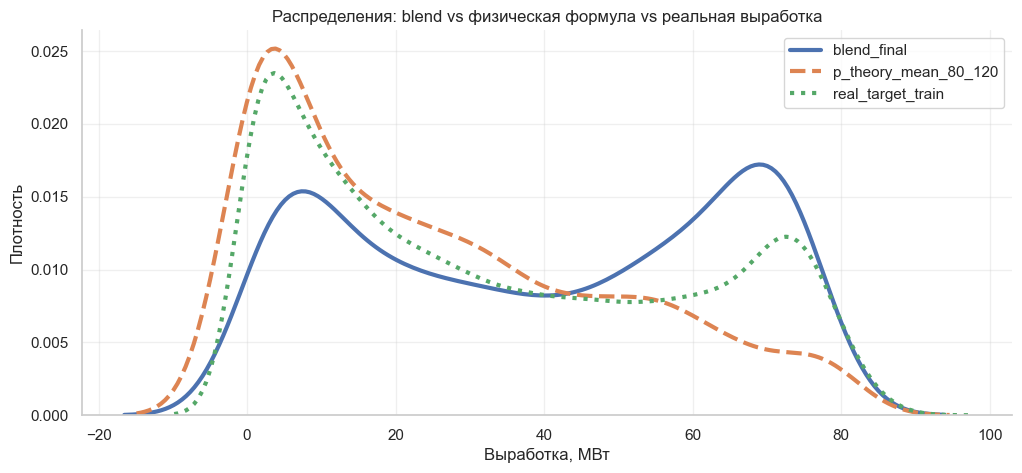

In [201]:
if PLOT_FINAL_DISTRIBUTIONS:
    # ------------------------------------------------------------

    plt.figure(figsize=(12, 5))

    sns.kdeplot(
        blend_values,
        label="blend_final",
        linewidth=3,
    )

    sns.kdeplot(
        theory_values,
        label=theory_col,
        linewidth=3,
        linestyle="--",
    )

    sns.kdeplot(
        real_values,
        label=real_label,
        linewidth=3,
        linestyle=":",
    )

    plt.title("Распределения: blend vs физическая формула vs реальная выработка")
    plt.xlabel("Выработка, МВт")
    plt.ylabel("Плотность")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


In [202]:
if PLOT_FINAL_DISTRIBUTIONS:
    # ------------------------------------------------------------

    power_bins = [0, 1, 5, 10, 20, 40, 60, 80, 91]
    power_labels = [
        "0-1",
        "1-5",
        "5-10",
        "10-20",
        "20-40",
        "40-60",
        "60-80",
        "80-90",
    ]

    def make_power_bin_report(values, source_name):
        temp = pd.DataFrame({
            "value": pd.Series(values).clip(0, INSTALLED_CAPACITY_MW)
        })

        temp["power_bin"] = pd.cut(
            temp["value"],
            bins=power_bins,
            labels=power_labels,
            include_lowest=True,
        )

        report = (
            temp
            .groupby("power_bin", observed=True)
            .agg(
                count=("value", "size"),
                mean=("value", "mean"),
                median=("value", "median"),
                min_value=("value", "min"),
                max_value=("value", "max"),
            )
            .reset_index()
        )

        report["share"] = report["count"] / report["count"].sum()
        report["source"] = source_name

        return report

    blend_bin_report = make_power_bin_report(
        blend_values,
        "blend_final",
    )

    theory_bin_report = make_power_bin_report(
        theory_values,
        theory_col,
    )

    real_bin_report = make_power_bin_report(
        real_values,
        real_label,
    )

    distribution_compare = pd.concat(
        [
            blend_bin_report,
            theory_bin_report,
            real_bin_report,
        ],
        ignore_index=True,
        sort=False,
    )

    print("Сравнение распределений по бинам: blend vs theory vs real")
    display(distribution_compare)


Сравнение распределений по бинам: blend vs theory vs real


,power_bin,count,mean,median,min_value,max_value,share,source
0,0-1,29,0.406436,0.406344,0.000000,0.988508,0.013641,blend_final
1,1-5,198,3.015257,3.068225,1.033703,4.981036,0.093133,blend_final
2,5-10,186,7.685304,7.849145,5.058259,9.963027,0.087488,blend_final
3,10-20,248,14.728528,14.666432,10.023204,19.981457,0.116651,blend_final
4,20-40,378,29.409110,29.335178,20.129818,39.959980,0.177799,blend_final
5,40-60,419,50.904727,51.812008,40.020299,59.996796,0.197084,blend_final
6,60-80,668,69.433410,70.052978,60.023454,77.354520,0.314205,blend_final
7,0-1,266,0.157007,0.000000,0.000000,0.993881,0.125118,p_theory_mean_80_120
8,1-5,252,2.819296,2.662929,1.006108,4.995777,0.118532,p_theory_mean_80_120
9,5-10,236,7.234880,7.140594,5.024501,9.984118,0.111007,p_theory_mean_80_120


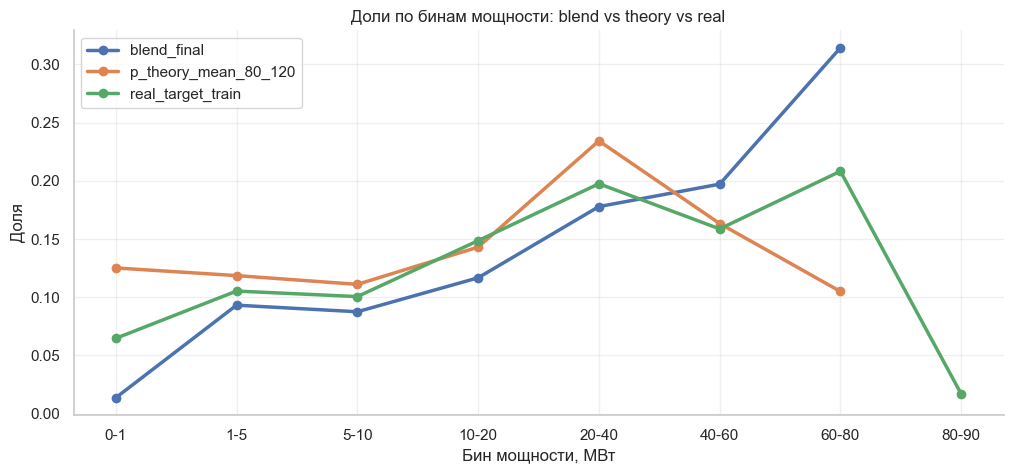

In [203]:
if PLOT_FINAL_DISTRIBUTIONS:
    # ------------------------------------------------------------

    plt.figure(figsize=(12, 5))

    for source, part in distribution_compare.groupby("source"):
        plt.plot(
            part["power_bin"].astype(str),
            part["share"],
            marker="o",
            linewidth=2.5,
            label=source,
        )

    plt.title("Доли по бинам мощности: blend vs theory vs real")
    plt.xlabel("Бин мощности, МВт")
    plt.ylabel("Доля")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


## 14. Intermediate prediction check

Проверяем форму, диапазоны и базовую статистику direct-прогноза до финального two-stage blend.

In [204]:
print("=" * 90)
print("DIRECT INTERMEDIATE IN-MEMORY CHECK")
print("=" * 90)

if "direct_pred_clip" in globals() and "valid_model" in globals():
    sub = valid_model[["row_id"]].copy()
    sub["target"] = np.clip(np.asarray(direct_pred_clip, dtype=float), 0, INSTALLED_CAPACITY_MW)
    sub = sub.sort_values("row_id")[["target"]].reset_index(drop=True)
    print("shape:", sub.shape)
    display(sub.head())
    display(sub.describe())
else:
    print("Direct intermediate prediction is not available yet. Run the final training block first.")


DIRECT INTERMEDIATE IN-MEMORY CHECK
shape: (2126, 1)


,target
0,6.800735
1,15.539157
2,17.510495
3,15.988153
4,13.572393


,target
count,2126.000000
mean,39.754559
std,25.521817
min,0.000000
25%,14.404152
50%,41.342045
75%,64.893069
max,77.354520


## 15. Power curve diagnostics

Диагностика показывает, как факт, raw-прогноз и clipped-прогноз ведут себя по бинам скорости ветра.

In [205]:

# Диагностика кривой мощности управляется глобальным флагом RUN_POWER_CURVE_DIAGNOSTIC.
print("RUN_POWER_CURVE_DIAGNOSTIC:", RUN_POWER_CURVE_DIAGNOSTIC)


RUN_POWER_CURVE_DIAGNOSTIC: True



Обучение ансамбля: DIAG_research_pipeline_empirical_high_wind_clip
MAE raw : 7.74015592052028
MAE clip: 7.70659157930081
delta   : -0.03356434121946972


,speed_bin,count,speed_mean,fact_mean,fact_median,pred_raw_mean,pred_clip_mean,cap_mean,mae_raw,mae_clip,bias_raw,bias_clip,clip_delta_mean,mae_delta_clip_vs_raw
18,"(9.0, 9.5]",270,9.262296,48.292993,52.0530,50.508804,50.508804,75.992650,11.610894,11.610894,2.215812,2.215812,0.000000,0.000000
19,"(9.5, 10.0]",222,9.745315,49.162374,50.0925,54.370618,54.370618,75.992650,11.118085,11.118085,5.208245,5.208245,0.000000,0.000000
17,"(8.5, 9.0]",301,8.760963,45.170478,45.5170,45.529219,45.529219,75.992650,10.516494,10.516494,0.358740,0.358740,0.000000,0.000000
15,"(7.5, 8.0]",327,7.743364,36.978667,37.7340,36.241853,36.241853,75.992650,10.347486,10.347486,-0.736813,-0.736813,0.000000,0.000000
16,"(8.0, 8.5]",324,8.262006,39.550052,39.7095,40.730944,40.730944,75.992650,10.279235,10.279235,1.180892,1.180892,0.000000,0.000000
21,"(10.5, 11.0]",172,10.726047,57.978267,62.9295,61.974461,61.966717,75.992650,10.150268,10.145829,3.996194,3.988449,-0.007745,-0.004439
14,"(7.0, 7.5]",363,7.259008,31.773187,29.8330,30.117571,30.117571,75.992650,10.104699,10.104699,-1.655616,-1.655616,0.000000,0.000000
20,"(10.0, 10.5]",214,10.224019,55.279790,58.1815,58.446692,58.446088,75.992650,9.704045,9.703559,3.166902,3.166298,-0.000604,-0.000486
25,"(12.5, 13.0]",68,12.746471,63.814132,69.2750,71.412791,70.992662,77.000000,9.578399,9.158270,7.598658,7.178529,-0.420129,-0.420129
13,"(6.5, 7.0]",385,6.750208,26.622135,25.0380,24.792771,24.792771,75.992650,9.312510,9.312510,-1.829364,-1.829364,0.000000,0.000000


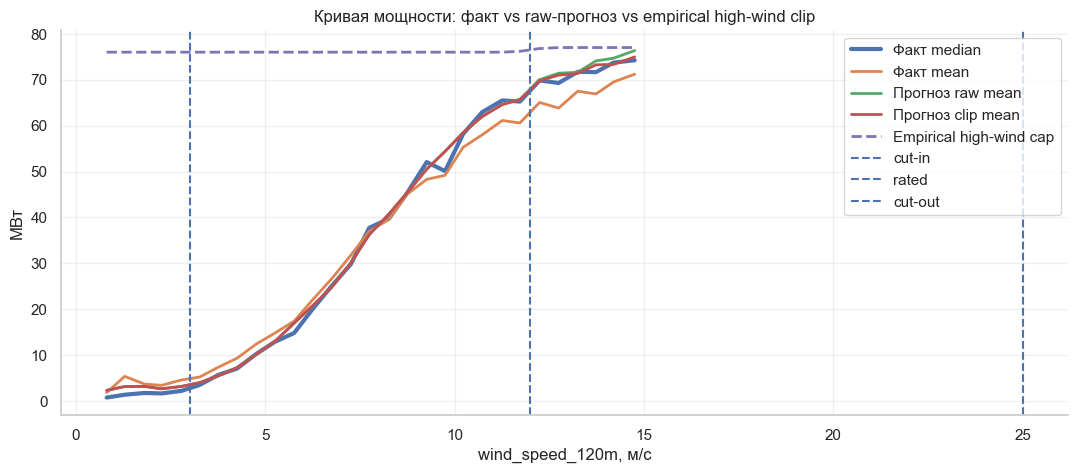

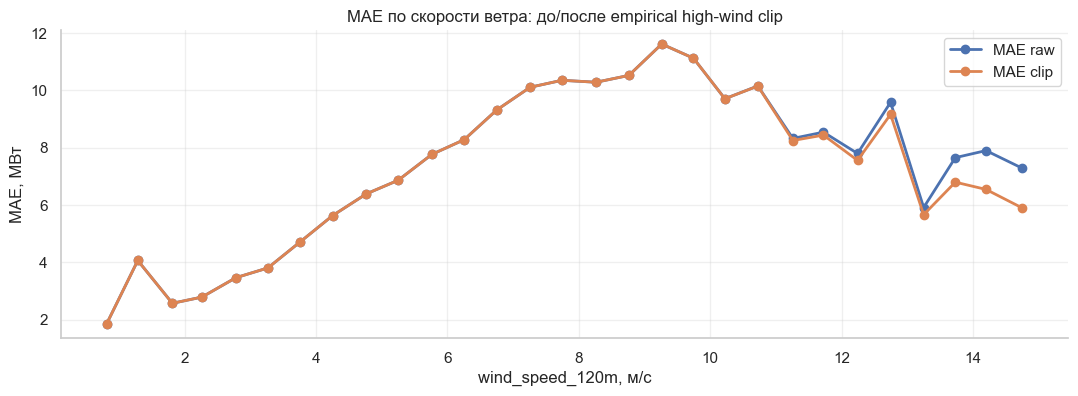

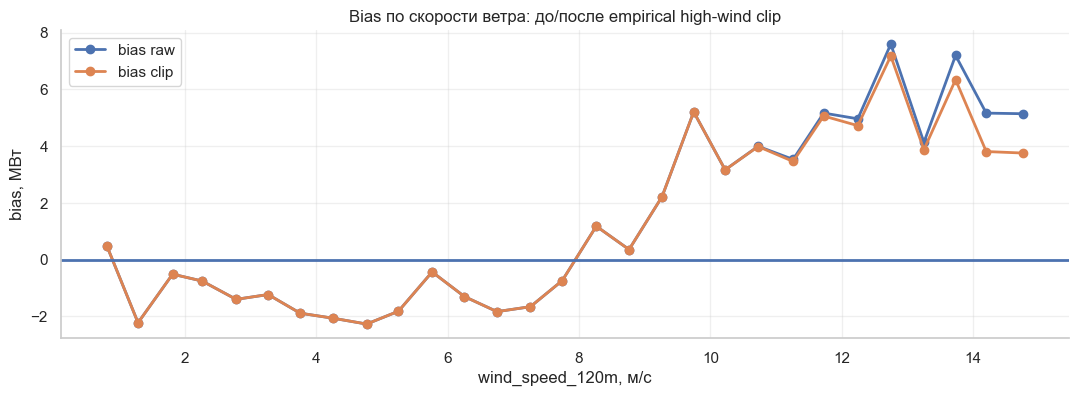

In [206]:
if RUN_POWER_CURVE_DIAGNOSTIC:
    if "train_model" not in globals() or "model_features" not in globals():
        raise NameError("Сначала выполни финальное обучение или собери train_model/model_features.")

    if "POWER_CURVE_SPEED_BINS" not in globals():
        POWER_CURVE_SPEED_BINS = globals().get("EMPIRICAL_SPEED_BINS", np.arange(0, 26.5, 0.5))
    if "POWER_CURVE_MIN_BIN_COUNT" not in globals():
        POWER_CURVE_MIN_BIN_COUNT = globals().get("EMPIRICAL_MIN_BIN_COUNT", 20)

    diag_split_idx = int(len(train_model) * 0.8)
    diag_train_part = train_model.iloc[:diag_split_idx].copy().reset_index(drop=True)
    diag_eval_part = train_model.iloc[diag_split_idx:].copy().reset_index(drop=True)

    diag_models = fit_ensemble(
        diag_train_part,
        model_features,
        label="DIAG_research_pipeline_empirical_high_wind_clip",
        fast_mode=True,
    )

    diag_pred_raw, _ = predict_ensemble(
        diag_models,
        diag_eval_part,
        model_features,
    )

    diag_cap_curve = fit_high_wind_cap_curve(
        diag_train_part,
        speed_col=HIGH_WIND_SPEED_COL,
        target_col="target",
    )

    diag_pred_clip, diag_clip_info = apply_high_wind_smart_clip(
        diag_eval_part,
        diag_pred_raw,
        diag_cap_curve,
        speed_col=HIGH_WIND_SPEED_COL,
    )

    pc_df = diag_eval_part.copy()
    pc_df["y_true"] = pc_df["target"].clip(0, INSTALLED_CAPACITY_MW)
    pc_df["y_pred_raw"] = np.clip(diag_pred_raw, 0, INSTALLED_CAPACITY_MW)
    pc_df["y_pred_clip"] = np.clip(diag_pred_clip, 0, INSTALLED_CAPACITY_MW)
    pc_df["error_raw"] = pc_df["y_pred_raw"] - pc_df["y_true"]
    pc_df["error_clip"] = pc_df["y_pred_clip"] - pc_df["y_true"]
    pc_df["abs_error_raw"] = pc_df["error_raw"].abs()
    pc_df["abs_error_clip"] = pc_df["error_clip"].abs()
    pc_df["clip_delta"] = diag_clip_info["clip_delta"].to_numpy()
    pc_df["high_wind_cap_final"] = diag_clip_info["high_wind_cap_final"].to_numpy()

    mae_raw = mean_absolute_error(pc_df["y_true"], pc_df["y_pred_raw"])
    mae_clip = mean_absolute_error(pc_df["y_true"], pc_df["y_pred_clip"])

    print("MAE raw :", mae_raw)
    print("MAE clip:", mae_clip)
    print("delta   :", mae_clip - mae_raw)

    if RUN_HIGH_WIND_CLIP_TUNING:
        print("\nGrid-search params на diagnostic split:")
        diag_tuning = tune_high_wind_clip_params(
            train_part=diag_train_part,
            eval_part=diag_eval_part,
            eval_pred=diag_pred_raw,
            target_col="target",
            speed_col=HIGH_WIND_SPEED_COL,
        )
        display(diag_tuning.head(20))

    pc_df["speed_bin"] = pd.cut(
        pc_df[HIGH_WIND_SPEED_COL],
        bins=POWER_CURVE_SPEED_BINS,
        include_lowest=True,
    )

    curve_report = (
        pc_df
        .groupby("speed_bin", observed=True)
        .agg(
            count=("y_true", "size"),
            speed_mean=(HIGH_WIND_SPEED_COL, "mean"),
            fact_mean=("y_true", "mean"),
            fact_median=("y_true", "median"),
            pred_raw_mean=("y_pred_raw", "mean"),
            pred_clip_mean=("y_pred_clip", "mean"),
            cap_mean=("high_wind_cap_final", "mean"),
            mae_raw=("abs_error_raw", "mean"),
            mae_clip=("abs_error_clip", "mean"),
            bias_raw=("error_raw", "mean"),
            bias_clip=("error_clip", "mean"),
            clip_delta_mean=("clip_delta", "mean"),
        )
        .reset_index()
    )

    curve_report = curve_report[curve_report["count"] >= POWER_CURVE_MIN_BIN_COUNT].copy()
    curve_report["mae_delta_clip_vs_raw"] = curve_report["mae_clip"] - curve_report["mae_raw"]

    display(curve_report.sort_values("mae_raw", ascending=False).head(15))

    plt.figure(figsize=(13, 5))
    plt.plot(curve_report["speed_mean"], curve_report["fact_median"], linewidth=3, label="Факт median")
    plt.plot(curve_report["speed_mean"], curve_report["fact_mean"], linewidth=2, label="Факт mean")
    plt.plot(curve_report["speed_mean"], curve_report["pred_raw_mean"], linewidth=2, label="Прогноз raw mean")
    plt.plot(curve_report["speed_mean"], curve_report["pred_clip_mean"], linewidth=2, label="Прогноз clip mean")
    plt.plot(curve_report["speed_mean"], curve_report["cap_mean"], linewidth=2, linestyle="--", label="Empirical high-wind cap")
    plt.axvline(CUT_IN_SPEED, linestyle="--", linewidth=1.5, label="cut-in")
    plt.axvline(RATED_SPEED, linestyle="--", linewidth=1.5, label="rated")
    plt.axvline(CUT_OUT_SPEED, linestyle="--", linewidth=1.5, label="cut-out")
    plt.title("Кривая мощности: факт vs raw-прогноз vs empirical high-wind clip")
    plt.xlabel(f"{HIGH_WIND_SPEED_COL}, м/с")
    plt.ylabel("МВт")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(13, 4))
    plt.plot(curve_report["speed_mean"], curve_report["mae_raw"], marker="o", linewidth=2, label="MAE raw")
    plt.plot(curve_report["speed_mean"], curve_report["mae_clip"], marker="o", linewidth=2, label="MAE clip")
    plt.title("MAE по скорости ветра: до/после empirical high-wind clip")
    plt.xlabel(f"{HIGH_WIND_SPEED_COL}, м/с")
    plt.ylabel("MAE, МВт")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(13, 4))
    plt.plot(curve_report["speed_mean"], curve_report["bias_raw"], marker="o", linewidth=2, label="bias raw")
    plt.plot(curve_report["speed_mean"], curve_report["bias_clip"], marker="o", linewidth=2, label="bias clip")
    plt.axhline(0, linewidth=2)
    plt.title("Bias по скорости ветра: до/после empirical high-wind clip")
    plt.xlabel(f"{HIGH_WIND_SPEED_COL}, м/с")
    plt.ylabel("bias, МВт")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("Диагностика кривой мощности выключена. Для запуска поставь RUN_POWER_CURVE_DIAGNOSTIC=True.")

## 16. Two-stage correction

Two-stage блок разделяет задачу на нормальное поведение станции и residual/deviation поправку. Финальный прогноз смешивает direct ensemble и two-stage prediction, после чего применяется high-wind post-processing.

In [207]:

# ============================================================
# TWO-STAGE DEVIATION CONFIG
# ============================================================

# Параметры two-stage correction заданы в секции глобальных настроек.
print("TWO_STAGE_ENABLED:", TWO_STAGE_ENABLED)
print("TWO_STAGE_FAST_MODE:", TWO_STAGE_FAST_MODE)
print("TWO_STAGE_N_SPLITS:", TWO_STAGE_N_SPLITS)
print("FINAL_TWO_STAGE_ALPHA:", FINAL_TWO_STAGE_ALPHA)
print("TS_DIR:", TS_DIR)


TWO_STAGE_ENABLED: True
TWO_STAGE_FAST_MODE: False
TWO_STAGE_N_SPLITS: 5
FINAL_TWO_STAGE_ALPHA: 0.1
TS_DIR: outputs\ts


In [208]:
# ============================================================
# TWO-STAGE HELPERS
# ============================================================


In [209]:
def _ts_existing_cols(train_df, valid_df, cols):
    return list(dict.fromkeys([
        c for c in cols
        if c in train_df.columns and c in valid_df.columns
    ]))


In [210]:
def _ts_forbidden_feature(c):
    c_low = str(c).lower()
    if c_low in {"target", "row_id", "source"}:
        return True
    if c.endswith("_train_only"):
        return True
    if "выработка" in c_low:
        return True
    return False


In [211]:
def _ts_clean_feature_list(train_df, valid_df, cols):
    cols = _ts_existing_cols(train_df, valid_df, cols)
    return [c for c in cols if not _ts_forbidden_feature(c)]


In [212]:
def _ts_prepare_matrix(train_df, valid_df, cols):
    cols = _ts_clean_feature_list(train_df, valid_df, cols)

    x_train = train_df[cols].copy()
    x_valid = valid_df[cols].copy()

    x_train = x_train.replace([np.inf, -np.inf], np.nan)
    x_valid = x_valid.replace([np.inf, -np.inf], np.nan)

    med = x_train.median(numeric_only=True)
    x_train = x_train.fillna(med).fillna(0)
    x_valid = x_valid.fillna(med).fillna(0)

    return x_train, x_valid, cols


In [213]:
def _ts_save_submission(valid_frame, pred, path):
    pred = np.asarray(pred, dtype=float)
    pred = np.clip(pred, 0, INSTALLED_CAPACITY_MW)

    if "row_id" not in valid_frame.columns:
        raise KeyError("В valid_frame нет row_id, не могу восстановить порядок submission.")

    sub = valid_frame[["row_id"]].copy()
    sub["target"] = pred
    sub = sub.sort_values("row_id")[["target"]].reset_index(drop=True)
    sub.to_csv(path, index=False)
    print("Saved:", path, "shape:", sub.shape)
    return sub


In [214]:
def _ts_apply_clip(train_frame, valid_frame, pred_raw, suffix):
    pred_raw = np.clip(np.asarray(pred_raw, dtype=float), 0, INSTALLED_CAPACITY_MW)

    if "HIGH_WIND_CLIP_ENABLED" not in globals() or not HIGH_WIND_CLIP_ENABLED:
        diag = pd.DataFrame({
            "pred_raw": pred_raw,
            "pred_clipped": pred_raw,
            "clip_delta": np.zeros(len(pred_raw)),
        })
        return pred_raw, diag

    cap_curve = fit_high_wind_cap_curve(
        train_frame,
        speed_col=HIGH_WIND_SPEED_COL,
        target_col="target",
    )

    pred_clip, clip_diag = apply_high_wind_smart_clip(
        valid_frame,
        pred_raw,
        cap_curve,
        speed_col=HIGH_WIND_SPEED_COL,
    )

    if SAVE_DIAGNOSTIC_ARTIFACTS:
        TS_DIR.mkdir(parents=True, exist_ok=True)
        cap_curve.to_csv(TS_DIR / f"high_wind_cap_curve_{suffix}.csv", index=False)
        clip_diag.to_csv(TS_DIR / f"high_wind_clip_diag_{suffix}.csv", index=False)

    return np.clip(pred_clip, 0, INSTALLED_CAPACITY_MW), clip_diag


In [215]:
def _ts_hgb_l1(seed, fast=False):
    return HistGradientBoostingRegressor(
        loss="absolute_error",
        learning_rate=0.040 if not fast else 0.060,
        max_iter=520 if not fast else 220,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        l2_regularization=0.06,
        early_stopping=True,
        validation_fraction=0.12,
        random_state=seed,
    )


In [216]:
def _ts_hgb_l2(seed, fast=False):
    return HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.040 if not fast else 0.060,
        max_iter=520 if not fast else 220,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        l2_regularization=0.04,
        early_stopping=True,
        validation_fraction=0.12,
        random_state=seed,
    )


In [217]:
def _ts_hgb_q50(seed, fast=False):
    return HistGradientBoostingRegressor(
        loss="quantile",
        quantile=0.50,
        learning_rate=0.040 if not fast else 0.060,
        max_iter=500 if not fast else 220,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        l2_regularization=0.06,
        early_stopping=True,
        validation_fraction=0.12,
        random_state=seed,
    )


In [218]:
def _ts_cat_mae(seed, fast=False):
    return CatBoostRegressor(
        iterations=650 if not fast else 250,
        learning_rate=0.035 if not fast else 0.055,
        depth=5,
        loss_function="MAE",
        random_seed=seed,
        verbose=0,
        allow_writing_files=False,
    )


In [219]:
def _ts_lgb_l1(seed, fast=False):
    return lgb.LGBMRegressor(
        objective="regression_l1",
        n_estimators=650 if not fast else 250,
        learning_rate=0.030 if not fast else 0.050,
        num_leaves=31,
        min_child_samples=35,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_lambda=1.5,
        random_state=seed,
        verbosity=-1,
    )


In [220]:
def _ts_xgb_l1(seed, fast=False):
    return XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=650 if not fast else 250,
        learning_rate=0.030 if not fast else 0.050,
        max_depth=5,
        min_child_weight=20,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_lambda=2.5,
        tree_method="hist",
        random_state=seed,
    )


In [221]:
def _ts_model_bank(kind, fast=False):
    if kind == "normal":
        return {
            "normal_hgb_l1": lambda seed: _ts_hgb_l1(seed, fast),
            "normal_hgb_l2": lambda seed: _ts_hgb_l2(seed, fast),
            "normal_hgb_q50": lambda seed: _ts_hgb_q50(seed, fast),
            "normal_cat_mae": lambda seed: _ts_cat_mae(seed, fast),
        }

    if kind == "deviation":
        return {
            "dev_hgb_l1": lambda seed: _ts_hgb_l1(seed, fast),
            "dev_hgb_q50": lambda seed: _ts_hgb_q50(seed, fast),
            "dev_lgb_l1": lambda seed: _ts_lgb_l1(seed, fast),
            "dev_xgb_l1": lambda seed: _ts_xgb_l1(seed, fast),
            "dev_cat_mae": lambda seed: _ts_cat_mae(seed, fast),
        }

    raise ValueError(f"unknown kind: {kind}")


In [222]:
def _ts_oof_and_valid_predictions(
    train_frame,
    valid_frame,
    feature_cols,
    y,
    model_bank,
    n_splits=5,
    clip_pred=None,
    label="stage",
):
    x_train, x_valid, used_cols = _ts_prepare_matrix(train_frame, valid_frame, feature_cols)
    y = np.asarray(y, dtype=float)

    tscv = TimeSeriesSplit(n_splits=n_splits, gap=24)

    oof_components = {}
    valid_components = {}
    fold_rows = []

    for model_i, (model_name, factory) in enumerate(model_bank.items(), 1):
        print("=" * 100)
        print(label, "model:", model_name)

        oof = np.full(len(train_frame), np.nan, dtype=float)
        valid_fold_preds = []

        for fold, (tr_idx, va_idx) in enumerate(tscv.split(x_train), 1):
            model = factory(RANDOM_STATE + 1000 * model_i + fold)
            model.fit(x_train.iloc[tr_idx], y[tr_idx])

            fold_pred = np.asarray(model.predict(x_train.iloc[va_idx]), dtype=float)
            valid_pred = np.asarray(model.predict(x_valid), dtype=float)

            if clip_pred is not None:
                fold_pred = np.clip(fold_pred, clip_pred[0], clip_pred[1])
                valid_pred = np.clip(valid_pred, clip_pred[0], clip_pred[1])

            oof[va_idx] = fold_pred
            valid_fold_preds.append(valid_pred)

            fold_mae = mean_absolute_error(y[va_idx], fold_pred)
            fold_rows.append({
                "stage": label,
                "model": model_name,
                "fold": fold,
                "mae": fold_mae,
                "n_train": len(tr_idx),
                "n_valid": len(va_idx),
            })

            print(f"fold {fold}: MAE={fold_mae:.6f}, n_train={len(tr_idx)}, n_valid={len(va_idx)}")

        if np.isnan(oof).any():
            fill_value = float(np.nanmedian(oof))
            oof = np.where(np.isnan(oof), fill_value, oof)
            print("OOF head rows filled by median:", fill_value)

        oof_components[model_name] = oof
        valid_components[model_name] = np.mean(valid_fold_preds, axis=0)

    oof_df = pd.DataFrame(oof_components)
    valid_df = pd.DataFrame(valid_components)

    oof_mean = oof_df.mean(axis=1).to_numpy()
    valid_mean = valid_df.mean(axis=1).to_numpy()

    if clip_pred is not None:
        oof_mean = np.clip(oof_mean, clip_pred[0], clip_pred[1])
        valid_mean = np.clip(valid_mean, clip_pred[0], clip_pred[1])

    fold_report = pd.DataFrame(fold_rows)
    return oof_mean, valid_mean, oof_df, valid_df, fold_report, used_cols


In [223]:
# ============================================================
# TWO-STAGE DATASET BUILD
# ============================================================

if TWO_STAGE_ENABLED:
    if "train_model" not in globals() or "valid_model" not in globals() or "model_features" not in globals():
        print("train_model/valid_model не найдены — собираю build_model_frames() заново.")
        train_model, valid_model, layout_added_features, model_features = build_model_frames()

    ts_train = train_model.copy().reset_index(drop=True)
    ts_valid = valid_model.copy().reset_index(drop=True)

    if "datetime" in ts_train.columns:
        ts_train = ts_train.sort_values("datetime").reset_index(drop=True)

    base_ts_cols = _ts_clean_feature_list(ts_train, ts_valid, model_features)

    normal_feature_cols = [
        c for c in base_ts_cols
        if not any(key in c for key in TWO_STAGE_DEVIATION_KEYWORDS)
    ]

    if len(normal_feature_cols) < 20:
        print("Недостаточно normal_feature_cols, используется base_ts_cols")
        normal_feature_cols = base_ts_cols.copy()

    deviation_feature_cols = base_ts_cols.copy()


    if SAVE_DIAGNOSTIC_ARTIFACTS:
        TS_DIR.mkdir(parents=True, exist_ok=True)
        pd.DataFrame({"feature": base_ts_cols}).to_csv(TS_DIR / "base_ts_features.csv", index=False)
        pd.DataFrame({"feature": normal_feature_cols}).to_csv(TS_DIR / "normal_features.csv", index=False)
        pd.DataFrame({"feature": deviation_feature_cols}).to_csv(TS_DIR / "deviation_features_initial.csv", index=False)
else:
    print("TWO_STAGE_ENABLED=False")

In [224]:
# ============================================================
# STAGE A: normal behavior model
# ============================================================

if TWO_STAGE_ENABLED:
    y_train = ts_train["target"].clip(0, INSTALLED_CAPACITY_MW).to_numpy()

    normal_oof_pred, normal_valid_pred, normal_oof_components, normal_valid_components, normal_fold_report, normal_used_cols = _ts_oof_and_valid_predictions(
        ts_train,
        ts_valid,
        normal_feature_cols,
        y_train,
        _ts_model_bank("normal", fast=TWO_STAGE_FAST_MODE),
        n_splits=TWO_STAGE_N_SPLITS,
        clip_pred=(0.0, INSTALLED_CAPACITY_MW),
        label="normal",
    )

    ts_train["two_stage_normal_pred"] = np.clip(normal_oof_pred, 0, INSTALLED_CAPACITY_MW)
    ts_valid["two_stage_normal_pred"] = np.clip(normal_valid_pred, 0, INSTALLED_CAPACITY_MW)

    normal_mae = mean_absolute_error(y_train, ts_train["two_stage_normal_pred"])
    normal_stage_summary = pd.DataFrame([{
        "stage": "A_normal_behavior",
        "oof_mae": normal_mae,
        "n_splits": TWO_STAGE_N_SPLITS,
    }])

    normal_oof_save = normal_oof_components.copy()
    normal_oof_save["target"] = y_train
    normal_oof_save["two_stage_normal_pred"] = ts_train["two_stage_normal_pred"].to_numpy()
    normal_oof_save["normal_residual"] = y_train - ts_train["two_stage_normal_pred"].to_numpy()
    if "datetime" in ts_train.columns:
        normal_oof_save.insert(0, "datetime", ts_train["datetime"].to_numpy())

    normal_valid_save = normal_valid_components.copy()
    normal_valid_save["two_stage_normal_pred"] = ts_valid["two_stage_normal_pred"].to_numpy()
    if "datetime" in ts_valid.columns:
        normal_valid_save.insert(0, "datetime", ts_valid["datetime"].to_numpy())

    if SAVE_DIAGNOSTIC_ARTIFACTS:
        TS_DIR.mkdir(parents=True, exist_ok=True)
        normal_oof_save.to_csv(TS_DIR / "stage_a_normal_oof.csv", index=False)
        normal_valid_save.to_csv(TS_DIR / "stage_a_normal_valid.csv", index=False)
        normal_fold_report.to_csv(TS_DIR / "stage_a_normal_fold_report.csv", index=False)
        pd.DataFrame({"feature": normal_used_cols}).to_csv(TS_DIR / "stage_a_normal_used_features.csv", index=False)

    display(Markdown(
        "### Two-stage A: normal behavior\n\n"
        "OOF-качество normal-моделей и средняя ошибка по model bank."
    ))
    display(normal_stage_summary)
    display(normal_fold_report.groupby("model", as_index=False)["mae"].mean().sort_values("mae"))

normal model: normal_hgb_l1
fold 1: MAE=9.106698, n_train=5385, n_valid=5405
fold 2: MAE=9.081525, n_train=10790, n_valid=5405
fold 3: MAE=8.935941, n_train=16195, n_valid=5405
fold 4: MAE=7.530840, n_train=21600, n_valid=5405
fold 5: MAE=7.821096, n_train=27005, n_valid=5405
OOF head rows filled by median: 26.431711443368865
normal model: normal_hgb_l2
fold 1: MAE=9.097202, n_train=5385, n_valid=5405
fold 2: MAE=9.069827, n_train=10790, n_valid=5405
fold 3: MAE=9.087587, n_train=16195, n_valid=5405
fold 4: MAE=7.657229, n_train=21600, n_valid=5405
fold 5: MAE=7.796182, n_train=27005, n_valid=5405
OOF head rows filled by median: 27.04466950992246
normal model: normal_hgb_q50
fold 1: MAE=9.121651, n_train=5385, n_valid=5405
fold 2: MAE=9.023186, n_train=10790, n_valid=5405
fold 3: MAE=8.989202, n_train=16195, n_valid=5405
fold 4: MAE=7.477536, n_train=21600, n_valid=5405
fold 5: MAE=7.819389, n_train=27005, n_valid=5405
OOF head rows filled by median: 26.630259453704554
normal model: no

### Two-stage A: normal behavior

OOF-качество normal-моделей и средняя ошибка по model bank.

,stage,oof_mae,n_splits
0,A_normal_behavior,10.670317,5


,model,mae
0,normal_cat_mae,8.474447
3,normal_hgb_q50,8.486193
1,normal_hgb_l1,8.495220
2,normal_hgb_l2,8.541606


In [225]:
# ============================================================
# STAGE B: robust target for deviation model
# ============================================================

if TWO_STAGE_ENABLED:
    ts_train["two_stage_deviation_target_raw"] = (
        ts_train["target"].clip(0, INSTALLED_CAPACITY_MW)
        - ts_train["two_stage_normal_pred"]
    )

    dev_q_low = float(ts_train["two_stage_deviation_target_raw"].quantile(TWO_STAGE_RESIDUAL_Q_LOW))
    dev_q_high = float(ts_train["two_stage_deviation_target_raw"].quantile(TWO_STAGE_RESIDUAL_Q_HIGH))

    dev_clip_low = dev_q_low * TWO_STAGE_RESIDUAL_CLIP_MULT
    dev_clip_high = dev_q_high * TWO_STAGE_RESIDUAL_CLIP_MULT

    if dev_clip_low > dev_clip_high:
        dev_clip_low, dev_clip_high = dev_clip_high, dev_clip_low

    ts_train["two_stage_deviation_target"] = (
        ts_train["two_stage_deviation_target_raw"]
        .clip(dev_clip_low, dev_clip_high)
    )

    ts_train["two_stage_dev_train_weight"] = 1.0

    if TWO_STAGE_DROP_BAD_OOF_HEAD:
        bad_head_end = int(len(ts_train) * TWO_STAGE_BAD_HEAD_FRAC)
        ts_train.loc[:bad_head_end, "two_stage_dev_train_weight"] = 0.0
        print("Residual bad OOF head disabled rows:", bad_head_end)

    residual_train_mask = (
        np.isfinite(ts_train["two_stage_deviation_target"].to_numpy(dtype=float))
        & (ts_train["two_stage_dev_train_weight"].to_numpy(dtype=float) > 0)
    )

    deviation_target_rows = []
    for name, col in [
        ("deviation_target_raw", "two_stage_deviation_target_raw"),
        ("deviation_target_clipped", "two_stage_deviation_target"),
    ]:
        s = pd.to_numeric(ts_train[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        deviation_target_rows.append({
            "series": name,
            "mean": s.mean(),
            "std": s.std(),
            "min": s.min(),
            "p05": s.quantile(0.05),
            "p50": s.quantile(0.50),
            "p95": s.quantile(0.95),
            "max": s.max(),
        })
    deviation_target_summary = pd.DataFrame(deviation_target_rows)
    deviation_target_meta = pd.DataFrame([{
        "dev_clip_low": dev_clip_low,
        "dev_clip_high": dev_clip_high,
        "residual_train_rows": int(residual_train_mask.sum()),
        "total_rows": len(residual_train_mask),
        "used_share": float(residual_train_mask.mean()),
    }])

    display(Markdown(
        "### Two-stage B: target отклонения\n\n"
        "Residual-модель учит поправку к normal-предсказанию."
    ))
    display(deviation_target_meta)
    display(deviation_target_summary)

    if PLOT_RESEARCH_OUTPUTS:
        plt.figure(figsize=(11, 4.2))
        sns.kdeplot(ts_train["two_stage_deviation_target_raw"], label="raw", linewidth=2)
        sns.kdeplot(ts_train["two_stage_deviation_target"], label="clipped", linewidth=2)
        plt.axvline(0, linestyle="--", color="black", linewidth=1.2)
        plt.title("Two-stage deviation target: raw vs clipped")
        plt.xlabel("МВт")
        plt.legend()
        plt.tight_layout()
        plot_path = RESEARCH_PLOT_DIR / "09_twostage_deviation_target_distribution.png"
        plt.savefig(plot_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved plot:", plot_path)

### Two-stage B: target отклонения

Residual-модель учит поправку к normal-предсказанию.

,dev_clip_low,dev_clip_high,residual_train_rows,total_rows,used_share
0,-48.424677,68.023657,32434,32434,1.0


,series,mean,std,min,p05,p50,p95,max
0,deviation_target_raw,1.785939,15.333937,-73.986197,-21.979868,0.155706,30.589946,69.537041
1,deviation_target_clipped,1.816684,15.216023,-48.424677,-21.979868,0.155706,30.589946,68.023657


In [226]:
# ============================================================
# STAGE B: meta features explaining normal-vs-physics mismatch
# ============================================================

if TWO_STAGE_ENABLED:
    for frame in [ts_train, ts_valid]:
        if "p_empirical_mean_80_120" in frame.columns:
            frame["two_stage_normal_minus_empirical"] = frame["two_stage_normal_pred"] - frame["p_empirical_mean_80_120"]
            frame["two_stage_normal_div_empirical"] = frame["two_stage_normal_pred"] / (frame["p_empirical_mean_80_120"].abs() + EPS)

        if "p_theory_mean_80_120" in frame.columns:
            frame["two_stage_normal_minus_theory"] = frame["two_stage_normal_pred"] - frame["p_theory_mean_80_120"]
            frame["two_stage_normal_div_theory"] = frame["two_stage_normal_pred"] / (frame["p_theory_mean_80_120"].abs() + EPS)

        if "full_p_ideal_clean" in frame.columns:
            frame["two_stage_normal_minus_ideal_clean"] = frame["two_stage_normal_pred"] - frame["full_p_ideal_clean"]
            frame["two_stage_normal_div_ideal_clean"] = frame["two_stage_normal_pred"] / (frame["full_p_ideal_clean"].abs() + EPS)

        if "full_hidden_loss_mw_pred" in frame.columns:
            frame["two_stage_normal_x_hidden_loss"] = (
                frame["two_stage_normal_pred"] * frame["full_hidden_loss_mw_pred"] / INSTALLED_CAPACITY_MW
            )

        if "layout_wake_risk_scalar_120m" in frame.columns:
            frame["two_stage_normal_x_wake_risk"] = frame["two_stage_normal_pred"] * frame["layout_wake_risk_scalar_120m"]

    two_stage_meta_cols = [
        "two_stage_normal_pred",
        "two_stage_normal_minus_empirical",
        "two_stage_normal_div_empirical",
        "two_stage_normal_minus_theory",
        "two_stage_normal_div_theory",
        "two_stage_normal_minus_ideal_clean",
        "two_stage_normal_div_ideal_clean",
        "two_stage_normal_x_hidden_loss",
        "two_stage_normal_x_wake_risk",
    ]

    deviation_feature_cols = _ts_clean_feature_list(
        ts_train,
        ts_valid,
        deviation_feature_cols + two_stage_meta_cols,
    )

    if SAVE_DIAGNOSTIC_ARTIFACTS:
        TS_DIR.mkdir(parents=True, exist_ok=True)
        pd.DataFrame({"feature": deviation_feature_cols}).to_csv(TS_DIR / "stage_b_features.csv", index=False)
        ts_train[[
            "two_stage_deviation_target_raw",
            "two_stage_deviation_target",
            "two_stage_normal_pred",
            "two_stage_dev_train_weight",
        ]].to_csv(TS_DIR / "stage_b_target.csv", index=False)

In [227]:
# ============================================================
# STAGE B: train residual/deviation model on clean rows only
# ============================================================

if TWO_STAGE_ENABLED:
    dev_train_df = ts_train.loc[residual_train_mask].copy().reset_index(drop=True)
    y_dev = dev_train_df["two_stage_deviation_target"].to_numpy(dtype=float)

    dev_oof_part, dev_valid_pred_raw, dev_oof_components_part, dev_valid_components, dev_fold_report, dev_used_cols = _ts_oof_and_valid_predictions(
        dev_train_df,
        ts_valid,
        deviation_feature_cols,
        y_dev,
        _ts_model_bank("deviation", fast=TWO_STAGE_FAST_MODE),
        n_splits=TWO_STAGE_N_SPLITS,
        clip_pred=(dev_clip_low, dev_clip_high),
        label="deviation",
    )

    dev_oof_raw_full = np.zeros(len(ts_train), dtype=float)
    dev_oof_raw_full[residual_train_mask] = dev_oof_part

    ts_train["two_stage_deviation_oof_pred_raw"] = dev_oof_raw_full
    ts_valid["two_stage_deviation_pred_raw"] = np.asarray(dev_valid_pred_raw, dtype=float)

    display(Markdown(
        "### Two-stage B: residual/deviation model\n\n"
        "Средняя OOF MAE по residual model bank на строках, прошедших mask."
    ))
    display(dev_fold_report.groupby("model", as_index=False)["mae"].mean().sort_values("mae"))

deviation model: dev_hgb_l1
fold 1: MAE=29.246622, n_train=5385, n_valid=5405
fold 2: MAE=9.289812, n_train=10790, n_valid=5405
fold 3: MAE=8.858276, n_train=16195, n_valid=5405
fold 4: MAE=7.362736, n_train=21600, n_valid=5405
fold 5: MAE=7.832649, n_train=27005, n_valid=5405
OOF head rows filled by median: -0.11343061567251382
deviation model: dev_hgb_q50
fold 1: MAE=28.794823, n_train=5385, n_valid=5405
fold 2: MAE=9.149725, n_train=10790, n_valid=5405
fold 3: MAE=8.914563, n_train=16195, n_valid=5405
fold 4: MAE=7.369624, n_train=21600, n_valid=5405
fold 5: MAE=7.796782, n_train=27005, n_valid=5405
OOF head rows filled by median: -0.03970749296558747
deviation model: dev_lgb_l1
fold 1: MAE=29.559576, n_train=5385, n_valid=5405
fold 2: MAE=9.267389, n_train=10790, n_valid=5405
fold 3: MAE=8.858685, n_train=16195, n_valid=5405
fold 4: MAE=7.354583, n_train=21600, n_valid=5405
fold 5: MAE=7.797327, n_train=27005, n_valid=5405
OOF head rows filled by median: -0.09632750871074464
deviat

### Two-stage B: residual/deviation model

Средняя OOF MAE по residual model bank на строках, прошедших mask.

,model,mae
0,dev_cat_mae,12.382148
2,dev_hgb_q50,12.405103
4,dev_xgb_l1,12.437109
1,dev_hgb_l1,12.518019
3,dev_lgb_l1,12.567512


In [228]:
# ============================================================
# STAGE B: shrink + absolute clip + physics gate
# ============================================================

if TWO_STAGE_ENABLED:
    for frame, src_col, safe_col, gate_col, final_col in [
        (ts_train, "two_stage_deviation_oof_pred_raw", "two_stage_deviation_oof_safe", "two_stage_physics_gate_oof", "two_stage_deviation_oof_final"),
        (ts_valid, "two_stage_deviation_pred_raw", "two_stage_deviation_pred_safe", "two_stage_physics_gate", "two_stage_deviation_pred_final"),
    ]:
        dev_safe = np.clip(
            frame[src_col].to_numpy(dtype=float),
            -TWO_STAGE_DEVIATION_ABS_CLIP_MW,
            TWO_STAGE_DEVIATION_ABS_CLIP_MW,
        )
        dev_safe = dev_safe * TWO_STAGE_DEVIATION_SHRINK
        frame[safe_col] = dev_safe

        if TWO_STAGE_USE_PHYSICS_GATE:
            gate_parts = []

            if "full_k_hidden_pred" in frame.columns:
                x = frame["full_k_hidden_pred"].fillna(0).clip(0, 0.8)
                gate_parts.append((x / 0.25).clip(0, 1).to_numpy(dtype=float))

            if "full_hidden_loss_mw_pred" in frame.columns:
                x = frame["full_hidden_loss_mw_pred"].abs().fillna(0)
                gate_parts.append((x / 12.0).clip(0, 1).to_numpy(dtype=float))

            if "full_recon_minus_empirical_curve" in frame.columns:
                x = frame["full_recon_minus_empirical_curve"].abs().fillna(0)
                gate_parts.append((x / 15.0).clip(0, 1).to_numpy(dtype=float))

            if "wind_speed_120m" in frame.columns:
                ws = frame["wind_speed_120m"].fillna(0)
                gate_parts.append(((ws >= 6.0) & (ws <= 13.5)).astype(float).to_numpy())

            if len(gate_parts) > 0:
                gate_raw = np.mean(np.vstack(gate_parts), axis=0)
                gate = TWO_STAGE_GATE_MIN + (TWO_STAGE_GATE_MAX - TWO_STAGE_GATE_MIN) * gate_raw
            else:
                gate = np.ones(len(frame), dtype=float)
        else:
            gate = np.ones(len(frame), dtype=float)

        frame[gate_col] = np.clip(gate, TWO_STAGE_GATE_MIN, TWO_STAGE_GATE_MAX)
        frame[final_col] = frame[safe_col].to_numpy(dtype=float) * frame[gate_col].to_numpy(dtype=float)

    ts_train["two_stage_oof_raw_unsafe"] = (
        ts_train["two_stage_normal_pred"] + ts_train["two_stage_deviation_oof_pred_raw"]
    ).clip(0, INSTALLED_CAPACITY_MW)

    ts_train["two_stage_oof_raw"] = (
        ts_train["two_stage_normal_pred"] + ts_train["two_stage_deviation_oof_final"]
    ).clip(0, INSTALLED_CAPACITY_MW)

    ts_valid["two_stage_pred_raw_unsafe"] = (
        ts_valid["two_stage_normal_pred"] + ts_valid["two_stage_deviation_pred_raw"]
    ).clip(0, INSTALLED_CAPACITY_MW)

    ts_valid["two_stage_pred_raw"] = (
        ts_valid["two_stage_normal_pred"] + ts_valid["two_stage_deviation_pred_final"]
    ).clip(0, INSTALLED_CAPACITY_MW)

    two_stage_oof_mae = mean_absolute_error(y_train, ts_train["two_stage_oof_raw"])
    two_stage_safety_summary = pd.DataFrame([{
        "oof_two_stage_safe_mae": two_stage_oof_mae,
        "mean_abs_raw_deviation_valid": np.mean(np.abs(ts_valid["two_stage_deviation_pred_raw"])),
        "mean_abs_final_deviation_valid": np.mean(np.abs(ts_valid["two_stage_deviation_pred_final"])),
        "deviation_shrink": TWO_STAGE_DEVIATION_SHRINK,
        "deviation_abs_clip_mw": TWO_STAGE_DEVIATION_ABS_CLIP_MW,
        "physics_gate_enabled": TWO_STAGE_USE_PHYSICS_GATE,
    }])
    display(Markdown(
        "### Two-stage B: safety layer\n\n"
        "Сводка показывает, насколько shrink/clip/gate меняют residual-поправку."
    ))
    display(two_stage_safety_summary)

### Two-stage B: safety layer

Сводка показывает, насколько shrink/clip/gate меняют residual-поправку.

,oof_two_stage_safe_mae,mean_abs_raw_deviation_valid,mean_abs_final_deviation_valid,deviation_shrink,deviation_abs_clip_mw,physics_gate_enabled
0,12.043983,5.243182,5.243182,1.0,999.0,False


In [229]:
# ============================================================
# STAGE B: save residual diagnostics
# ============================================================

if TWO_STAGE_ENABLED:
    dev_oof_save = pd.DataFrame({
        "target": y_train,
        "normal_pred": ts_train["two_stage_normal_pred"].to_numpy(),
        "deviation_target_raw": ts_train["two_stage_deviation_target_raw"].to_numpy(),
        "deviation_target": ts_train["two_stage_deviation_target"].to_numpy(),
        "deviation_pred_raw": ts_train["two_stage_deviation_oof_pred_raw"].to_numpy(),
        "deviation_pred_final": ts_train["two_stage_deviation_oof_final"].to_numpy(),
        "two_stage_oof_raw_unsafe": ts_train["two_stage_oof_raw_unsafe"].to_numpy(),
        "two_stage_oof_raw": ts_train["two_stage_oof_raw"].to_numpy(),
    })
    if "datetime" in ts_train.columns:
        dev_oof_save.insert(0, "datetime", ts_train["datetime"].to_numpy())

    dev_valid_save = dev_valid_components.copy()
    dev_valid_save["normal_pred"] = ts_valid["two_stage_normal_pred"].to_numpy()
    dev_valid_save["deviation_pred_raw"] = ts_valid["two_stage_deviation_pred_raw"].to_numpy()
    dev_valid_save["deviation_pred_final"] = ts_valid["two_stage_deviation_pred_final"].to_numpy()
    dev_valid_save["two_stage_pred_raw_unsafe"] = ts_valid["two_stage_pred_raw_unsafe"].to_numpy()
    dev_valid_save["two_stage_pred_raw"] = ts_valid["two_stage_pred_raw"].to_numpy()
    if "datetime" in ts_valid.columns:
        dev_valid_save.insert(0, "datetime", ts_valid["datetime"].to_numpy())

    if SAVE_DIAGNOSTIC_ARTIFACTS:
        TS_DIR.mkdir(parents=True, exist_ok=True)
        dev_oof_save.to_csv(TS_DIR / "stage_b_oof.csv", index=False)
        dev_valid_save.to_csv(TS_DIR / "stage_b_valid.csv", index=False)
        dev_fold_report.to_csv(TS_DIR / "stage_b_fold_report.csv", index=False)
        pd.DataFrame({"feature": dev_used_cols}).to_csv(TS_DIR / "stage_b_used_features.csv", index=False)


In [230]:
# ============================================================
# FINAL SUBMISSION: direct ensemble + two-stage correction + final high-wind clip
# Финальный блок сохраняет submission_final.csv.
# ============================================================

if TWO_STAGE_ENABLED:
    alpha = float(np.clip(FINAL_TWO_STAGE_ALPHA, 0.0, 1.0))
    final_clip_cfg = dict(FINAL_CLIP_CONFIG)
    SUB_PATH = OUT_DIR / "submission_final.csv"

    display(Markdown(
        "### Final submission blend\n\n"
        "Финальный прогноз собирается как смесь direct ensemble и two-stage correction, "
        "then final high-wind clip aggressive_q65_cap76."
    ))
    display(pd.DataFrame([{
        "FINAL_TWO_STAGE_ALPHA": alpha,
        "FINAL_BENCHMARK_VARIANT": FINAL_BENCHMARK_VARIANT,
        "final_clip_name": final_clip_cfg["name"],
        "final_submission_path": str(SUB_PATH),
    }]))

    if "direct_pred_clip" not in globals() or "direct_pred_raw" not in globals():
        print("direct_pred_clip/direct_pred_raw не найдены; direct ensemble обучается внутри финального блока.")
        direct_models_for_twostage = fit_ensemble(
            train_model,
            model_features,
            label="DIRECT_ENSEMBLE_FOR_TWOSTAGE",
            fast_mode=DIRECT_ENSEMBLE_FAST_MODE,
        )

        direct_pred_raw, direct_components_for_twostage = predict_ensemble(
            direct_models_for_twostage,
            valid_model,
            model_features,
        )

        direct_pred_clip, direct_clip_diag_for_twostage = _ts_apply_clip(
            train_model,
            valid_model,
            direct_pred_raw,
            suffix="direct_full_for_twostage",
        )

    direct_pred = np.clip(np.asarray(direct_pred_clip, dtype=float), 0, INSTALLED_CAPACITY_MW)
    direct_pred_before_clip = np.clip(np.asarray(direct_pred_raw, dtype=float), 0, INSTALLED_CAPACITY_MW)

    two_stage_pred_safe = ts_valid["two_stage_pred_raw"].to_numpy(dtype=float)
    two_stage_pred_clip, two_stage_clip_diag = _ts_apply_clip(
        ts_train,
        ts_valid,
        two_stage_pred_safe,
        suffix="two_stage_safe",
    )
    ts_valid["two_stage_pred_clip"] = two_stage_pred_clip

    blend_pred = (1.0 - alpha) * direct_pred + alpha * two_stage_pred_clip
    blend_pred = np.clip(blend_pred, 0, INSTALLED_CAPACITY_MW)

    if HIGH_WIND_CLIP_ENABLED:
        final_cap_curve = fit_high_wind_cap_curve(
            ts_train,
            speed_col=HIGH_WIND_SPEED_COL,
            target_col="target",
            quantile=final_clip_cfg["quantile"],
            margin_mw=final_clip_cfg["margin_mw"],
            hard_max_cap=final_clip_cfg["hard_max_cap"],
        )
        best_pred, best_clip_diag = apply_high_wind_smart_clip(
            ts_valid,
            blend_pred,
            final_cap_curve,
            speed_col=HIGH_WIND_SPEED_COL,
            strength=final_clip_cfg["strength"],
        )
    else:
        final_cap_curve = pd.DataFrame()
        best_pred = blend_pred
        best_clip_diag = pd.DataFrame({
            "pred_raw": blend_pred,
            "pred_clipped": blend_pred,
            "clip_delta": np.zeros(len(blend_pred)),
        })

    best_pred = np.clip(best_pred, 0, INSTALLED_CAPACITY_MW)
    final_submission = _ts_save_submission(ts_valid, best_pred, SUB_PATH)

    pred_diag = ts_valid[["row_id"]].copy()
    if "datetime" in ts_valid.columns:
        pred_diag["datetime"] = ts_valid["datetime"].to_numpy()

    context_cols = [
        "wind_speed_120m",
        "wind_speed_80m",
        "wind_direction_120m",
        "p_empirical_mean_80_120",
        "p_theory_mean_80_120",
        "turbines_in_repair",
        "layout_wake_risk_scalar_120m",
        "full_p_ideal_clean",
        "full_p_reconstructed",
        "full_k_hidden_pred",
        "full_k_avail_knowncount",
        "full_k_perf_pred",
        "full_hidden_loss_mw_pred",
    ]

    for c in context_cols:
        if c in ts_valid.columns:
            pred_diag[c] = ts_valid[c].to_numpy()

    pred_diag["direct_pred_raw"] = direct_pred_before_clip
    pred_diag["direct_pred_clip"] = direct_pred
    pred_diag["two_stage_pred_unsafe"] = ts_valid["two_stage_pred_raw_unsafe"].to_numpy()
    pred_diag["two_stage_pred_safe"] = two_stage_pred_safe
    pred_diag["two_stage_pred_clip"] = two_stage_pred_clip
    pred_diag["final_pred"] = best_pred
    pred_diag["final_minus_direct"] = best_pred - direct_pred
    pred_diag["twostage_minus_direct"] = two_stage_pred_clip - direct_pred
    pred_diag["deviation_pred_raw"] = ts_valid["two_stage_deviation_pred_raw"].to_numpy()
    pred_diag["deviation_pred_final"] = ts_valid["two_stage_deviation_pred_final"].to_numpy()
    pred_diag["physics_gate"] = ts_valid["two_stage_physics_gate"].to_numpy()

    blend_delta_summary = pd.DataFrame([{
        "mean_abs_two_stage_minus_direct": float(np.mean(np.abs(two_stage_pred_clip - direct_pred))),
        "mean_abs_final_minus_direct": float(np.mean(np.abs(best_pred - direct_pred))),
        "max_abs_final_minus_direct": float(np.max(np.abs(best_pred - direct_pred))),
        "final_clip_changed_share": float((np.abs(best_clip_diag["clip_delta"]) > 1e-9).mean()),
        "final_clip_mean_delta": float(best_clip_diag["clip_delta"].mean()),
        "submission_to_send": str(SUB_PATH),
    }])
    display(blend_delta_summary)

    best_final_pred = best_pred
    final_pred = best_pred

    final_artifact_rows = [
        {"artifact": "final_submission", "path": str(SUB_PATH), "rows": len(final_submission)},
    ]
    if SAVE_DIAGNOSTIC_ARTIFACTS:
        TS_DIR.mkdir(parents=True, exist_ok=True)
        pred_diag_path = TS_DIR / "prediction_diag.csv"
        pred_diag.to_csv(pred_diag_path, index=False)
        final_artifact_rows.append({"artifact": "prediction_diag", "path": str(pred_diag_path), "rows": len(pred_diag)})

    display(pd.DataFrame(final_artifact_rows))
else:
    print("TWO_STAGE_ENABLED=False. Final submission was not created.")


### Final submission blend

Финальный прогноз собирается как смесь direct ensemble и two-stage correction, then final high-wind clip aggressive_q65_cap76.

,FINAL_TWO_STAGE_ALPHA,FINAL_BENCHMARK_VARIANT,final_clip_name,final_submission_path
0,0.1,submission_alpha_0p100_aggressive_q65_cap76,aggressive_q65_cap76,outputs\submission_final.csv


Saved: outputs\submission_final.csv shape: (2126, 1)


,mean_abs_two_stage_minus_direct,mean_abs_final_minus_direct,max_abs_final_minus_direct,final_clip_changed_share,final_clip_mean_delta,submission_to_send
0,3.864424,0.405535,1.440912,0.045626,-0.039485,outputs\submission_final.csv


,artifact,path,rows
0,final_submission,outputs\submission_final.csv,2126


## 17. Final submission integrity check

Финальный submission должен иметь одну колонку `target`, исходное число строк valid, отсутствие NaN и значения в физически допустимом диапазоне.

In [231]:
# ============================================================
# Compatibility aliases for diagnostic plots
# ============================================================

if "two_stage_deviation_oof_pred" not in ts_train.columns:
    if "two_stage_deviation_oof_final" in ts_train.columns:
        ts_train["two_stage_deviation_oof_pred"] = ts_train["two_stage_deviation_oof_final"]
    elif "two_stage_deviation_oof_pred_raw" in ts_train.columns:
        ts_train["two_stage_deviation_oof_pred"] = ts_train["two_stage_deviation_oof_pred_raw"]

if "two_stage_deviation_pred" not in ts_valid.columns:
    if "two_stage_deviation_pred_final" in ts_valid.columns:
        ts_valid["two_stage_deviation_pred"] = ts_valid["two_stage_deviation_pred_final"]
    elif "two_stage_deviation_pred_raw" in ts_valid.columns:
        ts_valid["two_stage_deviation_pred"] = ts_valid["two_stage_deviation_pred_raw"]

print("OK: diagnostic aliases added")

OK: diagnostic aliases added


In [232]:

# ============================================================
# TWO-STAGE DIAGNOSTIC PLOTS
# ============================================================

if TWO_STAGE_ENABLED and PLOT_TWO_STAGE_DIAGNOSTICS:
    plt.rcParams["figure.figsize"] = (15, 6)
    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.25

    def _ts_save_plot(name):
        plt.tight_layout()
        if SAVE_DIAGNOSTIC_ARTIFACTS:
            TS_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
            path = TS_PLOTS_DIR / name
            plt.savefig(path, dpi=180, bbox_inches="tight")
            print("Saved:", path)
        plt.show()

    # OOF train диагностика.
    if "datetime" in ts_train.columns:
        x_train_plot = ts_train["datetime"]
    else:
        x_train_plot = np.arange(len(ts_train))

    plt.figure(figsize=(16, 6))
    plt.plot(x_train_plot, ts_train["target"], linewidth=1.4, label="target")
    plt.plot(x_train_plot, ts_train["two_stage_normal_pred"], linewidth=1.1, label="normal_oof")
    plt.plot(x_train_plot, ts_train["two_stage_oof_raw"], linewidth=1.1, label="normal + deviation_oof")
    plt.title("Train OOF: target vs normal vs two-stage")
    plt.ylabel("МВт")
    plt.legend()
    _ts_save_plot("01_train_oof_target_normal_twostage.png")

    plt.figure(figsize=(16, 5))
    plt.plot(x_train_plot, ts_train["two_stage_deviation_target_raw"], linewidth=1.0, label="deviation target raw")
    plt.plot(x_train_plot, ts_train["two_stage_deviation_oof_pred"], linewidth=1.0, label="deviation pred oof")
    plt.axhline(0, linestyle="--", linewidth=1.5)
    plt.title("Train OOF: отклонение от нормального поведения")
    plt.ylabel("МВт")
    plt.legend()
    _ts_save_plot("02_train_oof_deviation_target_vs_pred.png")

    # Valid/test прогнозы.
    if "datetime" in ts_valid.columns:
        x_valid_plot = ts_valid["datetime"]
    else:
        x_valid_plot = np.arange(len(ts_valid))

    plt.figure(figsize=(16, 6))
    plt.plot(x_valid_plot, direct_pred, linewidth=1.3, label="direct full clip")
    plt.plot(x_valid_plot, ts_valid["two_stage_normal_pred"], linewidth=1.2, label="normal pred")
    plt.plot(x_valid_plot, two_stage_pred_clip, linewidth=1.2, label="two-stage clip")
    plt.title("Valid/test: direct full vs normal vs two-stage")
    plt.ylabel("МВт")
    plt.legend()
    _ts_save_plot("03_valid_direct_vs_normal_vs_twostage.png")

    plt.figure(figsize=(16, 5))
    plt.plot(x_valid_plot, two_stage_pred_clip - direct_pred, linewidth=1.1)
    plt.axhline(0, linestyle="--", linewidth=1.5)
    plt.title("Valid/test: two-stage - direct full")
    plt.ylabel("МВт")
    _ts_save_plot("04_valid_twostage_minus_direct.png")

    plt.figure(figsize=(8, 8))
    plt.scatter(direct_pred, two_stage_pred_clip, s=12, alpha=0.45)
    max_v = float(max(np.max(direct_pred), np.max(two_stage_pred_clip), INSTALLED_CAPACITY_MW))
    plt.plot([0, max_v], [0, max_v], linestyle="--", linewidth=2)
    plt.xlabel("direct full")
    plt.ylabel("two-stage")
    plt.title("Direct full vs two-stage predictions")
    _ts_save_plot("05_scatter_direct_vs_twostage.png")

    # По бинам скорости ветра смотрим, где two-stage меняет прогноз сильнее.
    wind_col = None
    for c in ["wind_speed_120m", "wind_speed_80m", "WS50M", "WS10M"]:
        if c in ts_valid.columns:
            wind_col = c
            break

    if wind_col is not None:
        wind_diag = pd.DataFrame({
            wind_col: ts_valid[wind_col].to_numpy(),
            "direct_pred": direct_pred,
            "two_stage_pred": two_stage_pred_clip,
            "delta": two_stage_pred_clip - direct_pred,
            "abs_delta": np.abs(two_stage_pred_clip - direct_pred),
        })

        bins = [0, 3, 5, 6, 7, 8, 9, 10, 11.5, 13, 15, 100]
        labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
        wind_diag["wind_bin"] = pd.cut(wind_diag[wind_col], bins=bins, labels=labels, include_lowest=True)

        wind_report = (
            wind_diag
            .groupby("wind_bin", observed=False)
            .agg(
                count=("delta", "size"),
                direct_mean=("direct_pred", "mean"),
                twostage_mean=("two_stage_pred", "mean"),
                delta_mean=("delta", "mean"),
                abs_delta_mean=("abs_delta", "mean"),
            )
            .reset_index()
        )
        if SAVE_DIAGNOSTIC_ARTIFACTS:
            TS_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
            wind_report.to_csv(TS_PLOTS_DIR / "valid_twostage_delta_by_wind_bin.csv", index=False)
        display(wind_report)

        x_pos = np.arange(len(wind_report))
        plt.figure(figsize=(14, 5))
        plt.bar(x_pos, wind_report["delta_mean"])
        plt.axhline(0, linestyle="--", linewidth=1.5)
        plt.xticks(x_pos, wind_report["wind_bin"], rotation=25)
        plt.ylabel("mean(two-stage - direct), МВт")
        plt.xlabel(f"Бины {wind_col}")
        plt.title("Как two-stage меняет прогноз по режимам ветра")
        _ts_save_plot("06_delta_by_wind_bins.png")

        plt.figure(figsize=(14, 5))
        plt.bar(x_pos, wind_report["abs_delta_mean"])
        plt.xticks(x_pos, wind_report["wind_bin"], rotation=25)
        plt.ylabel("mean abs delta, МВт")
        plt.xlabel(f"Бины {wind_col}")
        plt.title("Сила вмешательства two-stage по режимам ветра")
        _ts_save_plot("07_abs_delta_by_wind_bins.png")


In [233]:
# ============================================================
# FINAL CHECK: direct vs two-stage vs final
# ============================================================

if "direct_full_pred" not in globals():
    if "direct_pred" in globals():
        direct_full_pred = direct_pred
    elif "pred_diag" in globals() and "direct_pred_clip" in pred_diag.columns:
        direct_full_pred = pred_diag["direct_pred_clip"].to_numpy()
    else:
        raise NameError("Не найден direct_pred. Сначала выполни TWO-STAGE блок.")

if "two_stage_pred" not in globals():
    if "two_stage_pred_clip" in globals():
        two_stage_pred = two_stage_pred_clip
    elif "pred_diag" in globals() and "two_stage_pred_clip" in pred_diag.columns:
        two_stage_pred = pred_diag["two_stage_pred_clip"].to_numpy()
    else:
        raise NameError("Не найден two_stage_pred_clip. Сначала выполни TWO-STAGE блок.")

if "final_pred" not in globals():
    if "best_pred" in globals():
        final_pred = best_pred
    elif "pred_diag" in globals() and "final_pred" in pred_diag.columns:
        final_pred = pred_diag["final_pred"].to_numpy()
    else:
        raise NameError("Не найден best_pred/final_pred. Сначала выполни TWO-STAGE блок.")

direct_full_pred = np.asarray(direct_full_pred, dtype=float)
two_stage_pred = np.asarray(two_stage_pred, dtype=float)
final_pred = np.asarray(final_pred, dtype=float)

check_df = pd.DataFrame({
    "direct_full_pred": direct_full_pred,
    "two_stage_pred": two_stage_pred,
    "final_pred": final_pred,
    "delta_two_stage_minus_direct": two_stage_pred - direct_full_pred,
    "delta_final_minus_direct": final_pred - direct_full_pred,
})

if "valid_model" in globals() and "datetime" in valid_model.columns:
    check_df.insert(0, "datetime", valid_model["datetime"].values)
elif "ts_valid" in globals() and "datetime" in ts_valid.columns:
    check_df.insert(0, "datetime", ts_valid["datetime"].values)

if SAVE_DIAGNOSTIC_ARTIFACTS:
    check_df.to_csv(OUT_DIR / "check_direct_twostage_final.csv", index=False)

summary_rows = []
for name, values in [
    ("direct_full", direct_full_pred),
    ("two_stage", two_stage_pred),
    ("final", final_pred),
]:
    s = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    summary_rows.append({
        "series": name,
        "mean": s.mean(),
        "std": s.std(),
        "min": s.min(),
        "p05": s.quantile(0.05),
        "p50": s.quantile(0.50),
        "p95": s.quantile(0.95),
        "max": s.max(),
        "zero_share": (s <= 1e-9).mean(),
        "capacity_share": (s >= INSTALLED_CAPACITY_MW - 1e-6).mean(),
    })

delta_rows = []
for name, values in [
    ("two_stage_minus_direct", check_df["delta_two_stage_minus_direct"]),
    ("final_minus_direct", check_df["delta_final_minus_direct"]),
]:
    s = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    delta_rows.append({
        "series": name,
        "mean": s.mean(),
        "std": s.std(),
        "min": s.min(),
        "p05": s.quantile(0.05),
        "p50": s.quantile(0.50),
        "p95": s.quantile(0.95),
        "max": s.max(),
        "mean_abs": s.abs().mean(),
        "max_abs": s.abs().max(),
    })

display(Markdown(
    "### Финальная проверка direct / two-stage / final\n\n"
    "Сводка показывает распределение прогнозов и масштаб two-stage поправки."
))
display(pd.DataFrame([{"FINAL_TWO_STAGE_ALPHA": FINAL_TWO_STAGE_ALPHA}]))
display(pd.DataFrame(summary_rows))
display(pd.DataFrame(delta_rows))
display(check_df.head(12))

if PLOT_RESEARCH_OUTPUTS:
    plt.figure(figsize=(12, 4.5))
    sns.kdeplot(check_df["direct_full_pred"], label="direct_full", linewidth=2)
    sns.kdeplot(check_df["two_stage_pred"], label="two_stage", linewidth=2)
    sns.kdeplot(check_df["final_pred"], label="final", linewidth=2)
    plt.axvline(INSTALLED_CAPACITY_MW, linestyle="--", color="tab:red", linewidth=1.2, label="capacity")
    plt.title("Valid/test prediction distributions")
    plt.xlabel("МВт")
    plt.legend()
    plt.tight_layout()
    plot_path = RESEARCH_PLOT_DIR / "15_final_prediction_distributions.png"
    plt.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved plot:", plot_path)

    plt.figure(figsize=(12, 4.2))
    sns.histplot(check_df["delta_final_minus_direct"], bins=50, kde=True, color="tab:purple")
    plt.axvline(0, linestyle="--", color="black", linewidth=1.2)
    plt.title("Final - direct: распределение поправки")
    plt.xlabel("МВт")
    plt.tight_layout()
    plot_path = RESEARCH_PLOT_DIR / "16_final_minus_direct_distribution.png"
    plt.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved plot:", plot_path)

    if "datetime" in check_df.columns:
        plt.figure(figsize=(15, 4.2))
        plt.plot(check_df["datetime"], check_df["delta_final_minus_direct"], linewidth=1.0)
        plt.axhline(0, linestyle="--", color="black", linewidth=1.2)
        plt.title("Final - direct во времени")
        plt.ylabel("МВт")
        plt.tight_layout()
        plot_path = RESEARCH_PLOT_DIR / "17_final_minus_direct_time.png"
        plt.savefig(plot_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved plot:", plot_path)

### Финальная проверка direct / two-stage / final

Сводка показывает распределение прогнозов и масштаб two-stage поправки.

,FINAL_TWO_STAGE_ALPHA
0,0.1


,series,mean,std,min,p05,p50,p95,max,zero_share,capacity_share
0,direct_full,39.754559,25.521817,0.0,2.607676,41.342045,74.677548,77.354520,0.000941,0.0
1,two_stage,41.118799,29.181952,0.0,0.000000,42.186807,78.842947,85.517127,0.086077,0.0
2,final,39.851498,25.821553,0.0,2.346908,41.465802,75.038873,76.793141,0.000941,0.0


,series,mean,std,min,p05,p50,p95,max,mean_abs,max_abs
0,two_stage_minus_direct,1.364240,4.402437,-8.697109,-4.842752,1.040572,8.506288,14.270784,3.864424,14.270784
1,final_minus_direct,0.096939,0.478386,-1.440912,-0.566470,0.027006,0.846907,1.427078,0.405535,1.440912


,datetime,direct_full_pred,two_stage_pred,final_pred,delta_two_stage_minus_direct,delta_final_minus_direct
0,2026-01-01 00:00:00,40.867635,40.564752,40.837347,-0.302884,-0.030288
1,2026-01-01 01:00:00,42.443206,41.652587,42.364144,-0.790619,-0.079062
2,2026-01-01 02:00:00,48.352654,50.176594,48.535048,1.823940,0.182394
3,2026-01-01 03:00:00,47.432693,49.603401,47.649763,2.170708,0.217071
4,2026-01-01 04:00:00,44.607378,49.137861,45.060427,4.530483,0.453048
5,2026-01-01 05:00:00,39.323309,42.494540,39.640432,3.171231,0.317123
6,2026-01-01 06:00:00,29.450293,28.732491,29.378513,-0.717801,-0.071780
7,2026-01-01 07:00:00,22.557431,25.273120,22.829000,2.715688,0.271569
8,2026-01-01 08:00:00,17.366740,19.121145,17.542180,1.754405,0.175441
9,2026-01-01 09:00:00,14.793796,14.366865,14.751103,-0.426932,-0.042693


In [234]:
alpha = FINAL_TWO_STAGE_ALPHA

manual_blend = (1 - alpha) * direct_full_pred + alpha * two_stage_pred
manual_blend = np.clip(manual_blend, 0, INSTALLED_CAPACITY_MW)

if HIGH_WIND_CLIP_ENABLED:
    manual_final, _ = apply_high_wind_smart_clip(
        ts_valid,
        manual_blend,
        final_cap_curve,
        speed_col=HIGH_WIND_SPEED_COL,
        strength=FINAL_CLIP_CONFIG["strength"],
    )
else:
    manual_final = manual_blend
manual_final = np.clip(manual_final, 0, INSTALLED_CAPACITY_MW)

print("mean abs(final - manual):", np.mean(np.abs(final_pred - manual_final)))
print("max abs(final - manual):", np.max(np.abs(final_pred - manual_final)))


mean abs(final - manual): 0.0
max abs(final - manual): 0.0


## 18. Final research summary

Итоговый pipeline строит прогноз через direct ensemble, two-stage correction и high-wind post-processing. Наиболее важные группы признаков: wind profile, empirical/physical power curves, spatial layout, wake-risk и hidden-loss decomposition. Основные диагностируемые зоны риска: high-wind regime, mid-regime, пики/низины выработки, repair level и wake-risk.

Следующие ablation-эксперименты удобно проводить отдельными ячейками: отключение/включение физической декомпозиции, проверка силы high-wind clip, изменение веса two-stage correction, анализ feature importance по компонентам ансамбля и диагностика ошибок по wind/target bins.

## 19. Test dataset prediction vs actual

Этот финальный блок запускает тот же пайплайн на `data/test_merged.csv`: целевая колонка временно убирается из признаков, затем итоговый прогноз сравнивается с фактической выработкой там, где она уже заполнена.


In [235]:
# ============================================================
# TEST DATASET: prediction vs actual generation
# ============================================================

import json

_required_for_test_eval = [
    "train_raw",
    "TARGET_CANDIDATES",
    "DATETIME_CANDIDATES",
    "REPAIR_CANDIDATES",
    "build_model_frames",
    "fit_ensemble",
    "predict_ensemble",
    "_ts_oof_and_valid_predictions",
]
_missing_for_test_eval = [name for name in _required_for_test_eval if name not in globals()]
if _missing_for_test_eval:
    raise RuntimeError(
        "Сначала выполни ноутбук сверху вниз. Не хватает объектов: "
        + ", ".join(_missing_for_test_eval)
    )

TEST_CANDIDATES = [
    DATA_DIR / "test_merged.csv",
    DATA_DIR / "merged_test_dataset.csv",
    DATA_DIR / "test.csv",
    DATA_DIR / "test_features.csv",
]
TEST_PATH = next((p for p in TEST_CANDIDATES if p.exists()), TEST_CANDIDATES[0])
if not TEST_PATH.exists():
    raise FileNotFoundError(f"Не найден test_dataset: {TEST_PATH}")

TEST_EVAL_DIR = Path("outputs") / "test"
TEST_DATA_OUT_DIR = TEST_EVAL_DIR / "data"
TEST_FIGURE_DIR = TEST_EVAL_DIR / "figures"
for _directory in [TEST_EVAL_DIR, TEST_DATA_OUT_DIR, TEST_FIGURE_DIR]:
    _directory.mkdir(parents=True, exist_ok=True)

TEST_SUB_PATH = TEST_EVAL_DIR / "submission_final.csv"
TEST_COMPARE_PATH = TEST_EVAL_DIR / "test_prediction_vs_actual.csv"
TEST_METRICS_PATH = TEST_EVAL_DIR / "test_prediction_metrics.csv"


def _first_existing_column(columns, candidates):
    for candidate in candidates:
        if candidate in columns:
            return candidate
    return None


def _run_notebook_cell(nb, cell_idx):
    cell = nb["cells"][cell_idx]
    if cell.get("cell_type") != "code":
        return
    source = "".join(cell.get("source", []))
    exec(compile(source, f"ves_pipeline.ipynb:cell_{cell_idx}", "exec"), globals())


def _find_code_cell(nb, *, startswith=None, contains=None, before=None):
    for idx, cell in enumerate(nb.get("cells", [])):
        if before is not None and idx >= before:
            break
        if cell.get("cell_type") != "code":
            continue
        source = "".join(cell.get("source", []))
        stripped = source.lstrip()
        if startswith is not None and not stripped.startswith(startswith):
            continue
        if contains is not None and contains not in source:
            continue
        return idx
    raise LookupError(f"Не найдена ячейка: startswith={startswith!r}, contains={contains!r}")


_notebook_path = Path("ves_pipeline.ipynb")
_notebook_for_test = json.loads(_notebook_path.read_text(encoding="utf-8"))
_this_cell_idx = _find_code_cell(
    _notebook_for_test,
    startswith="# ============================================================\n# TEST DATASET: prediction vs actual generation",
)

_feature_start_idx = _find_code_cell(
    _notebook_for_test,
    startswith='print("2. Генерация базовых признаков...")',
    before=_this_cell_idx,
)
_feature_end_idx = _find_code_cell(
    _notebook_for_test,
    startswith='print("4. Эмпирическая кривая мощности...")',
    before=_this_cell_idx,
)
_model_features_idx = _find_code_cell(
    _notebook_for_test,
    startswith="auto_cols = [",
    before=_this_cell_idx,
)
_direct_pipeline_idx = _find_code_cell(
    _notebook_for_test,
    startswith="if RUN_FINAL_PIPELINE:",
    contains="FINAL PIPELINE: DIRECT ENSEMBLE",
    before=_this_cell_idx,
)
_twostage_markers = [
    "# TWO-STAGE DATASET BUILD",
    "# STAGE A: normal behavior model",
    "# STAGE B: robust target for deviation model",
    "# STAGE B: meta features explaining normal-vs-physics mismatch",
    "# STAGE B: train residual/deviation model on clean rows only",
    "# STAGE B: shrink + absolute clip + physics gate",
    "# STAGE B: save residual diagnostics",
    "# FINAL SUBMISSION: direct ensemble + two-stage correction + final high-wind clip",
]
_twostage_cell_idxs = [
    _find_code_cell(
        _notebook_for_test,
        startswith="# ============================================================",
        contains=marker,
        before=_this_cell_idx,
    )
    for marker in _twostage_markers
]

# В test-файле target есть для сверки, но в модель он не попадет.
test_dataset_raw = pd.read_csv(TEST_PATH)
_test_target_col = _first_existing_column(test_dataset_raw.columns, TARGET_CANDIDATES)
if _test_target_col is None:
    raise ValueError("В test_dataset не найдена колонка фактической выработки.")

_train_target_col = _first_existing_column(train_raw.columns, TARGET_CANDIDATES)
_train_datetime_col = _first_existing_column(train_raw.columns, DATETIME_CANDIDATES)
_test_datetime_col = _first_existing_column(test_dataset_raw.columns, DATETIME_CANDIDATES)
_train_repair_col = _first_existing_column(train_raw.columns, REPAIR_CANDIDATES)
_test_repair_col = _first_existing_column(test_dataset_raw.columns, REPAIR_CANDIDATES)

_missing_columns = {
    "train_target": _train_target_col,
    "train_datetime": _train_datetime_col,
    "test_datetime": _test_datetime_col,
    "train_repair": _train_repair_col,
    "test_repair": _test_repair_col,
}
_missing_columns = [name for name, value in _missing_columns.items() if value is None]
if _missing_columns:
    raise ValueError("Не найдены обязательные колонки: " + ", ".join(_missing_columns))

_test_actual_datetime_col = "Datetime" if "Datetime" in test_dataset_raw.columns else _test_datetime_col
test_actual_ordered = test_dataset_raw.copy()
test_actual_ordered["row_id"] = np.arange(len(test_actual_ordered))

target_col = _train_target_col
datetime_col = _train_datetime_col
repair_col = _train_repair_col
VALID_PATH = TEST_PATH
SUB_PATH = TEST_SUB_PATH
OUT_DIR = TEST_EVAL_DIR
DATA_OUT_DIR = TEST_DATA_OUT_DIR
FIGURE_DIR = TEST_FIGURE_DIR
LOG_DIR = TEST_DATA_OUT_DIR
RESEARCH_PLOT_DIR = TEST_FIGURE_DIR
TS_DIR = TEST_DATA_OUT_DIR / "two_stage"
DIRECT_SUB_PATH = TEST_DATA_OUT_DIR / "direct_full_clipped.csv"
DIRECT_RAW_PATH = TEST_DATA_OUT_DIR / "direct_full_raw.csv"
for _directory in [OUT_DIR, DATA_OUT_DIR, FIGURE_DIR, TS_DIR]:
    _directory.mkdir(parents=True, exist_ok=True)

# Пересобираем train/test так же, как основной загрузочный блок.
valid_raw = test_dataset_raw.drop(columns=[_test_target_col]).copy()
train = train_raw.rename(
    columns={
        _train_datetime_col: "datetime",
        _train_target_col: "target",
        _train_repair_col: "turbines_in_repair",
    }
).copy()
valid = valid_raw.rename(
    columns={
        _test_datetime_col: "datetime",
        _test_repair_col: "turbines_in_repair",
    }
).copy()

train = train.loc[:, ~train.columns.duplicated()].copy()
valid = valid.loc[:, ~valid.columns.duplicated()].copy()

train["datetime"] = pd.to_datetime(train["datetime"], errors="coerce")
valid["datetime"] = pd.to_datetime(valid["datetime"], errors="coerce")
train["row_id"] = np.arange(len(train))
valid["row_id"] = np.arange(len(valid))
train["source"] = "train"
valid["source"] = "valid"
train = train.sort_values("datetime").reset_index(drop=True)
valid = valid.sort_values("datetime").reset_index(drop=True)

# Убираем старые прогнозные объекты, чтобы direct/two-stage точно считались для test_dataset.
for _name in [
    "train_fe", "valid_fe", "full", "train_model", "valid_model", "layout_added_features", "model_features",
    "final_models", "direct_pred_raw", "direct_pred_clip", "direct_pred", "direct_full_pred",
    "raw_submission", "submission", "final_submission", "pred_diag", "best_pred", "best_final_pred", "final_pred",
    "ts_train", "ts_valid", "two_stage_pred", "two_stage_pred_clip", "two_stage_pred_safe",
    "normal_oof_pred", "normal_valid_pred", "dev_valid_pred_raw",
]:
    globals().pop(_name, None)

PLOT_RESEARCH_OUTPUTS = False
PLOT_FINAL_DISTRIBUTIONS = False
RUN_POWER_CURVE_DIAGNOSTIC = False
RUN_LOCAL_CHECK = False
RUN_FINAL_PIPELINE = True

for _cell_idx in range(_feature_start_idx, _feature_end_idx + 1):
    _run_notebook_cell(_notebook_for_test, _cell_idx)

_run_notebook_cell(_notebook_for_test, _model_features_idx)
_run_notebook_cell(_notebook_for_test, _direct_pipeline_idx)
for _cell_idx in _twostage_cell_idxs:
    _run_notebook_cell(_notebook_for_test, _cell_idx)

# Сверка с фактической выработкой в исходном порядке test_dataset.
test_prediction = final_submission.rename(columns={"target": "prediction_mw"}).copy()
test_compare = pd.DataFrame({
    "row_id": test_actual_ordered["row_id"],
    "datetime": pd.to_datetime(test_actual_ordered[_test_actual_datetime_col], errors="coerce"),
    "actual_mw": pd.to_numeric(test_actual_ordered[_test_target_col], errors="coerce"),
})

for _context_col in ["wind_speed_120m", "wind_speed_80m", "wind_direction_120m", "Кол-во_ВЭУ_в_ремонте"]:
    if _context_col in test_actual_ordered.columns:
        test_compare[_context_col] = test_actual_ordered[_context_col].to_numpy()

test_compare = test_compare.sort_values("row_id").reset_index(drop=True)
if len(test_prediction) != len(test_compare):
    raise ValueError(
        f"Размер прогноза ({len(test_prediction)}) не совпал с test_dataset ({len(test_compare)})."
    )

test_compare["prediction_mw"] = test_prediction["prediction_mw"].to_numpy(dtype=float)
test_compare["error_mw"] = test_compare["prediction_mw"] - test_compare["actual_mw"]
test_compare["abs_error_mw"] = test_compare["error_mw"].abs()
_nonzero_actual = test_compare["actual_mw"].abs() > EPS
test_compare["ape_pct"] = np.where(
    _nonzero_actual,
    100.0 * test_compare["abs_error_mw"] / test_compare["actual_mw"].abs(),
    np.nan,
)

_eval_mask = test_compare["actual_mw"].notna() & test_compare["prediction_mw"].notna()
_eval = test_compare.loc[_eval_mask].copy()

if len(_eval) == 0:
    test_metrics = pd.DataFrame([{
        "rows_total": len(test_compare),
        "rows_with_actual": 0,
        "rows_without_actual": int(test_compare["actual_mw"].isna().sum()),
    }])
else:
    _err = _eval["error_mw"].to_numpy(dtype=float)
    _abs_err = np.abs(_err)
    _actual = _eval["actual_mw"].to_numpy(dtype=float)
    _pred = _eval["prediction_mw"].to_numpy(dtype=float)
    _denom = (np.abs(_actual) + np.abs(_pred)) / 2.0
    _mape_mask = np.abs(_actual) > EPS
    _smape_mask = _denom > EPS
    _corr = np.nan
    if len(_eval) > 1 and np.std(_actual) > EPS and np.std(_pred) > EPS:
        _corr = float(np.corrcoef(_actual, _pred)[0, 1])

    test_metrics = pd.DataFrame([{
        "rows_total": len(test_compare),
        "rows_with_actual": int(_eval_mask.sum()),
        "rows_without_actual": int(test_compare["actual_mw"].isna().sum()),
        "mae_mw": float(_abs_err.mean()),
        "rmse_mw": float(np.sqrt(np.mean(_err ** 2))),
        "bias_mw": float(_err.mean()),
        "median_abs_error_mw": float(np.median(_abs_err)),
        "p90_abs_error_mw": float(np.quantile(_abs_err, 0.90)),
        "max_abs_error_mw": float(_abs_err.max()),
        "mape_pct_nonzero_actual": float(np.mean(_abs_err[_mape_mask] / np.abs(_actual[_mape_mask])) * 100.0) if _mape_mask.any() else np.nan,
        "smape_pct": float(np.mean(_abs_err[_smape_mask] / _denom[_smape_mask]) * 100.0) if _smape_mask.any() else np.nan,
        "corr_actual_prediction": _corr,
        "actual_mean_mw": float(np.mean(_actual)),
        "prediction_mean_mw": float(np.mean(_pred)),
    }])

test_compare.to_csv(TEST_COMPARE_PATH, index=False)
test_metrics.to_csv(TEST_METRICS_PATH, index=False)

display(Markdown(
    "### Test dataset: прогноз против фактической выработки\n\n"
    "Метрики считаются только по строкам, где фактическая выработка не `NaN`. "
    "Первые строки test_dataset могут быть будущими часами без факта."
))
display(test_metrics)
display(pd.DataFrame([
    {"artifact": "test_submission", "path": str(TEST_SUB_PATH), "rows": len(test_prediction)},
    {"artifact": "test_prediction_vs_actual", "path": str(TEST_COMPARE_PATH), "rows": len(test_compare)},
    {"artifact": "test_prediction_metrics", "path": str(TEST_METRICS_PATH), "rows": len(test_metrics)},
]))
display(test_compare.head(12))

if len(_eval) > 0:
    display(Markdown("### Самые большие ошибки на test_dataset"))
    display(_eval.sort_values("abs_error_mw", ascending=False).head(15))


2. Генерация базовых признаков...


### Согласованность NASA и Open-Meteo

Сводка показывает величину расхождений между погодными источниками по скорости, давлению, температуре и направлению.

,signal,mean,std,p05,p50,p95,missing_share
0,pressure_msl_minus_ps,914.885724,6.629282,905.13,914.24,926.570,0.002144
1,temp80_minus_t2m,-0.292457,2.191195,-4.02,-0.18,3.160,0.002144
2,wd10_openm_minus_nasa_circular,-10.900036,35.028656,-68.70,-7.90,33.035,0.002144
3,ws10_openm_minus_nasa,-1.099513,1.410783,-3.37,-1.11,1.240,0.002144
4,ws80_openm_minus_nasa50,-0.466139,1.574902,-3.00,-0.47,2.140,0.002144


3. EMA и NWP-соседи...


### EMA и NWP-соседи

EMA сглаживает погодный сигнал, а соседние forecast-horizon значения дают локальный контекст прогноза.

...

,rows_total,rows_with_actual,rows_without_actual,mae_mw,rmse_mw,bias_mw,median_abs_error_mw,p90_abs_error_mw,max_abs_error_mw,mape_pct_nonzero_actual,smape_pct,corr_actual_prediction,actual_mean_mw,prediction_mean_mw
0,1152,1128,24,7.058508,10.505421,0.604754,4.139614,16.682469,51.965431,21937.48149,64.111305,0.896052,23.233752,23.838506


,artifact,path,rows
0,test_submission,outputs\test\submission_final.csv,1152
1,test_prediction_vs_actual,outputs\test\test_prediction_vs_actual.csv,1152
2,test_prediction_metrics,outputs\test\test_prediction_metrics.csv,1


,row_id,datetime,actual_mw,wind_speed_120m,wind_speed_80m,wind_direction_120m,Кол-во_ВЭУ_в_ремонте,prediction_mw,error_mw,abs_error_mw,ape_pct
0,0,2026-05-18 23:00:00,NaN,2.64,2.53,0.295,2,0.376468,NaN,NaN,NaN
1,1,2026-05-18 22:00:00,NaN,2.32,1.92,0.353,2,0.450861,NaN,NaN,NaN
2,2,2026-05-18 21:00:00,NaN,2.82,2.10,0.027,2,0.417464,NaN,NaN,NaN
3,3,2026-05-18 20:00:00,NaN,3.11,2.64,0.033,2,0.985139,NaN,NaN,NaN
4,4,2026-05-18 19:00:00,NaN,4.61,4.27,0.030,2,1.601778,NaN,NaN,NaN
5,5,2026-05-18 18:00:00,NaN,5.32,5.11,0.049,2,3.020616,NaN,NaN,NaN
6,6,2026-05-18 17:00:00,NaN,5.52,5.45,0.045,2,2.859381,NaN,NaN,NaN
7,7,2026-05-18 16:00:00,NaN,3.86,3.67,0.021,2,0.662429,NaN,NaN,NaN
8,8,2026-05-18 15:00:00,NaN,2.64,2.50,0.331,2,0.173625,NaN,NaN,NaN
9,9,2026-05-18 14:00:00,NaN,3.96,3.58,0.313,2,0.883389,NaN,NaN,NaN


### Самые большие ошибки на test_dataset

,row_id,datetime,actual_mw,wind_speed_120m,wind_speed_80m,wind_direction_120m,Кол-во_ВЭУ_в_ремонте,prediction_mw,error_mw,abs_error_mw,ape_pct
817,817,2026-04-14 22:00:00,6.309,10.60,8.41,0.244,3,58.274431,51.965431,51.965431,8.236714e+02
816,816,2026-04-14 23:00:00,1.234,10.07,8.06,0.249,3,51.348738,50.114738,50.114738,4.061162e+03
813,813,2026-04-15 02:00:00,0.001,8.98,7.65,0.262,3,47.647965,47.646965,47.646965,4.764697e+06
771,771,2026-04-16 20:00:00,52.110,4.54,3.93,0.278,3,6.262091,-45.847909,45.847909,8.798294e+01
814,814,2026-04-15 01:00:00,0.852,8.56,6.96,0.256,3,46.131461,45.279461,45.279461,5.314491e+03
812,812,2026-04-15 03:00:00,0.001,9.21,7.60,0.272,3,45.270216,45.269216,45.269216,4.526922e+06
815,815,2026-04-15 00:00:00,4.189,9.00,7.02,0.246,3,47.241462,43.052462,43.052462,1.027750e+03
983,983,2026-04-08 00:00:00,12.564,9.06,7.56,0.211,3,54.274078,41.710078,41.710078,3.319809e+02
985,985,2026-04-07 22:00:00,16.775,9.26,7.98,0.213,3,57.270327,40.495327,40.495327,2.414028e+02
842,842,2026-04-13 21:00:00,60.576,6.65,5.02,0.344,3,20.702885,-39.873115,39.873115,6.582329e+01


## Test dataset diagnostics

,rows_total,rows_with_actual,rows_without_actual,mae_mw,rmse_mw,bias_mw,median_abs_error_mw,p90_abs_error_mw,max_abs_error_mw,corr_actual_prediction,actual_mean_mw,prediction_mean_mw
0,1152,1128,24,7.058508,10.505421,0.604754,4.139614,16.682469,51.965431,0.896052,23.233752,23.838506


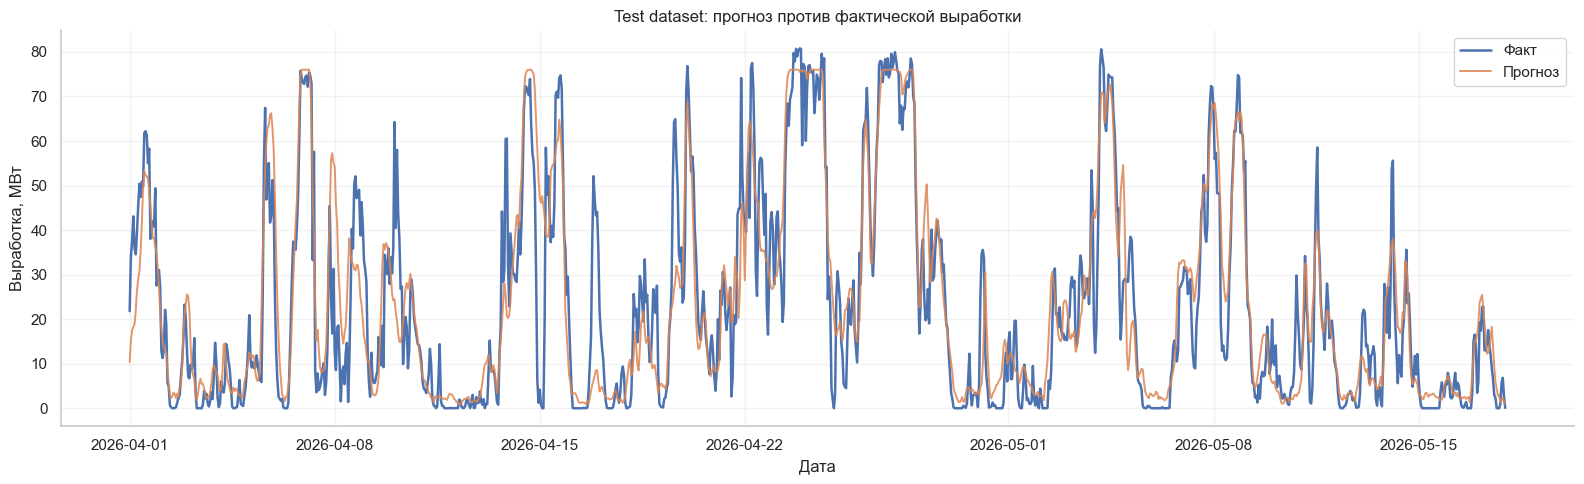

Saved: outputs\test\figures\test_01_prediction_vs_actual_time.png


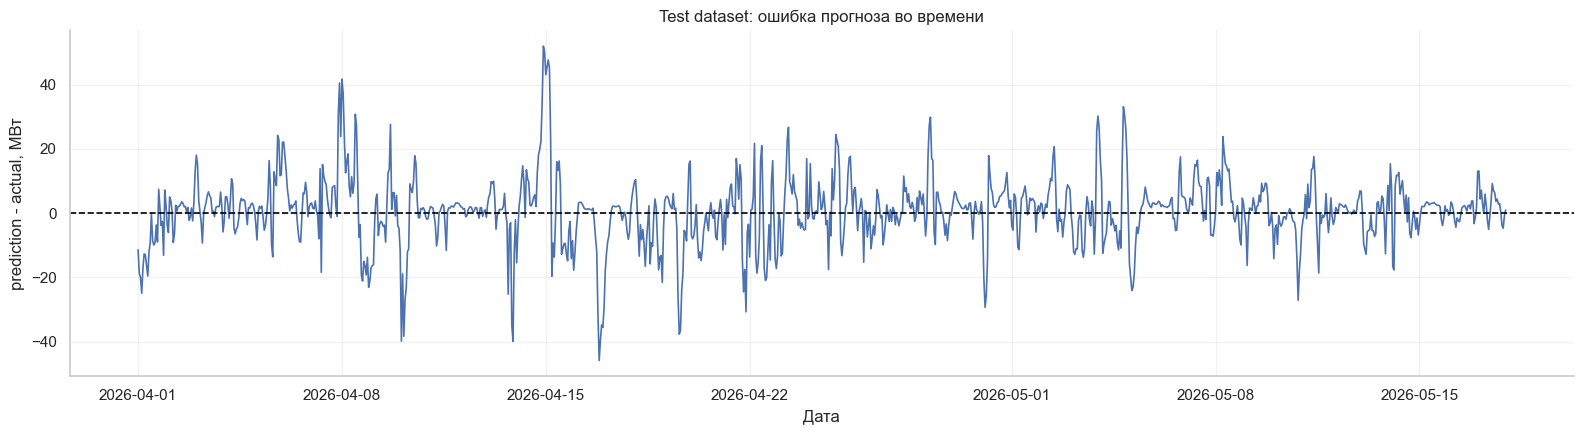

Saved: outputs\test\figures\test_02_error_time.png


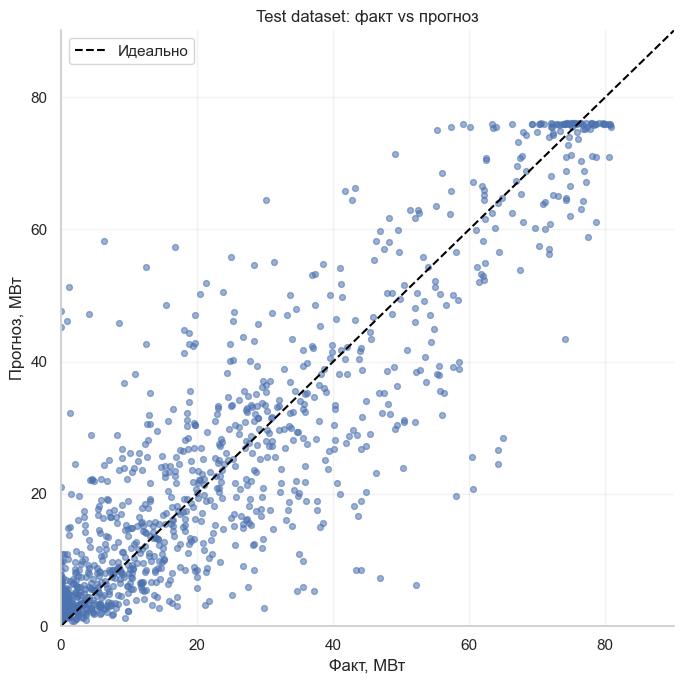

Saved: outputs\test\figures\test_03_actual_vs_prediction_scatter.png


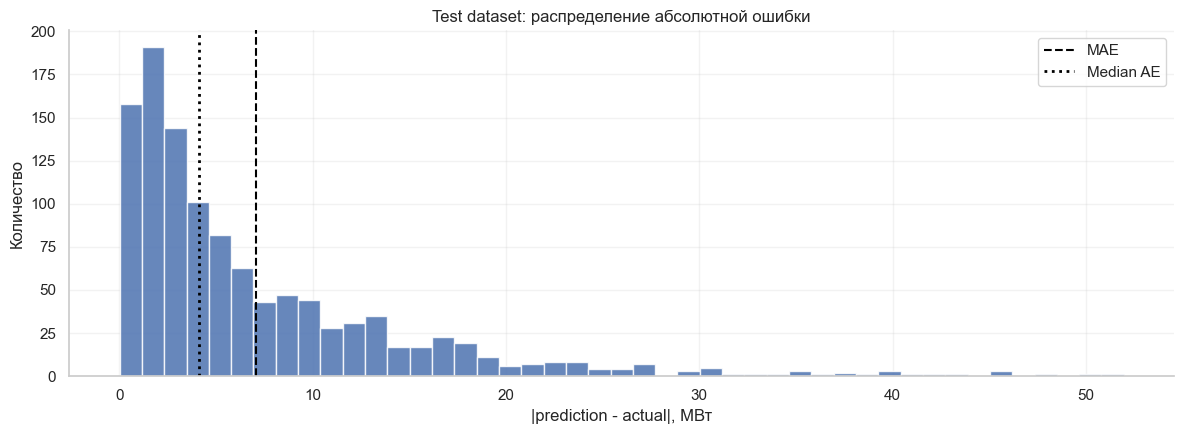

Saved: outputs\test\figures\test_04_abs_error_distribution.png


### Ошибка по бинам фактической мощности

,actual_power_bin,rows,mae_mw,bias_mw,actual_mean_mw,pred_mean_mw
0,0-1,187,4.040573,4.040573,0.181701,4.222273
1,1-5,145,4.620620,4.085383,2.801076,6.886459
2,5-10,123,5.931928,3.310582,7.415935,10.726517
3,10-20,188,7.511934,2.690011,14.924798,17.614809
4,20-40,236,8.705683,-1.656354,29.056174,27.399820
5,40-60,115,12.773274,-6.551168,48.832000,42.280832
6,60-80,129,6.527763,-3.142978,71.111318,67.968340
7,80+,5,5.800089,-5.800089,80.643800,74.843711


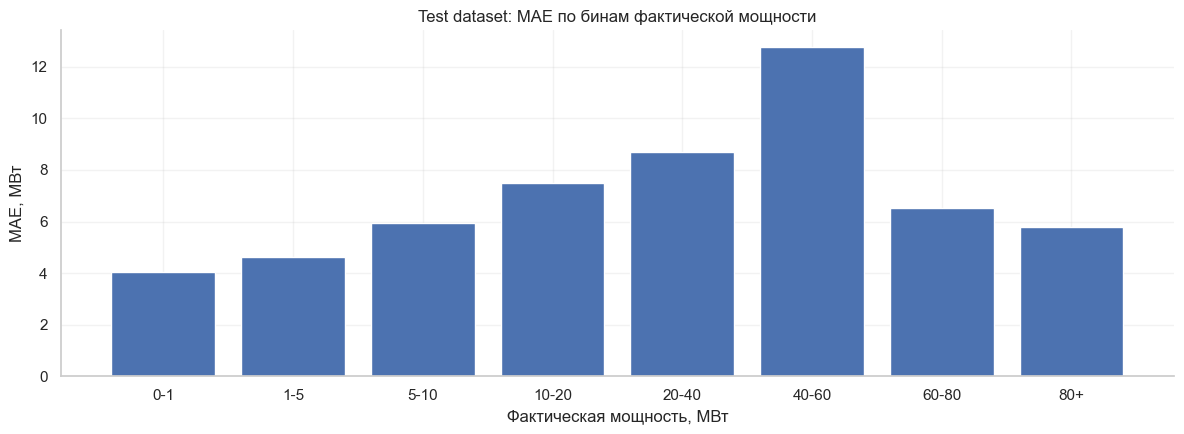

Saved: outputs\test\figures\test_05_mae_by_actual_power_bin.png


### Ошибка по бинам скорости ветра 120м

,wind_120m_bin,rows,mae_mw,bias_mw,actual_mean_mw,pred_mean_mw
0,0-3,195,2.482736,0.949228,1.643836,2.593063
1,3-5,264,4.896350,-0.848148,7.753784,6.905636
2,5-7,292,8.526134,-1.256026,20.522158,19.266132
3,7-9,199,10.756360,2.551602,34.460477,37.012079
4,9-11,88,12.427970,4.205492,52.565886,56.771378
5,11-13,49,6.592342,3.174189,67.419796,70.593985
6,13-15,37,3.244495,1.072919,74.900000,75.972919
7,15+,4,4.587003,3.662175,72.338000,76.000175


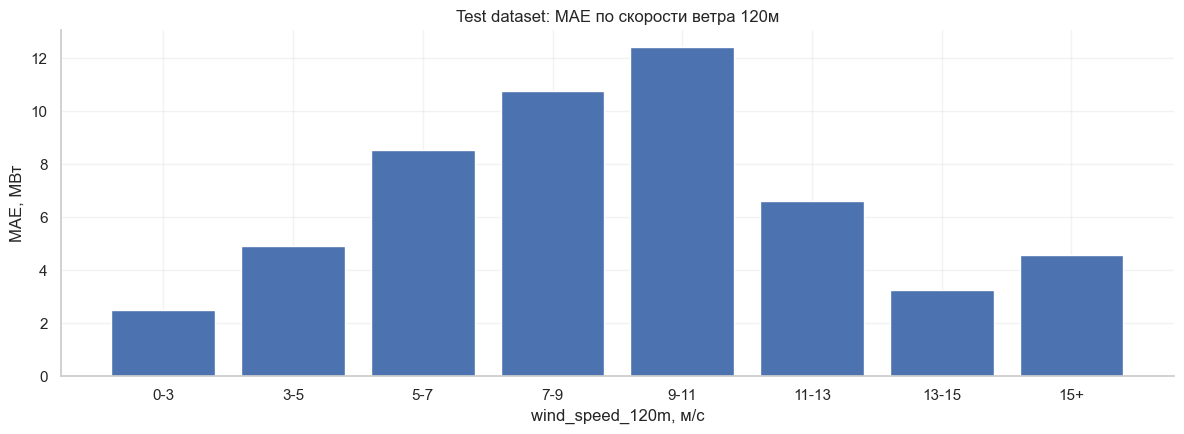

Saved: outputs\test\figures\test_06_mae_by_wind_speed_120m_bin.png


### Топ-20 худших ошибок

,row_id,datetime,actual_mw,wind_speed_120m,wind_speed_80m,wind_direction_120m,Кол-во_ВЭУ_в_ремонте,prediction_mw,error_mw,abs_error_mw,ape_pct,actual_power_bin,wind_120m_bin
817,817,2026-04-14 22:00:00,6.309,10.60,8.41,0.244,3,58.274431,51.965431,51.965431,8.236714e+02,5-10,9-11
816,816,2026-04-14 23:00:00,1.234,10.07,8.06,0.249,3,51.348738,50.114738,50.114738,4.061162e+03,1-5,9-11
813,813,2026-04-15 02:00:00,0.001,8.98,7.65,0.262,3,47.647965,47.646965,47.646965,4.764697e+06,0-1,7-9
771,771,2026-04-16 20:00:00,52.110,4.54,3.93,0.278,3,6.262091,-45.847909,45.847909,8.798294e+01,40-60,3-5
814,814,2026-04-15 01:00:00,0.852,8.56,6.96,0.256,3,46.131461,45.279461,45.279461,5.314491e+03,0-1,7-9
812,812,2026-04-15 03:00:00,0.001,9.21,7.60,0.272,3,45.270216,45.269216,45.269216,4.526922e+06,0-1,9-11
815,815,2026-04-15 00:00:00,4.189,9.00,7.02,0.246,3,47.241462,43.052462,43.052462,1.027750e+03,1-5,7-9
983,983,2026-04-08 00:00:00,12.564,9.06,7.56,0.211,3,54.274078,41.710078,41.710078,3.319809e+02,10-20,9-11
985,985,2026-04-07 22:00:00,16.775,9.26,7.98,0.213,3,57.270327,40.495327,40.495327,2.414028e+02,10-20,9-11
842,842,2026-04-13 21:00:00,60.576,6.65,5.02,0.344,3,20.702885,-39.873115,39.873115,6.582329e+01,60-80,5-7



### Интерпретация результата

- **MAE = 7.059 МВт** — средняя ошибка около **7.83%** от установленной мощности 90.09 МВт.
- **Median AE = 4.140 МВт** — типичная ошибка заметно ниже MAE, значит большая часть часов предсказывается нормально.
- **RMSE = 10.505 МВт**, **P90 AE = 16.682 МВт** — есть заметный хвост крупных ошибок; основные проблемы сидят в отдельных сложных режимах.
- **Bias = 0.605 МВт** — систематический сдвиг маленький.


In [236]:
# ============================================================
# TEST DATASET: visual diagnostics and result interpretation
# ============================================================

from IPython.display import Markdown, display

_required = ["test_compare", "test_metrics", "TEST_FIGURE_DIR"]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "Сначала выполни test-eval ячейку. Не хватает объектов: "
        + ", ".join(_missing)
    )

TEST_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

eval_df = test_compare[
    test_compare["actual_mw"].notna() &
    test_compare["prediction_mw"].notna()
].copy()

if len(eval_df) == 0:
    raise RuntimeError("Нет строк с фактической выработкой для оценки.")

eval_df["datetime"] = pd.to_datetime(eval_df["datetime"], errors="coerce")
eval_df["error_mw"] = eval_df["prediction_mw"] - eval_df["actual_mw"]
eval_df["abs_error_mw"] = eval_df["error_mw"].abs()

metrics = test_metrics.iloc[0].to_dict()

def save_show(name):
    path = TEST_FIGURE_DIR / name
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

display(Markdown("## Test dataset diagnostics"))

display(pd.DataFrame([{
    "rows_total": int(metrics.get("rows_total", len(test_compare))),
    "rows_with_actual": int(metrics.get("rows_with_actual", len(eval_df))),
    "rows_without_actual": int(metrics.get("rows_without_actual", test_compare["actual_mw"].isna().sum())),
    "mae_mw": metrics.get("mae_mw", np.nan),
    "rmse_mw": metrics.get("rmse_mw", np.nan),
    "bias_mw": metrics.get("bias_mw", np.nan),
    "median_abs_error_mw": metrics.get("median_abs_error_mw", np.nan),
    "p90_abs_error_mw": metrics.get("p90_abs_error_mw", np.nan),
    "max_abs_error_mw": metrics.get("max_abs_error_mw", np.nan),
    "corr_actual_prediction": metrics.get("corr_actual_prediction", np.nan),
    "actual_mean_mw": metrics.get("actual_mean_mw", np.nan),
    "prediction_mean_mw": metrics.get("prediction_mean_mw", np.nan),
}]))

# ------------------------------------------------------------
# 1. Прогноз против факта во времени
# ------------------------------------------------------------

plot_df = eval_df.sort_values("datetime").copy()

plt.figure(figsize=(16, 5))
plt.plot(plot_df["datetime"], plot_df["actual_mw"], linewidth=1.8, label="Факт")
plt.plot(plot_df["datetime"], plot_df["prediction_mw"], linewidth=1.4, alpha=0.85, label="Прогноз")
plt.title("Test dataset: прогноз против фактической выработки")
plt.xlabel("Дата")
plt.ylabel("Выработка, МВт")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
save_show("test_01_prediction_vs_actual_time.png")

# ------------------------------------------------------------
# 2. Ошибка во времени
# ------------------------------------------------------------

plt.figure(figsize=(16, 4.5))
plt.plot(plot_df["datetime"], plot_df["error_mw"], linewidth=1.2)
plt.axhline(0, linestyle="--", linewidth=1.2, color="black")
plt.title("Test dataset: ошибка прогноза во времени")
plt.xlabel("Дата")
plt.ylabel("prediction - actual, МВт")
plt.grid(alpha=0.25)
plt.tight_layout()
save_show("test_02_error_time.png")

# ------------------------------------------------------------
# 3. Scatter: факт vs прогноз
# ------------------------------------------------------------

lims = [
    min(eval_df["actual_mw"].min(), eval_df["prediction_mw"].min(), 0),
    max(eval_df["actual_mw"].max(), eval_df["prediction_mw"].max(), INSTALLED_CAPACITY_MW),
]

plt.figure(figsize=(7, 7))
plt.scatter(
    eval_df["actual_mw"],
    eval_df["prediction_mw"],
    s=18,
    alpha=0.55,
)
plt.plot(lims, lims, linestyle="--", linewidth=1.5, color="black", label="Идеально")
plt.xlim(lims)
plt.ylim(lims)
plt.title("Test dataset: факт vs прогноз")
plt.xlabel("Факт, МВт")
plt.ylabel("Прогноз, МВт")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
save_show("test_03_actual_vs_prediction_scatter.png")

# ------------------------------------------------------------
# 4. Распределение абсолютной ошибки
# ------------------------------------------------------------

plt.figure(figsize=(12, 4.5))
plt.hist(eval_df["abs_error_mw"], bins=45, alpha=0.85)
plt.axvline(metrics.get("mae_mw", eval_df["abs_error_mw"].mean()), linestyle="--", linewidth=1.5, color="black", label="MAE")
plt.axvline(metrics.get("median_abs_error_mw", eval_df["abs_error_mw"].median()), linestyle=":", linewidth=2.0, color="black", label="Median AE")
plt.title("Test dataset: распределение абсолютной ошибки")
plt.xlabel("|prediction - actual|, МВт")
plt.ylabel("Количество")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
save_show("test_04_abs_error_distribution.png")

# ------------------------------------------------------------
# 5. Ошибка по бинам фактической мощности
# ------------------------------------------------------------

power_bins = [0, 1, 5, 10, 20, 40, 60, 80, INSTALLED_CAPACITY_MW + 1]
power_labels = ["0-1", "1-5", "5-10", "10-20", "20-40", "40-60", "60-80", "80+"]

eval_df["actual_power_bin"] = pd.cut(
    eval_df["actual_mw"].clip(0, INSTALLED_CAPACITY_MW),
    bins=power_bins,
    labels=power_labels,
    include_lowest=True,
)

power_bin_report = (
    eval_df
    .groupby("actual_power_bin", observed=True)
    .agg(
        rows=("abs_error_mw", "size"),
        mae_mw=("abs_error_mw", "mean"),
        bias_mw=("error_mw", "mean"),
        actual_mean_mw=("actual_mw", "mean"),
        pred_mean_mw=("prediction_mw", "mean"),
    )
    .reset_index()
)

display(Markdown("### Ошибка по бинам фактической мощности"))
display(power_bin_report)

plt.figure(figsize=(12, 4.5))
plt.bar(power_bin_report["actual_power_bin"].astype(str), power_bin_report["mae_mw"])
plt.title("Test dataset: MAE по бинам фактической мощности")
plt.xlabel("Фактическая мощность, МВт")
plt.ylabel("MAE, МВт")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
save_show("test_05_mae_by_actual_power_bin.png")

# ------------------------------------------------------------
# 6. Ошибка по скорости ветра 120м
# ------------------------------------------------------------

if "wind_speed_120m" in eval_df.columns:
    wind_bins = [0, 3, 5, 7, 9, 11, 13, 15, 30]
    wind_labels = ["0-3", "3-5", "5-7", "7-9", "9-11", "11-13", "13-15", "15+"]

    eval_df["wind_120m_bin"] = pd.cut(
        eval_df["wind_speed_120m"],
        bins=wind_bins,
        labels=wind_labels,
        include_lowest=True,
    )

    wind_bin_report = (
        eval_df
        .groupby("wind_120m_bin", observed=True)
        .agg(
            rows=("abs_error_mw", "size"),
            mae_mw=("abs_error_mw", "mean"),
            bias_mw=("error_mw", "mean"),
            actual_mean_mw=("actual_mw", "mean"),
            pred_mean_mw=("prediction_mw", "mean"),
        )
        .reset_index()
    )

    display(Markdown("### Ошибка по бинам скорости ветра 120м"))
    display(wind_bin_report)

    plt.figure(figsize=(12, 4.5))
    plt.bar(wind_bin_report["wind_120m_bin"].astype(str), wind_bin_report["mae_mw"])
    plt.title("Test dataset: MAE по скорости ветра 120м")
    plt.xlabel("wind_speed_120m, м/с")
    plt.ylabel("MAE, МВт")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    save_show("test_06_mae_by_wind_speed_120m_bin.png")

# ------------------------------------------------------------
# 7. Топ худших ошибок
# ------------------------------------------------------------

worst_errors = (
    eval_df
    .sort_values("abs_error_mw", ascending=False)
    .head(20)
    .copy()
)

display(Markdown("### Топ-20 худших ошибок"))
display(worst_errors)

# ------------------------------------------------------------
# 8. Короткая текстовая оценка
# ------------------------------------------------------------

mae = float(metrics.get("mae_mw", eval_df["abs_error_mw"].mean()))
rmse = float(metrics.get("rmse_mw", np.sqrt(np.mean(eval_df["error_mw"] ** 2))))
bias = float(metrics.get("bias_mw", eval_df["error_mw"].mean()))
median_ae = float(metrics.get("median_abs_error_mw", eval_df["abs_error_mw"].median()))
p90_ae = float(metrics.get("p90_abs_error_mw", eval_df["abs_error_mw"].quantile(0.90)))
cap_share = mae / INSTALLED_CAPACITY_MW * 100

if abs(bias) < 1.0:
    bias_text = "систематический сдвиг маленький"
elif bias > 0:
    bias_text = "модель в среднем завышает прогноз"
else:
    bias_text = "модель в среднем занижает прогноз"

if rmse / mae > 1.45:
    tail_text = "есть заметный хвост крупных ошибок"
else:
    tail_text = "крупные ошибки не доминируют"

display(Markdown(f"""
### Интерпретация результата

- **MAE = {mae:.3f} МВт** — средняя ошибка около **{cap_share:.2f}%** от установленной мощности {INSTALLED_CAPACITY_MW:.2f} МВт.
- **Median AE = {median_ae:.3f} МВт** — типичная ошибка заметно ниже MAE, значит большая часть часов предсказывается нормально.
- **RMSE = {rmse:.3f} МВт**, **P90 AE = {p90_ae:.3f} МВт** — {tail_text}; основные проблемы сидят в отдельных сложных режимах.
- **Bias = {bias:.3f} МВт** — {bias_text}.
"""))